# Penalty-Weight Pareto Optimization

> ### This notebook has two halves, trained under two different pipelines
>
> **Sections 1–8 are post-ramp and live.** They read
> `tables/penalty_sweep_X_ofat_ramp.csv`: 17 recipes × 3 seeds = 51 pulses, trained with the
> structural Gaussian rise/fall envelope of `core/ramp.py` in place, over three
> one-factor-at-a-time axes — $\lambda_{\mathrm{deriv}}$, the amplitude threshold
> $\epsilon_{\max}$, and the ramp duration $T_{\mathrm{ramp}}$.
>
> **Sections 9–15 are pre-ramp and frozen.** They were trained with a soft boundary penalty
> $\lambda_{\text{boundary}}(\|u_0\|^2+\|u_{-1}\|^2)$ that has since been **removed** from
> `core.optimizer.optimize_multi_state_pulse` — a change the pre-ramp grid section (since
> deleted; see §7.2) helped motivate, having measured that weight's effect as indistinguishable
> from basin noise.
>
> The two halves are **not comparable**. `_config_hash` covers the whole of `FIXED`, and adding
> `ramp_ns` to it moved every hash, so a pre-ramp and a post-ramp pulse of the "same" recipe are
> different pulses from different experiments. A full banner sits above §9.
>
> What survived the transition: **the $\lambda_{\mathrm{deriv}}$ recommendation**, which was the
> only axis ever to clear the noise floor, and which the ramp does not bear on.

---

## Executive summary

The primary result is the post-ramp campaign: 17 configurations × seeds 42/43/44, one continuous
L-BFGS-B run each, `trunc_list=[22,24,26]`, `maxiter=1500`. Weights are chosen by sweeping them,
scoring every candidate on a **held-out** truncation set that training never sees, and selecting
under a hardware spectral-width budget (§8.1).

| | incumbent | recommended | delta |
|---|---|---|---|
| $\lambda_{\mathrm{deriv}}$ | $10^{-5}$ | $\mathbf{10^{-6}}$ | 10× reduction |
| held-out $F$ (3-seed mean) | 0.997552 | **0.999097** | $+1.5\times10^{-3}$ |
| $W_{99}$, cavity | 29.2% of 54 MHz | 46.0% | $+16.8$ pts |
| $W_{99}$, transmon *(binding)* | 46.8% of 66 MHz | **55.6%** | $+8.7$ pts |

**This is the same recipe the pre-ramp campaign selected**, and the same one a two-phase training
schedule selected independently (§13) — three selections agreeing on data that share no pulse and
no configuration hash. That agreement is the strongest claim in this notebook. The *price* is not
protocol-independent: each campaign's incumbent has its own bandwidth, so the same weight cut
costs a different number of points in each.

Five qualifications, each developed below and none of them cosmetic:

1. **$\lambda_{\mathrm{deriv}}$ is the only axis that matters** (§6.3). It moves held-out $F$ by
   $7.9\times10^{-3}$ — $5.4\times$ the noise floor, monotone with $\rho = -1.00$ — and it is the
   only one of the three that does. $\epsilon_{\max}$ moves it by $6.8\times10^{-4}$ and
   $T_{\mathrm{ramp}}$ by $1.4\times10^{-3}$, both **below** the floor: unidentified at $n=3$,
   which is a weaker claim than "does nothing" and §7 keeps the distinction.
   $\lambda_{\mathrm{amp}}$ and $\lambda_{\mathrm{disc}}$ move it by *structurally* zero (§6.1).
2. **There is exactly one noise floor, and it is $1.5\times10^{-3}$** (§6.2). Nine independent
   runs of an identical objective under different configuration hashes came back
   **bit-identical**, so the pipeline contributes no noise of its own and seed choice is the only
   source. Nothing smaller than the floor is a ranking — including, by a margin of $1.05\times$,
   the recommendation's own lead over the incumbent.
3. **No run converged** (§4). All 51 hit the `maxiter` cap at 1500 iterations. The fidelity
   *ranking* is stable under a 750-iteration continuation; occupied width was still drifting.
4. **The ramp works; its duration is not a fidelity knob** (§6.4). Lengthening the ramp from
   30 ns to 70 ns cuts the endpoint amplitude $3.4\times$ ($\rho = -0.94$) at no measurable cost
   in fidelity *or* in pre-image headroom. A longer ramp is close to free — but that is an
   engineering result, not a fidelity axis, and it is reported as the weaker claim it is.
5. **No 2-D grid is worth training on this evidence** (§7.4). Only one axis is live, so no pair
   has two live marginals; no pair has an opposite-sign shared mediator that survives a per-seed
   robustness check, because the seed-mean correlations that suggested one turn out to be
   averaging noise; and 4 of the 7 rungs of a
   $\lambda_{\mathrm{deriv}} \times \epsilon_{\max}$ grid are *provably* a verbatim copy of the
   $\lambda_{\mathrm{deriv}}$ ladder. The budget is better spent on seed replication, which would
   drop the floor to $1.0\times10^{-3}$ and settle qualification 2.

**Reading order.** §1 says why the weights need tuning at all and why the constraint is an
occupied-width cap; §2 is the method, including both protocols' schedules (§2.6); §3–§8 are the
live post-ramp study, ending in the recommendation. Below the banner, §9–§15 are the frozen
pre-ramp record: §10 validates a cheap mid-training screen for future sweeps, §11 compares the
single- and two-phase protocols cell-by-cell, §12 lists what neither protocol's run settles, §13
compares the two protocols' averaged Pareto fronts (they agree on the recipe), §14 pools every
individual trial and checks whether the single best draw beats the seed-mean recommendation (it
does not, once noise is accounted for), and §15 records the seed-48 wall-exploiting basin.

# 1. Rationale

### 1.1 Why the weights cannot be tuned on the training objective

The cost function that trains every logical-gate pulse in this project is a fidelity plus four
penalty terms, evaluated on a waveform that is itself a *constrained function* of the raw
optimizer variable $x$:

$$\mathcal{C}(x) \;=\; -\,\overline{F_{\mathrm{coh}}}(u)
\;+\; \lambda_{\mathrm{disc}}\!\!\sum_{i\neq j}\!(F_i-F_j)^2
\;+\; \lambda_{\mathrm{deriv}}\, g_d(u)
\;+\; \lambda_{\mathrm{amp}}\, g_a(u),
\qquad u \;=\; \underbrace{\mathrm{env}(T_{\mathrm{ramp}})}_{\text{ramp}} \odot\;
\underbrace{P(x)}_{\text{band limit}}$$

Every $\lambda$ term is a **regularizer**: non-negative, and able only to *raise* the cost.
Tuning the weights against the training objective therefore has exactly one fixed point: all
of them at zero. The optimizer obliges, and returns a pulse that is rougher, wider in bandwidth, and
better at exploiting the finite Hilbert space it trained in. The training number goes up; the
pulse gets worse.

So the weights cannot be chosen by optimizing the quantity they appear in. They have to be chosen
against something training never sees. This notebook does that in three steps: **sweep** the
weights, **score** each candidate on the reported fidelity at held-out cavity truncations, then
**select** under a hardware spectral-width budget.

### 1.2 What each penalty term buys

| term | definition (`core/grape_core.py`) | what it suppresses |
|---|---|---|
| $g_d$ | $\sum_k \lVert u_{k+1}-u_k\rVert^2$ | step-to-step roughness, hence high-frequency content |
| $g_a$ | $\sum \max(0, \lvert u\rvert - \epsilon_{\max})^2$ | drive amplitude above a soft cap $\epsilon_{\max}$ |
| disc | $\sum_{i\neq j}(F_i-F_j)^2$ over `trunc_list` | fidelity that depends on where the Hilbert space is cut |

The first two are **shape** penalties on the waveform; the third is a **robustness** penalty on
the solution. Only the third touches the physics of the target; the rest are hardware realism.

**A fourth term used to be here, and its absence is the reason this notebook was rebuilt.**
$g_b = \lVert u_0\rVert^2 + \lVert u_{N-1}\rVert^2$ penalized a discontinuous switch-on at the
pulse edges. It was structurally broken: its gradient touched 2 of 550 rows and was then smeared
across all 550 by the circular-FFT band projection $P$, which does not preserve endpoint zeros.
Swept over a full $5\times5$ grid, its marginal effect on held-out fidelity ranged
$8.1\times10^{-4}$–$4.8\times10^{-3}$ — straddling the basin-noise floor and non-monotonic in
every row.

It was **removed outright** and replaced by a *structural* constraint: the raw variable $x$ is
band-limited and then multiplied by a pedestal-subtracted Gaussian envelope,
$u = \mathrm{env} \odot P(x)$, so the endpoint condition is enforced by the parametrization
rather than paid for in the cost. There is no weight left to sweep — but the constraint has a
**duration**, $T_{\mathrm{ramp}}$, and a duration has a cost of its own. That is the third axis
of this study.

### 1.2b What the ramp costs

$T_{\mathrm{ramp}}$ is not a regularizer and does not belong on a Pareto front. It buys a lower
endpoint amplitude and it pays in two currencies:

| lengthening the ramp | effect |
|---|---|
| $\mathrm{env}[0]$: $0.0219 \to 0.0091$ across $30 \to 70$ ns | the drive starts closer to *off* — this is what it buys |
| ramped window: 5.5% $\to$ 12.7% of the 550 steps | control authority is removed at the edges |
| pre-image inflation | L-BFGS-B buys that authority back by inflating $x$, bounded only by `hard_amp_limit` |
| out-of-band energy | the envelope is applied *after* $P$, so it reintroduces a sub-percent spectral tail |

The third row is the dangerous one. When the box on $x$ **binds**, the box — not the objective —
is choosing the pulse, and the run can land in a pathological basin: retraining $U_Y$ cold at
seed 42 drove $\max\lvert x\rvert$ to exactly 40.0 and produced a 44%-leakage solution whose
*training* fidelity looked perfectly healthy. Two columns exist in this sweep specifically to
catch that, `max_abs_preimage` and `preimage_at_bound_frac`, and §4 checks them before any
fidelity number in this notebook is read.

> **That table is the hypothesis, and this sweep tests it. Row 1 survives; row 3 does not.**
> The endpoint does fall with ramp duration, cleanly and monotonically. But pre-image inflation
> turns out **not** to track ramp duration at all — over 30–70 ns the rank correlation between
> $T_{\mathrm{ramp}}$ and $\max\lvert x\rvert$ is $+0.03$, and the *longest* ramp produces the
> *smallest* pre-image. What actually governs it is $\lambda_{\mathrm{deriv}}$
> ($\rho = -0.94$), which in hindsight is the sensible answer: the derivative penalty is
> precisely what charges for the large step-to-step excursions an inflated pre-image creates.
> §5.1 and §6.4 show the data. The authority-loss argument in `core/ramp.py` should therefore
> be read as a claim about *having* a ramp versus not, at the fixed 48 ns default — not about
> how long it is.

### 1.3 Training objective vs. reported metric

The distinction that runs through the whole notebook:

- $F_{\mathrm{coh}}$: the coherent process fidelity the optimizer actually descends on, averaged
  over the training truncations $n_c \in \{22, 24, 26\}$ (Heeres Supp. Eq. 23). Returned by
  `optimize_multi_state_pulse` as `F_coh_train`.
- $F_{\mathrm{held}}$: the gate fidelity (Pedersen 2007 average-gate-fidelity formula),
  computed from the full $D \times D$ propagator, projected onto the logical subspace
  ($\texttt{logical\_block} = B^\dagger U B$), and evaluated at truncations the pulse never
  trained on. Produced by `main.report_pedersen_gate_fidelity`. **This is the headline
  number.**

Throughout this notebook, $F_{\mathrm{held}}$ will be referred to simply as **F**, **F_held**, or
**mean F_held** (depending on context), not "Pedersen fidelity." **F_coh** refers only
to the training objective above.

Their difference is `overfit_gap`. Ranking on $F_{\mathrm{coh}}$ would reward exploitation of the
truncation wall, which is the failure mode the penalties exist to prevent. So it cannot be the
selection metric.

### 1.4 Why the constraint is an occupied-width cap

Bandwidth appears nowhere in $\mathcal{C}(u)$. Three separate mechanisms act on the spectrum, and
only the first two are inside the optimizer:

| # | mechanism | where it acts | what it constrains |
|---|---|---|---|
| 1 | penalties $g_d, g_b, g_a$, plus an L-BFGS-B box on the raw variable | inside the cost | waveform shape and amplitude |
| 2 | hard band-limit projection, $\pm27$ MHz cavity / $\pm33$ MHz transmon | `core.fourier_cutoff.project_bandlimit`, applied to $u$ **and** the gradient every iteration | spectral **support**: power is exactly zero outside the band |
| 3 | `occ99_frac` $\leq 0.70$, i.e. $W_{99} \leq 70\%$ of **each drive's own** mask (37.8 MHz cavity, 46.2 MHz transmon) | `pv.recommend`, after training | spectral **concentration**: how tightly the power packs inside the band |

Rows 2 and 3 are both per-drive and they are not the same limit. Row 2 is **hard**: it is where
power is allowed to exist at all, it is enforced by `project_bandlimit` on the controls *and* the
gradient at every iteration, and no choice of penalty weights can violate it. Row 3 is **soft**:
it is how much of that allowance a converged pulse actually consumes, it is checked only after
training, and it is the line a configuration can fail. Two limits, two roles, same per-drive
granularity: a drive that is allowed 54 MHz is budgeted against 54 MHz.

**The metric.** For each complex drive $\epsilon_C = u_0 + iu_1$ and $\epsilon_T = u_2 + iu_3$,
`analysis.penalty_sweep.pulse_metrics` computes the **99% occupied width**: the narrowest
frequency window carrying 99% of the power,

$$W_{99} \;=\; \min_{[a,b]}\,(b-a) \quad\text{subject to}\quad
\sum_{a \le f \le b} p(f) \;\ge\; 0.99,
\qquad p(f) = \frac{\lvert\hat\epsilon(f)\rvert^2}{\sum_{f'}\lvert\hat\epsilon(f')\rvert^2},$$

with $f = \texttt{np.fft.fftfreq}(N, \mathrm{d}t)$ in MHz. Dividing by the total power makes it
amplitude-independent: scaling a pulse by $10\times$ leaves it unchanged. The window edges land on
FFT bins, so $W_{99}$ is quantised to $1/(N\,\mathrm{d}t) = 0.909$ MHz. They are also reported
(`occ99_{cav,tra}_{lo,hi}_MHz`), because *where* in the allowed band the power sits is a separate
fact from how wide it is. See Table 1.

**Each drive is charged against its own allowance.** The scored scalar is

$$\texttt{occ99\_frac} \;=\; \max\!\left(\frac{W_{99}^{C}}{54\ \mathrm{MHz}},\;
\frac{W_{99}^{T}}{66\ \mathrm{MHz}}\right),$$

the share of its own allowance consumed by the worse drive. Taking `max` of the two *raw* widths
instead would be a conjunction of two constraints forced to share one threshold, and the drives do
not share an allowance: the cavity mask is $\pm27$ MHz and the transmon's $\pm33$. They are also
separate hardware chains (own LO, mixer, DAC channel, line), so nothing physically experiences the
max of the two. Comparing their raw widths is comparing "20 GB used" on a 50 GB disk against
"25 GB used" on a 100 GB disk. Normalising first restores the correct conjunction,

$$\max(x/a,\, y/b) \leq t \quad\Longleftrightarrow\quad (x \leq ta) \;\wedge\; (y \leq tb),$$

and leaves the budget a dimensionless percentage, which is one fewer thing that can be mis-ported.
§8.3 shows the case where this changes which reason a configuration is rejected for.

**Why mechanism 3 is not redundant with mechanism 2.** The mask is a 0/1 indicator. It says where
power is *allowed*, not how it is arranged, and an orthogonal projection cannot express a
preference: "flat out to the band edge" and "tightly clustered near DC" are equally admissible.
The spectral *support* is already pinned exactly by the mask, so mechanism 3 charges for how that
allowance is used, not whether it is exceeded. The cell below measures both pulses at the centre
of this study: the one the budget accepts and the one it rejects.

In [1]:
# Table 1. Spectral anatomy of the two pulses at the centre of the study.
# Self-contained on purpose: Section 1 precedes the Setup cell, so this must not
# depend on GATE / dt / pv. `core.fourier_cutoff` is numpy-only -- do NOT import
# `analysis.penalty_sweep` here (it pulls in `main`, which calls matplotlib.use("Agg")).
import os, sys
import numpy as np
import pandas as pd

if os.path.abspath(".") not in sys.path:
    sys.path.insert(0, os.path.abspath("."))
from core.fourier_cutoff import make_band_mask

DT = 0.002                                  # us
EDGE = {"cav": 27.0, "tra": 33.0}           # FIXED["cav_band"] / ["tra_band"]
BAND = {d: 2 * e for d, e in EDGE.items()}  # mask WIDTHS: 54 cav / 66 tra
BUDGET_FRAC = 0.70                          # of each drive's OWN mask
CHI_MHz = -2.194                            # core.grape_core.chi / 2pi
CACHE = "results/penalty_sweep_cache/X"
# Post-ramp labels: `boundary` is no longer a penalty, so it no longer appears
# in a label. These are the same two recipes as before -- the incumbent and its
# lambda_deriv = 0 negative control -- retrained under the ramp.
PAIR = {"deriv=1e-05_amp=8e-05_disc=0.5": "incumbent (deriv=1e-5)",
        "deriv=0_amp=8e-05_disc=0.5":     "control   (deriv=0)"}

# Seed 42 only: this cell inspects two individual WAVEFORMS, not a seed mean.
ofat = (pd.read_csv("tables/penalty_sweep_X_ofat_ramp.csv")
          .query("seed == 42").drop_duplicates("label").set_index("label"))


def occ_width(P, f, frac=0.99):
    """Narrowest window holding `frac` of the power, as (width, lo, hi).

    Mirrors `analysis.penalty_sweep.occupied_width`; duplicated rather than
    imported to keep this cell import-light (see the note above)."""
    o = np.argsort(f)                                  # fftfreq is not monotonic
    fs, c = f[o], np.cumsum(P[o] / P.sum())
    b = np.searchsorted(c, np.concatenate(([0.0], c[:-1])) + frac, side="left")
    ok = np.nonzero(b < c.size)[0]
    i = ok[np.argmin(fs[b[ok]] - fs[ok])]
    return fs[b[i]] - fs[i], fs[i], fs[b[i]]


def anatomy(eps, edge):
    """The 99% occupied width and window, and the power outside the band mask."""
    f = np.fft.fftfreq(len(eps), d=DT)                 # cycles/us == MHz
    P = np.abs(np.fft.fft(eps)) ** 2
    P /= P.sum()
    w99, lo, hi = occ_width(P, f)
    return dict(w99=w99, lo=lo, hi=hi,
                outside=P[~make_band_mask(len(eps), DT, -edge, edge)].sum())


hdr = f"{'':28s}{'W99':>6}{'of mask':>9}{'window':>17}{'outside':>9}"
print(hdr)
for label, name in PAIR.items():
    path = f"{CACHE}/u_{ofat.loc[label, 'config_hash']}.npy"
    if not os.path.exists(path):
        print(f"{name}: pulse cache absent -- regenerate with "
              f"`python analysis/penalty_sweep.py --gate X --mode ofat --seeds 42 --maxiter 1500`")
        continue
    u = np.load(path)
    for drive, (i, j) in (("cav", (0, 1)), ("tra", (2, 3))):
        a = anatomy(u[:, i] + 1j * u[:, j], EDGE[drive])
        # Each drive's width is charged against ITS OWN mask, not the wider one.
        print(f"{name + ' ' + drive:28s}{a['w99']:6.2f}{a['w99']/BAND[drive]:9.1%}"
              f"  [{a['lo']:6.2f},{a['hi']:6.2f}]{a['outside']:9.1e}")
    r = ofat.loc[label]
    print(f"{'':28s}recorded occ99_frac = {r['occ99_frac']:.1%} "
          f"(binding: {r['binding_drive']}; occ99_MHz = {r['occ99_MHz']:.2f}, "
          f"n_bar_drive = {r['n_bar_drive']:.2f})")
    print(f"{'':28s}endpoint = {r['endpoint_rel_to_peak']:.2%} of peak; "
          f"out-of-band = {r['out_of_band_cav']:.1e} cav / "
          f"{r['out_of_band_tra']:.1e} tra")

print(f"\nbudget: each drive may occupy at most {BUDGET_FRAC:.0%} of its OWN mask")
print(f"        -> {BUDGET_FRAC*BAND['cav']:.1f} MHz cavity (of {BAND['cav']:.0f}), "
      f"{BUDGET_FRAC*BAND['tra']:.1f} MHz transmon (of {BAND['tra']:.0f}).")
print(f"        W99 is bounded above by the mask width by construction, so the fraction is a\n"
      f"        genuine share of the attainable range rather than a number on an open scale.")
print(f"\nNote `outside` is no longer ~1e-31. The constraint chain is u = env * P(x):\n"
      f"the band projection runs FIRST and the ramp envelope multiplies AFTER it, so\n"
      f"the envelope reintroduces a small out-of-band tail by construction. That is the\n"
      f"ramp's measured spectral price, and it is the reason the ordering is pinned by a\n"
      f"negative control in validation/test_grape_core_perf.py rather than left to taste:\n"
      f"the other order gives ~1e-31 out-of-band but leaves the endpoints at 32% of mid.")


                               W99  of mask           window  outside
incumbent (deriv=1e-5) cav   16.36    30.3%  [ -8.18,  8.18]  3.6e-04
incumbent (deriv=1e-5) tra   33.64    51.0%  [-25.45,  8.18]  1.1e-03
                            recorded occ99_frac = 51.0% (binding: tra; occ99_MHz = 33.64, n_bar_drive = 2.43)
                            endpoint = 2.39% of peak; out-of-band = 3.6e-04 cav / 1.1e-03 tra
control   (deriv=0) cav      40.91    75.8%  [-21.82, 19.09]  6.9e-04
control   (deriv=0) tra      41.82    63.4%  [-33.64,  8.18]  6.2e-03
                            recorded occ99_frac = 75.8% (binding: cav; occ99_MHz = 41.82, n_bar_drive = 5.45)
                            endpoint = 0.21% of peak; out-of-band = 6.9e-04 cav / 6.2e-03 tra

budget: each drive may occupy at most 70% of its OWN mask
        -> 37.8 MHz cavity (of 54), 46.2 MHz transmon (of 66).
        W99 is bounded above by the mask width by construction, so the fraction is a
        genuine share of the attain

**Table 1. Spectral anatomy of the accepted and the rejected pulse.** Per drive: the 99%
occupied width $W_{99}$, that width as a share of the drive's own band mask, the window achieving
it, and the power fraction outside the hard band mask. The two configurations differ only in
$\lambda_{\mathrm{deriv}}$ ($10^{-5}$ vs. $0$), so everything separating them is that one weight.

Three things follow.

**The mask genuinely cannot do this job.** Both pulses sit almost entirely inside the band and
both occupy it out to its last bin. Mechanism 2 sees two identical pulses; mechanism 3 sees two
transmon drives using very different shares of their allowance. That difference is the entire
object of this study.

**The window edges say something the width does not.** A drive's 99% window can be wide because
it is genuinely broadband, or because it is *offset* — pushed against one mask edge to address a
number-split peak at $\bar n$ photons. The width alone cannot tell those apart; the edges can,
and `n_bar_drive` reads the offset back as the photon number the drive is centred on.

**The out-of-band figure is no longer $\sim\!10^{-31}$, and that is the ramp.** The constraint
chain is $u = \mathrm{env}\odot P(x)$: the projection runs first and the envelope multiplies
after it, so the envelope reintroduces a small spectral tail by construction. That is the ramp's
measured price, paid to get the endpoints down. The reverse order would keep the spectrum exact
and leave the endpoints at ~32% of mid-pulse RMS, which is why the ordering is pinned by a
negative control in `validation/test_grape_core_perf.py` rather than left to inspection.

# 2. Methodology

### 2.1 Fixed conditions

Three axes vary — one penalty weight and two structural knobs. Everything else is pinned in
`analysis.penalty_sweep.FIXED` and forms part of the configuration hash, so changing any of it
invalidates the cache rather than silently mixing regimes. Adding `ramp_ns` to `FIXED` is exactly
what invalidated the pre-ramp cache, which is why every number in Sections 1–8 was retrained from
scratch and why Sections 9–15 are frozen behind a banner.

| | value |
|---|---|
| training truncations | `trunc_list = [22, 24, 26]`, `n_t = 3` |
| pulse | $N = 550$ steps at $\mathrm{d}t = 2$ ns (1.1 µs total), 4 controls |
| hard frequency bands | cavity $\pm27$ MHz, transmon $\pm33$ MHz |
| amplitude | `hard_amp_limit = 40` rad/µs (box on the **pre-image** $x$), $\epsilon_{\max} = 40$ rad/µs (soft cap on $u$) |
| endpoint ramp | $T_{\mathrm{ramp}} = 48$ ns, pedestal-subtracted Gaussian, $\sigma = T_{\mathrm{ramp}}/2$ |
| warm start | smooth random cold start, seeded per run |
| seeds | 42, 43, 44 |
| incumbent recipe `BASELINE` | deriv $10^{-5}$ · amp $8\times10^{-5}$ · disc $0.5$, at $\epsilon_{\max} = 40$, $T_{\mathrm{ramp}} = 48$ ns |

The two amplitude limits act on **different objects** and are routinely confused. $\epsilon_{\max}$
is a soft threshold on the *physical* waveform $u$, charged element-wise on the four quadratures.
`hard_amp_limit` is L-BFGS-B's box on the *raw variable* $x$, which the ramp envelope then
multiplies down. Only the second one has ever produced a catastrophic pulse.

The **incumbent** is `main.py`'s production default: the recipe every pulse in
`pulses/u_*_main.npy` was trained under. It is the status quo this study tries to beat, and it
appears throughout as a dotted line or an open diamond.

### 2.2 Search design

**One design: three OFAT ladders, 17 recipes × 3 seeds = 51 trained pulses.** No 2-D grid is
trained here. Whether one is worth training is a *result* of this study, decided in §7.4 against a
rule pre-registered there.

| axis | rungs | kind |
|---|---|---|
| $\lambda_{\mathrm{deriv}}$ | `BASELINE * (0, 0.1, 0.3, 1, 3, 10)` = $\{0, 10^{-6}, 3\times10^{-6}, 10^{-5}, 3\times10^{-5}, 10^{-4}\}$ | penalty weight; the $\times 0$ rung is a true negative control (§7) |
| $\epsilon_{\max}$ | $\{10, 14, 18, 22, 26, 30\}$ rad/µs | soft **threshold**, not a weight — §6.1 shows why $\lambda_{\mathrm{amp}}$ itself can do nothing |
| $T_{\mathrm{ramp}}$ | $\{30, 40, 50, 60, 70\}$ ns | structural; the incumbent 48 ns is the shared rung of every ladder |

The incumbent is the shared centre of all three ladders and is enumerated once, which is why the
count is 17 and not 18.

**The $\epsilon_{\max}$ ladder is deliberately part-null, and that is its main value.** Converged
pulses here peak near 18–20 rad/µs element-wise, so rungs above that contribute exactly zero cost
with an exactly zero gradient — they optimize the *identical* objective as the incumbent under a
different configuration hash. That makes them independent replicates of one problem, which is
precisely the instrument needed to measure this pipeline's noise floor. The old instrument for
that was an *accident* (two configs whose weights differed in the sixteenth digit), and both its
members involved `boundary`, so it did not survive. §6.2 rebuilds it by design.

### 2.3 Training

Each configuration calls `core.optimizer.optimize_multi_state_pulse`, minimizing $\mathcal{C}(x)$
averaged over the three training truncations (joblib-parallel across them) with L-BFGS-B for at
most 1500 iterations, from a **cold** start.

The full constraint chain lives *inside* the objective and applies to both the controls and the
gradient: $u = \mathrm{env} \odot P(x)$ going forward, and $P(\mathrm{env} \odot g)$ coming back.
The order matters and is not a matter of taste — projecting *then* ramping leaves the endpoints at
0.84% of mid-pulse RMS and ~0.6% of energy out of band; ramping *then* projecting gives ~$10^{-31}$
out of band but leaves the endpoints at **32%** of mid. Both orderings produce a plausible-looking
gradient, so the adjoint identity is pinned with a negative control in
`validation/test_grape_core_perf.py` rather than left to inspection. Because the projection is
inside the objective, the search never leaves the band-limited subspace and mechanism 2 of §1.4
cannot be violated by any choice of weights. `converged` in the output CSV is scipy's
`success` flag. §4 audits it.

### 2.4 Scoring

Scoring is independent of training and never re-optimizes.

- **Fidelity.** `main.report_pedersen_gate_fidelity` builds the full propagator for the saved
  pulse, projects it onto the logical subspace, and returns F_held, the gate fidelity defined in
  §1.3. Evaluated
  at $n_c = 16, 18, \ldots, 40$; the ten values outside `trunc_list` form the **held-out** set.
- **Fidelity columns.** `F_ped_heldout_mean` (headline), `F_ped_heldout_min` (worst-case
  truncation), `robustness_spread` ($\max - \min$ across the held-out set), `overfit_gap`,
  `leakage_L1_mean` / `_max`.
- **Pulse-cost columns.** `occ99_frac` (§1.4, the scored one) with its per-drive parts
  `occ99_frac_{cav,tra}` and `binding_drive`; `peak_amp`; `roughness` (RMS first difference,
  rad/µs). Reported but never scored: the same widths in MHz (`occ99_MHz`,
  `occ99_{cav,tra}_MHz`) and their window edges `occ99_{cav,tra}_{lo,hi}_MHz`, plus `n_bar_drive`.
- **Constraint columns** (new, and the reason the ramp axis is measurable at all).
  `endpoint_rel_to_peak` — the largest endpoint sample as a fraction of the waveform's own peak,
  i.e. *what the ramp bought*; `endpoint_rel_to_mid`, the same numerator over the mid-pulse RMS,
  kept because `core/ramp.py`'s own benchmark quotes it and the two are not interchangeable;
  `out_of_band_{cav,tra}`, the spectral tail the envelope reintroduces after the projection.
  All four are recomputed from the saved waveform, so a cached row can gain them without
  retraining.
- **Pre-image columns** (the failure detector). `max_abs_preimage` and
  `preimage_at_bound_frac`, measured on the raw optimizer variable $x$ against
  `hard_amp_limit = 40`. These are *not* recoverable from the waveform, so the sweep now writes
  $x$ to the cache alongside $u$. A nonzero `preimage_at_bound_frac` means the box chose those
  entries, not the objective, and the row's fidelity is not comparable to the rest of its ladder.

Held-out truncations are a **scoring** set only. They enter no gradient, which is why widening
them cannot make $\lambda_{\mathrm{disc}}$ bite (§6.1).

### 2.5 Reproduction

```bash
# Sections 1-8. 51 runs; 4 concurrent shards is ~9.6 busy cores on a 10-core box.
for i in 0 1 2 3; do
  python analysis/penalty_sweep.py --gate X --mode ofat --tag ramp \
      --seeds 42 43 44 --shard $i/4 &
done; wait
python analysis/penalty_sweep.py --gate X --mode ofat --tag ramp --seeds 42 43 44 --merge

# Section 4.3's continuation table.
python analysis/penalty_convergence_check.py --gate X --extra 750 \
       --out tables/penalty_convergence_check_ramp.csv

# then run this notebook top to bottom with RUN_SWEEP = False
```

Trained pulses, their raw pre-images, and scored rows are disk-cached under
`results/penalty_sweep_cache/`, keyed by a hash of the full configuration (gate, weights, seed,
`maxiter`, and all of `FIXED`). An interrupted sweep resumes without retraining, and re-scoring
never re-optimizes.

**A note on why `--tag ramp` matters.** Without it this run would write to
`tables/penalty_sweep_X_ofat.csv` — the frozen pre-ramp table that Sections 9–15 read and that
`validation/test_pulse_metrics.py` pins a recommendation against. The tag is what keeps the two
regimes in separate files rather than separate rows of one file.

A knob added to `FIXED` invalidates every cached pulse, because `FIXED` is hashed whole. A knob
added as a *sweep axis* does not, provided it enters the hash payload only when it differs from
its default — that is the rule `amp_max` established and `ramp_ns` follows, and it is why adding
the ramp axis cost nothing while adding `ramp_ns` to `FIXED` cost the entire cache.

### 2.6 A second protocol: two-phase training

Everything above (§2.1-2.5) describes one continuous L-BFGS-B run, `trunc_list=[22,24,26]`,
`maxiter=1500`. `analysis.penalty_sweep.TWO_PHASE` defines an alternative, used for a later
retrain of the OFAT ladder (5 seeds: 42-46) and the 3x3 grid corner (3 seeds: 42-44) --
**phase 1**: cold start, `trunc_list=[22,26]`, `maxiter=1000`; **phase 2**: warm-started from
phase 1's output pulse, `trunc_list=[26]` only, `maxiter=1500`. Selected via
`--protocol two_phase` (default remains the single continuous run above); `protocol` enters
`_config_hash` only when it is not `"single_phase"`, so the two protocols occupy disjoint
cache/hash spaces and neither run can silently reuse or overwrite the other's pulses.

One consequence worth stating plainly: the **trained-truncation set differs**. Under the
protocol above, `trunc_list=[22,24,26]` means $n_c=24$ is trained; under two-phase, the
trained set is the union of both phases, $\{22,26\}$, so $n_c=24$ is **held-out** instead.
`score_pulse` is called with the correct trained set per protocol, so `F_ped_heldout_mean`
stays an apples-to-apples "fidelity on truncations this pulse never trained on" statistic
either way -- it just means the held-out set itself isn't identical between the two.

**Cost.** Measured directly from `train_time_s` on every freshly-trained (non-cache-hit) row
(§11.2 recomputes this live):

| | n fresh trains | mean wall time |
|---|---|---|
| single-phase OFAT | 45 | 1164.7 s (19.4 min) |
| single-phase grid | 25 | 956.4 s (15.9 min) |
| two-phase OFAT | 75 | 2120.0 s (35.3 min) |
| two-phase grid | 27 | 1682.8 s (28.0 min) |

**Two-phase costs about 1.8x more per config than single-phase**, not less -- despite doing
*less* nominal work by a naive iteration times truncation count (single-phase:
$1500 \times 3 = 4500$ trunc-iterations; two-phase: $1000\times2 + 1500\times1 = 3500$, about
78% as much). The reason is parallelism, not line-search cost -- see below.
Stated here as a measured finding, not explained away: whatever "lightweight" the protocol's
name might suggest, the wall-clock says otherwise.

**Why.** `optimize_multi_state_pulse` evaluates every truncation in `trunc_list` as a
joblib `Parallel(n_jobs=3)` job, one worker per truncation, on *every* L-BFGS-B iteration
(`core/optimizer.py`). Wall-clock per iteration is set by the slowest worker, not the sum,
and per-truncation cost grows with $n_c$ (larger Hilbert space -> larger eigendecomposition),
so $n_c=26$ is always the bottleneck. Single-phase's other two truncations ($n_c=22,24$)
therefore ride along nearly free -- their workers finish early and idle while $n_c=26$'s
finishes -- so 1500 iterations cost $\approx 1500\times\text{cost}(26)$. Two-phase pays for
$n_c=26$ in both phases: phase 1's 1000 iterations (2-way parallel with $n_c=22$, still
bottlenecked by 26) plus phase 2's 1500 iterations, where $n_c=26$ is now the *only*
truncation, so there is no free ride left -- $\approx(1000+1500)\times\text{cost}(26) =
2500\times\text{cost}(26)$. That predicts a $2500/1500\approx1.67\times$ ratio, close to
the $1.8\times$ measured above (the remainder plausibly parallel-pool overhead amortized
over fewer truncations, or run-to-run noise from the sharded training job). The naive
trunc-iteration count above is the wrong cost model under this parallelization scheme -- it
treats each truncation's cost as additive, when under `n_jobs`-wide parallelism they are
concurrent against a shared bottleneck instead.

**Outcome.** §11.1 (Table 14, Figure 5) compares the two protocols on the 9 grid-corner
cells: mean delta $+7.87\times10^{-4}$ (two-phase minus single-phase), range
$[+1.09,+18.8]\times10^{-4}$, against a within-two-phase seed spread up to
$9.88\times10^{-4}$. §11.2 (new) runs the same comparison on the 15 OFAT configs: 14 of 15
score higher under two-phase, mean delta $+3.39\times10^{-4}$, range
$[-4.05, +10.7]\times10^{-4}$ -- only the single largest case clears the pre-ramp
campaign's $\sim\!10^{-3}$ basin-noise floor, which is the floor that applies to these pre-ramp
numbers. (§6.2's post-ramp floor, $1.47\times10^{-3}$, is a different measurement on a different
regime and must not be substituted for it.) Neither protocol reaches
genuine scipy convergence for the overwhelming majority of runs (§4.1's finding holds for
both); two-phase's phase-2 convergence flag/iteration count is the only one recorded in the
row schema, phase 1's is not surfaced separately. Read together: two-phase is **consistent
with a mild fidelity improvement, not established as one** at this seed count, and it costs
meaningfully more to get it -- the same "is this signal or floor" caution §6.2 applies
everywhere else in this document applies here too.

**Which data belongs to which protocol.** Every downstream table/figure traces to exactly one
of these sources. The live post-ramp half (§1–§8) reads `df_ramp` and **nothing else**; every
frame in the table below is pre-ramp and is read only from §9 down, where `combined` is
single-phase only and the two-phase tables feed §11 (matched-by-label), §13 (the aggregated
protocol comparison) and §14 (`all_trials`, unaggregated) -- never `combined`:

| table / variable | protocol | seeds | feeds |
|---|---|---|---|
| `penalty_sweep_X_ofat_ramp.csv` / `df_ramp` | single-phase, **post-ramp** | 42,43,44 | Figures 1-4 and every number in §1-§8; read by nothing below the banner |
| `penalty_sweep_X_ofat.csv` / `df` | single-phase, pre-ramp | 42,43,44 | `combined` (§9's summary table); §13's single-phase pool |
| `penalty_sweep_X_grid_deriv_boundary.csv` / `grid` | single-phase, pre-ramp | 42 | `combined`; §13's single-phase pool. Its own section was deleted -- see §7.2 |
| `penalty_sweep_X_grid_deriv_boundary_3x3_two_phase.csv` / `grid3x3_2` | two-phase | 42,43,44 | Figure 5; §13's two-phase pool; §14/Figure 8 (`all_trials`) |
| `penalty_sweep_X_ofat_two_phase.csv` / `df2` | two-phase | 42,43,44,45,46 | §11.2/Figure 6; §13's two-phase pool; §14/Figure 8 (`all_trials`) and the best-trial search |
| `combined` (derived) | single-phase, pre-ramp | -- | §9's summary table and §13's front; rebound below the banner, never above it |
| `all_trials` (derived, §14) | pooled, unaggregated, both protocols | -- | Figure 8 and `find_best_trial` only |

`penalty_sweep_X_disc_null.csv` is no longer loaded. It was the retired
$\lambda_{\mathrm{disc}}$ null ladder, pre-ramp and not regenerable, and the post-ramp
$\epsilon_{\max}$ nulls replaced it as the floor's instrument (§6.2). The CSV stays on disk as
the record.

### 2.7 Proposed future extension: phase-parallel scheduling

§2.6 above describes phase 1 and phase 2 chained inside one process per `(config, seed)`,
sharded by item (`--shard I/K`). A separate scheduling refactor -- implemented and validated,
but **not used to produce any pulse in this notebook** -- splits that chain into two
independently-schedulable stages instead: Stage A trains phase 1 for the whole sweep
(`--phase 1`, `n_jobs=2`, truncation-parallel over `[22,26]`), then Stage B trains phase 2 for
the whole sweep (`--phase 2`, `n_jobs=1`, since a single-truncation `trunc_list=[26]` has
nothing to parallelize against). The motivation: chaining both phases under one flat shard count
sizes it for phase 1's heavier per-item core demand, leaving the machine under-used for every
item's phase-2 portion, where much higher outer concurrency is available. `--phase {1,2}` and
the two-stage shard commands are documented in `CLAUDE.md`.

**Correctness is not in question.** The split was verified bit-identical to the chained path at
small scale (monkeypatched tiny `maxiter`, isolated cache directories): identical
`optimize_multi_state_pulse` calls, identical warm start, only the process invoking them
differs. This is purely a scheduling change -- it trains nothing differently.

**Measured speedup, with an honest caveat about the number.** On 6 new OFAT configs (seeds 47
and 48, a 10-core machine), the chained 4-way-shard baseline took 9419 s; Stage A(5-way) +
Stage B(6-way) took 4179 s (A = 1478 s, B = 2701 s) -- a 2.25x speedup. Both groups' absolute
times ran far above the ~22 min a single two-phase config costs trained alone (the chained run
even hit a joblib "worker stopped... memory leak" warning), so real machine contention/memory
pressure is adding overhead beyond what a simple busy-core-count model predicts, on top of
whatever the split itself saves. Read the *direction* -- Stage B is no longer capped by phase
1's core demand -- as sound; re-measure before quoting the 2.25x figure as a stable constant.

**Why this is a future extension, not an adopted change.** Every pulse behind every figure in
this notebook was trained under the chained recipes of §2.3/§2.6. The split path exists and is
tested, but switching the production sweep over to it is a separate decision from validating the
scheduling mechanism -- and, per §15 below, one that should wait on a robustness answer, not
just a speed one: the same live-validation run that measured the 2.25x figure also surfaced a
real generalization failure mode in the two-phase protocol itself, unrelated to scheduling.

# 3. Setup

`RUN_SWEEP = False` loads the completed CSVs; set it to `True` only to retrain (~10.6 h). Every
pulse is disk-cached, so a resumed run is cheap.

`%matplotlib inline` must come **after** the imports: `analysis.penalty_sweep` imports `main`,
which calls `matplotlib.use("Agg")` at module scope and would otherwise render every figure below
as a text repr.

In [2]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import visualization.penalty_viz as pv
from analysis.penalty_sweep import (
    BASELINE, FIXED, PENALTY_NAMES, AXIS_NAMES, BAND_LIMITS_MHz, GRID_VALUES,
    AMP_MAX_VALUES, RAMP_NS_VALUES,
)

# NOTE: must come AFTER the imports above. `analysis.penalty_sweep` imports `main`,
# which calls matplotlib.use("Agg") at module scope -- that would silently override
# the inline backend and every figure below would render as a text repr.
%matplotlib inline
print("matplotlib backend:", matplotlib.get_backend())

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- knobs -------------------------------------------------------------
RUN_SWEEP   = False   # True = retrain (~4.5 h sharded); False = load the saved CSVs
GATE        = "X"
# Stem of the POST-RAMP table that Sections 1-8 are built on. Sections 9-15 read
# their own frozen pre-ramp stems and are not affected by this.
OFAT_STEM   = f"penalty_sweep_{GATE}_ofat_ramp"
# The spectral budget is a PERCENTAGE OF EACH DRIVE'S OWN BAND MASK, not a bare
# number of MHz. The two drives have different allowances (54 vs 66 MHz) and are
# separate hardware chains, so a single MHz threshold shared between them is a
# category error; a dimensionless fraction also cannot be silently ported to a
# statistic on another scale (see pv's module docstring and
# validation/test_pulse_metrics.py::PerDriveAllowanceTest).
BUDGET_FRAC = pv.BUDGET_FRAC        # 0.70 of each drive's own mask
COST_METRIC = pv.DEFAULT_COST       # "occ99_frac"
COST_BUDGET = pv.DEFAULT_MAX_COST   # 0.70, dimensionless
SEEDS       = [42, 43, 44]
MAXITER     = 1500
# -----------------------------------------------------------------------

print("incumbent recipe :", BASELINE)
print("sweep axes       :", AXIS_NAMES)
print("ramp (ns)        :", FIXED["ramp_ns"], " ladder:", RAMP_NS_VALUES)
print("amp_max ladder   :", AMP_MAX_VALUES, " incumbent:", FIXED["amp_max"])
print("trained truncs   :", FIXED["trunc_list"])
print("bands (MHz)      :", FIXED["cav_band"], FIXED["tra_band"])
print(f"spectral budget  : {COST_METRIC} <= {COST_BUDGET:.0%} of each drive's own mask")
for drive, width in BAND_LIMITS_MHz.items():
    print(f"   -> {drive}: {COST_BUDGET * width:.1f} MHz of {width:.0f} MHz allowed")

matplotlib backend: module://matplotlib_inline.backend_inline
incumbent recipe : {'deriv': 1e-05, 'amp': 8e-05, 'disc': 0.5}
sweep axes       : ('deriv', 'amp_max', 'ramp_ns')
ramp (ns)        : 48.0  ladder: (30.0, 40.0, 50.0, 60.0, 70.0)
amp_max ladder   : (10.0, 14.0, 18.0, 22.0, 26.0, 30.0)  incumbent: 40.0
trained truncs   : [22, 24, 26]
bands (MHz)      : (-27.0, 27.0) (-33.0, 33.0)
spectral budget  : occ99_frac <= 70% of each drive's own mask
   -> cav: 37.8 MHz of 54 MHz allowed
   -> tra: 46.2 MHz of 66 MHz allowed


In [3]:
def load_sweep(stem):
    """
    Load one sweep table, preferring the full run and falling back to any
    bounded artifact so the notebook still renders mid-campaign.

    The fallbacks are `--tag`ged partial runs (`*_demo`, `*_smoke`), which are
    trained at a much lower `maxiter` -- they are there so the figures render,
    not so their numbers can be quoted.
    """
    for suffix in ("", "_demo", "_smoke"):
        path = f"tables/{stem}{suffix}.csv"
        if os.path.exists(path):
            frame = pd.read_csv(path)
            print(f"loaded {path}: {len(frame)} rows, maxiter={sorted(frame.maxiter.unique())}")
            return frame
    raise FileNotFoundError(f"no CSV for {stem}; run analysis/penalty_sweep.py first")


if RUN_SWEEP:
    raise RuntimeError(
        "RUN_SWEEP=True retrains from scratch. Do it from the shell, not here, so "
        "the shards can run concurrently:\n"
        "  for i in 0 1 2 3; do python analysis/penalty_sweep.py --gate X --mode ofat "
        "--tag ramp --seeds 42 43 44 --shard $i/4 & done; wait\n"
        "  python analysis/penalty_sweep.py --gate X --mode ofat --tag ramp "
        "--seeds 42 43 44 --merge"
    )

# ======================================================================
# POST-RAMP (live).  Sections 1-8 read `df_ramp` and nothing else.
# ======================================================================
# Trained after the Gaussian rise/fall ramp (core/ramp.py) replaced the
# `boundary` penalty, over three OFAT axes -- lambda_deriv, epsilon_max and
# T_ramp -- at seeds 42/43/44: 17 recipes x 3 seeds = 51 pulses.
#
# NOT comparable to the frozen tables loaded below. `_config_hash` covers the
# whole of FIXED, and adding `ramp_ns` to FIXED moved every hash, so a pre-ramp
# and a post-ramp pulse of the "same" recipe are different pulses from different
# experiments. Never concatenate the two.
df_ramp = load_sweep(OFAT_STEM)

# ======================================================================
# ARCHIVED (pre-ramp).  Sections 9-15 read these; Sections 1-8 never do.
# ======================================================================
# Retained deliberately -- see the banner above Section 9. Two findings below
# (the mid-training
# screening correlation, the two-phase protocol comparison) have not been
# repeated post-ramp, and these CSVs are the only record of them.
df   = load_sweep(f"penalty_sweep_{GATE}_ofat")
grid = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary")

# The 3x3 low-lambda_deriv corner, retrained under the two-phase protocol
# (phase 1: cold start, trunc_list=[22,26], maxiter=1000; phase 2: warm-started
# from phase 1, trunc_list=[26], maxiter=1500 -- see analysis.penalty_sweep.
# TWO_PHASE) on all 3 seeds. Distinct config_hash space from the single-phase
# tables above -- `protocol` is part of the hash. Feeds Section 12 and 14.
grid3x3_2 = load_sweep(f"penalty_sweep_{GATE}_grid_deriv_boundary_3x3_two_phase")

# `corner` names the 9 (lambda_deriv, lambda_boundary) cells the trimmed grid
# covers, reused in 12.1 to pull the single-phase version of those cells back
# out of the 5x5 `grid`.
#
# Read from the ARCHIVED table, not from penalty_sweep.GRID_VALUES: `boundary`
# was retired as an axis when the ramp replaced the penalty it weighted, so
# GRID_VALUES["boundary"] no longer exists and this line used to raise
# KeyError before the notebook had rendered a single figure. A frozen artifact
# must be described by frozen data, not by a live constant that moved on.
corner = set(zip(grid3x3_2["lambda_deriv"], grid3x3_2["lambda_boundary"]))
assert len(corner) == 9, f"expected the 3x3 corner, got {len(corner)} cells"

# `combined` is PRE-RAMP, single-phase only: `df` (OFAT, seeds 42-44) + `grid`
# (the full 5x5, seed 42). Sections 9-15 read this frame.
combined = pd.concat([df, grid], ignore_index=True)

# Guard rails on the one mistake that would silently invalidate everything:
# loading a pre-ramp table into the live slot, or vice versa.
assert "ramp_ns" in df_ramp.columns, "df_ramp is a PRE-ramp table"
assert "ramp_ns" not in combined.columns, "an archived frame is POST-ramp"
assert "lambda_boundary" not in df_ramp.columns, "df_ramp still carries `boundary`"

print(f"\npost-ramp  df_ramp : {len(df_ramp)} rows, "
      f"{df_ramp.config_hash.nunique()} pulses, {df_ramp.label.nunique()} recipes, "
      f"axes {sorted(df_ramp.swept.unique())}")
print(f"archived   combined: {len(combined)} rows, "
      f"{combined.config_hash.nunique()} pulses, {combined.label.nunique()} recipes")
df_ramp.head()

loaded tables/penalty_sweep_X_ofat_ramp.csv: 51 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_ofat.csv: 45 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_grid_deriv_boundary.csv: 25 rows, maxiter=[np.int64(1500)]
loaded tables/penalty_sweep_X_grid_deriv_boundary_3x3_two_phase.csv: 27 rows, maxiter=[np.int64(2500)]

post-ramp  df_ramp : 51 rows, 51 pulses, 17 recipes, axes ['amp_max', 'deriv', 'ramp_ns']
archived   combined: 70 rows, 63 pulses, 31 recipes


,gate,label,swept,multiplier,is_baseline,seed,maxiter,protocol,lambda_deriv,lambda_amp,lambda_disc,amp_max,ramp_ns,hard_amp_limit,F_coh_train,iterations,converged,train_time_s,max_abs_preimage,preimage_at_bound_frac,F_ped_heldout_mean,F_ped_heldout_min,F_ped_heldout_std,robustness_spread,F_ped_trained_mean,leakage_L1_mean,leakage_L1_max,overfit_gap,peak_amp,roughness,...,occ99_MHz,occ99_cav_MHz,occ99_tra_MHz,occ99_cav_lo_MHz,occ99_cav_hi_MHz,occ99_tra_lo_MHz,occ99_tra_hi_MHz,band_limit_cav_MHz,band_limit_tra_MHz,sigma_f_MHz,sigma_f_cav_MHz,sigma_f_tra_MHz,centroid_cav_MHz,centroid_tra_MHz,n_bar_drive,endpoint_rel_to_peak,endpoint_rel_to_mid,out_of_band_cav,out_of_band_tra,F_ped_heldout_mean@500,F_ped_heldout_min@500,robustness_spread@500,occ99_frac@500,F_ped_heldout_mean@1000,F_ped_heldout_min@1000,robustness_spread@1000,occ99_frac@1000,config_hash,reused_pulse,cached
0,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,42,1500,single_phase,0.000000,0.00008,0.5,40.0,48.0,40.0,0.999766,1500,False,1584.685551,30.743751,0.0,0.998936,0.993605,0.001851,0.006157,0.999793,0.001063,0.006388,0.000857,21.213828,2.552001,...,41.818182,40.909091,41.818182,-21.818182,19.090909,-33.636364,8.181818,54.0,66.0,11.343686,9.197705,11.343686,-1.532314,-11.954544,5.448744,0.002076,0.006685,0.000688,0.006166,0.997510,0.992850,0.005467,0.656566,0.998778,0.992733,0.006926,0.740741,c827c38a81cf5bb7,False,True
1,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,43,1500,single_phase,0.000000,0.00008,0.5,40.0,48.0,40.0,0.999864,1500,False,1580.931916,39.832750,0.0,0.999064,0.993304,0.001958,0.006560,0.999862,0.000935,0.006685,0.000798,40.778800,3.028909,...,43.636364,43.636364,43.636364,-22.727273,20.909091,-33.636364,10.000000,54.0,66.0,12.082984,9.232265,12.082984,0.634721,-12.638843,5.760640,0.001088,0.004826,0.000207,0.005583,0.998038,0.993602,0.005073,0.690236,0.998969,0.993385,0.006321,0.791246,e552206ef257c414,False,True
2,X,deriv=0_amp=8e-05_disc=0.5,deriv,0.0,False,44,1500,single_phase,0.000000,0.00008,0.5,40.0,48.0,40.0,0.999873,1500,False,1590.169508,25.864338,0.0,0.999667,0.998119,0.000523,0.001754,0.999872,0.000333,0.001881,0.000205,26.991281,2.540303,...,41.818182,41.818182,39.090909,-21.818182,20.000000,-32.727273,6.363636,54.0,66.0,11.015413,8.336193,11.015413,-0.566327,-12.100530,5.515283,0.001491,0.005048,0.000230,0.005246,0.998770,0.997078,0.001946,0.639731,0.999545,0.997950,0.001818,0.723906,eb9e9f7335a28b54,False,True
3,X,deriv=1e-06_amp=8e-05_disc=0.5,deriv,0.1,False,42,1500,single_phase,0.000001,0.00008,0.5,40.0,48.0,40.0,0.999494,1500,False,1580.121025,38.438302,0.0,0.998883,0.994311,0.001543,0.005182,0.999494,0.001116,0.005682,0.000611,18.774443,1.549399,...,37.272727,25.454545,37.272727,-12.727273,12.727273,-28.181818,9.090909,54.0,66.0,9.673642,6.101493,9.673642,-1.729090,-7.075772,3.225056,0.015645,0.049203,0.000218,0.001628,0.997732,0.993181,0.005196,0.592287,0.998815,0.994459,0.004920,0.550964,b220f059d84b3b85,False,True
4,X,deriv=1e-06_amp=8e-05_disc=0.5,deriv,0.1,False,43,1500,single_phase,0.000001,0.00008,0.5,40.0,48.0,40.0,0.999725,1500,False,1577.718202,22.857378,0.0,0.999289,0.996086,0.001083,0.003639,0.999720,0.000710,0.003908,0.000430,23.328423,1.349103,...,37.272727,26.363636,37.272727,-14.545455,11.818182,-29.090909,8.181818,54.0,66.0,8.514355,6.204340,8.514355,-0.491412,-5.242437,2.389442,0.009418,0.034311,0.000161,0.000231,0.997805,0.992565,0.005970,0.606061,0.999392,0.998610,0.000881,0.578512,fe40a1f0caa4f7cb,False,True


### 3.1 Loading the sweep

`load_sweep` prefers the full-run CSV and falls back to any bounded `*_demo` / `*_smoke`
artifact, so the notebook still renders mid-run.

**Table 2. First five rows of the post-ramp OFAT frame.** One row per trained pulse: 17 recipes
× 3 seeds = 51. Columns left of `F_coh_train` identify the configuration; everything right of it
is scored after training.

Four column groups are new since the pre-ramp table and all four exist because of the ramp axis.
`ramp_ns` and `hard_amp_limit` identify the constraint the pulse was trained under.
`endpoint_rel_to_peak` / `endpoint_rel_to_mid` and `out_of_band_{cav,tra}` measure what the
constraint delivered and what it cost — both recomputed from the saved waveform, so a cached row
can gain them without retraining. `max_abs_preimage` and `preimage_at_bound_frac` measure the raw
optimizer variable against its box; these are *not* recoverable from the waveform, so the sweep
writes the pre-image to the cache alongside the pulse.

There is no `lambda_boundary` column, and no grid to concatenate. `combined` in this notebook
refers only to the **archived** pre-ramp frames used from §8 onward.

# 4. Convergence audit

Checked before any result, because it conditions all of them.

### 4.1 Every run hit the iteration cap

In [4]:
metric_cols = ["F_ped_heldout_mean", COST_METRIC, "robustness_spread", "peak_amp"]
print("non-finite metric cells :", int(df_ramp[metric_cols].isna().sum().sum()))
print("converged               :", df_ramp["converged"].value_counts(dropna=False).to_dict())
capped = df_ramp[df_ramp["iterations"] >= df_ramp["maxiter"]]
print(f"hit the iteration cap   : {len(capped)} / {len(df_ramp)}")

# The ramp axis's own convergence question, which the iteration cap does not
# answer: was the optimizer free, or was it CLIPPED by the box on the raw
# pre-image? A longer ramp removes control authority at the edges and L-BFGS-B
# buys it back by inflating x there; `hard_amp_limit` is what stops it, and a
# run that pins the box has been clipped, not converged. That is how U_Y's
# seed-42 cold start reached a 44%-leakage basin with a healthy training
# fidelity. Any nonzero value here invalidates the row it belongs to.
clipped = df_ramp[df_ramp["preimage_at_bound_frac"] > 0]
print(f"\npre-image AT the box    : {len(clipped)} / {len(df_ramp)} rows"
      f"   (hard_amp_limit = {df_ramp['hard_amp_limit'].iloc[0]:.0f})")
print(f"max |x| over all rows   : {df_ramp['max_abs_preimage'].max():.2f}"
      f"  ({df_ramp['max_abs_preimage'].max() / df_ramp['hard_amp_limit'].iloc[0]:.0%} of the box)")
print("\nmax |x| by ramp duration (the axis expected to drive this):")
print(df_ramp.groupby("ramp_ns")[["max_abs_preimage", "preimage_at_bound_frac"]]
      .agg(["mean", "max"]).round(3).to_string())

non-finite metric cells : 0
converged               : {False: 51}
hit the iteration cap   : 51 / 51

pre-image AT the box    : 1 / 51 rows   (hard_amp_limit = 40)
max |x| over all rows   : 40.00  (100% of the box)

max |x| by ramp duration (the axis expected to drive this):
        max_abs_preimage         preimage_at_bound_frac     
                    mean     max                   mean  max
ramp_ns                                                     
30.0              24.569  28.955                    0.0  0.0
40.0              25.154  31.575                    0.0  0.0
48.0              26.153  39.995                    0.0  0.0
50.0              30.755  32.297                    0.0  0.0
60.0              28.785  40.000                    0.0  0.0
70.0              23.490  29.630                    0.0  0.0


### 4.2 What the cap does and does not mean

`converged` is scipy's `success` flag for L-BFGS-B, and its stopping criteria (`ftol`, `pgtol`)
apply to the **total scalar cost** $\mathcal{C}(u)$ and its projected gradient. `False` on all 45
rows therefore says one thing only: the cost was still descending at iteration 1500. It is not a
per-metric statement.

Spectral width in particular is not a stopping criterion. It is absent from $\mathcal{C}(u)$
(§1.4) and is computed after the fact from the saved waveform. Whether either scored quantity has
settled is a separate, empirical question, and it splits in two, with different answers:

- Is the *fidelity ranking* trustworthy? Plausibly, if every configuration is equally
  under-trained.
- Is the *budget verdict* trustworthy? Only if the width has stopped moving, because selection is
  "best fidelity **subject to** $W_{99} \leq 70\%$ of each drive's own mask".

45 / 45 capped is a **failed acceptance check**, not a footnote, so it is resolved rather than
disclosed.

### 4.3 Continuation test

`analysis/penalty_convergence_check.py` answers both questions directly: reload a cached pulse,
continue it for 750 more iterations under the identical objective, and measure how far the scored
metrics move.

In [5]:
# Regenerated post-ramp: the pre-ramp `penalty_convergence_check.csv` continued
# pulses that no longer exist in this hash space, and its label scrub no longer
# matches. See analysis/penalty_convergence_check.py -- it also had to learn to
# pass `ramp_ns` through, or a ramp-axis config would be continued at the 48 ns
# default and `deramp`'s round-trip check would refuse the warm start.
conv = pd.read_csv("tables/penalty_convergence_check_ramp.csv")
cols = ["label", "extra_iters", "reconverged",
        "F_held_before", "F_held_after", "dF_held",
        "occ99_frac_before", "occ99_frac_after", "dfrac", "binding_after",
        "occ99_before", "occ99_after", "docc99"]
show = conv[[c for c in cols if c in conv.columns]].copy()
show["label"] = show["label"].str.replace("_amp=8e-05_disc=0.5", "", regex=False)
show

,label,extra_iters,reconverged,F_held_before,F_held_after,dF_held,occ99_frac_before,occ99_frac_after,dfrac,binding_after,occ99_before,occ99_after,docc99
0,deriv=1e-05,750,False,0.997819,0.997855,0.000036,0.509642,0.495868,-0.013774,tra,33.636364,32.727273,-0.909091
1,deriv=1e-06,750,False,0.998883,0.998852,-0.000031,0.564738,0.606061,0.041322,tra,37.272727,40.000000,2.727273


**Table 3. 750-iteration continuation of two configurations.** `_before` is the value at the
1500-iteration cap, `_after` at 2250; `reconverged` is scipy's flag on the continued run. The
occupied width is given both as a share of the binding drive's own mask (the currency the budget
is stated in) and in MHz, for continuity with the earlier tables.

This is the test that makes §4.1's finding usable rather than merely alarming. Every run stopping
at the iteration cap is only a problem if the metrics are still *moving* when it stops, and the
two metrics need not answer the same way:

- **Fidelity** decides the ranking. If it has plateaued, the ranking survives the cap even though
  no run formally converged.
- **Spectral width** decides feasibility. It is the quantity the budget is stated in, so a config
  sitting near the budget line could cross it with more iterations and change the recommendation.
  It has historically been the less settled of the two, and it has moved in *opposite* directions
  for different configurations.

Read the two rows against the gap between the configurations, not against zero: a drift far
smaller than the difference it would have to overturn is a plateau for present purposes, whatever
scipy's flag says.

# 5. One-factor-at-a-time response

Three panels, one per axis, each varying that axis with the other two held at the incumbent.

The axes are not the same kind of object and the panels should not be read as if they were.
$\lambda_{\mathrm{deriv}}$ is a **penalty weight** — it spans decades and has a genuine zero rung,
so it gets a symlog x-axis that can place that zero. $\epsilon_{\max}$ is a **soft threshold** on
the waveform in rad/µs, and $T_{\mathrm{ramp}}$ is a **duration** in ns; both are physical
quantities on a linear scale, and neither has a zero rung — $\epsilon_{\max} = 0$ would forbid all
drive, and $T_{\mathrm{ramp}} = 0$ is not a short ramp but *no* ramp, a different pipeline
(§7 returns to this).

§6.1 explains why the amplitude axis has to be the threshold and cannot be the weight
$\lambda_{\mathrm{amp}}$.

Saved figures/penalty_ofat_ramp.png / .pdf


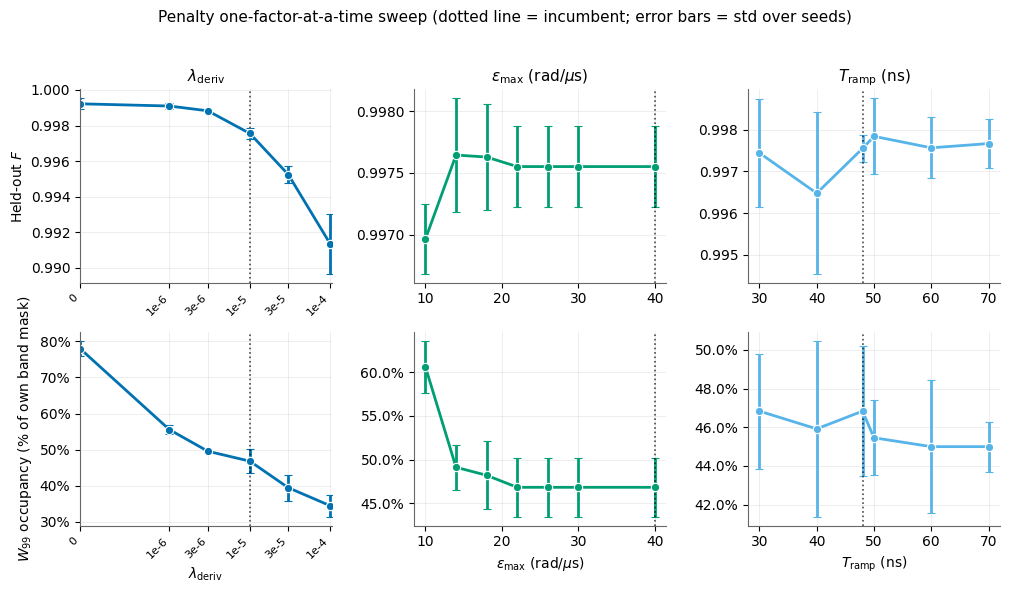

In [6]:
# Three panels now: lambda_deriv (symlog -- it spans decades and has a zero
# rung), then epsilon_max and T_ramp (both linear -- physical quantities that
# span a factor of 3 and 2.3, neither with a zero rung).
#
# New save path: figures/penalty_ofat.{png,pdf} is the PRE-ramp figure that
# Sections 9-15's prose refers to, and overwriting it would silently restate
# this experiment's result as that one's.
fig = pv.plot_ofat(df_ramp, save_path="figures/penalty_ofat_ramp")

**Figure 1. Held-out fidelity (top row) and 99% occupied width $W_{99}$, as a share of the
binding drive's own band mask (bottom row), against each of the three axes.** The dotted vertical
line marks the incumbent value. For $\lambda_{\mathrm{deriv}}$ the leftmost point is the
$\lambda = 0$ negative control; the other two ladders have no zero rung (§7). Fidelity and width
sit on **separate rows rather than a shared twin axis**: the scales are not commensurate, and
overlaying them would imply a trade-off rate that does not exist.

> **Read the y-scales before the shapes.** Every panel is autoscaled independently, so a panel
> spanning $10^{-4}$ in fidelity looks exactly as dramatic as one spanning $10^{-2}$. Shape here
> tells you whether a response is *ordered*; it tells you nothing about whether it is *large*.
> §6.3 puts all three axes on one scale, and §6.2 supplies the floor below which an ordered-
> looking curve is just the optimizer changing basins. Do not rank two axes from this figure.

### 5.1 The ramp's mechanism, plotted

Figure 1's top row asks whether each axis moves *fidelity*. For $T_{\mathrm{ramp}}$ that is the
wrong first question: the ramp is not a fidelity knob, it is a boundary condition, and it should
be judged first on whether it delivers the boundary condition and second on what that costs.

The figure below is that pair. The ramp buys a lower endpoint amplitude
(`endpoint_rel_to_peak` — the largest first/last sample as a fraction of the waveform's own peak)
and was expected to pay for it in pre-image inflation (`max_abs_preimage` — the largest raw
optimizer variable, against a box at 40). The prediction, written before the sweep ran, was that
the two move in **opposite** directions as the ramp lengthens.

**Half of that is right.** The top panel is a clean monotone decrease — a 3.4× reduction in
endpoint amplitude from the shortest ramp to the longest, which is the ramp delivering exactly
what it exists for. The bottom panel is *flat and disordered*: rank correlation $+0.03$ against
ramp duration, with the 70 ns rung sitting lowest of all. The cost the top panel was supposed to
be paid for is not being paid, at least not in this currency and not over this range.

Read the bottom panel as a **negative result about the mechanism**, not as a null measurement.
$\max\lvert x\rvert$ varies by a third across these runs; it just does not vary *with the ramp*.
§6.4 identifies what it does vary with.

Saved figures/penalty_ramp_mechanism.png / .pdf


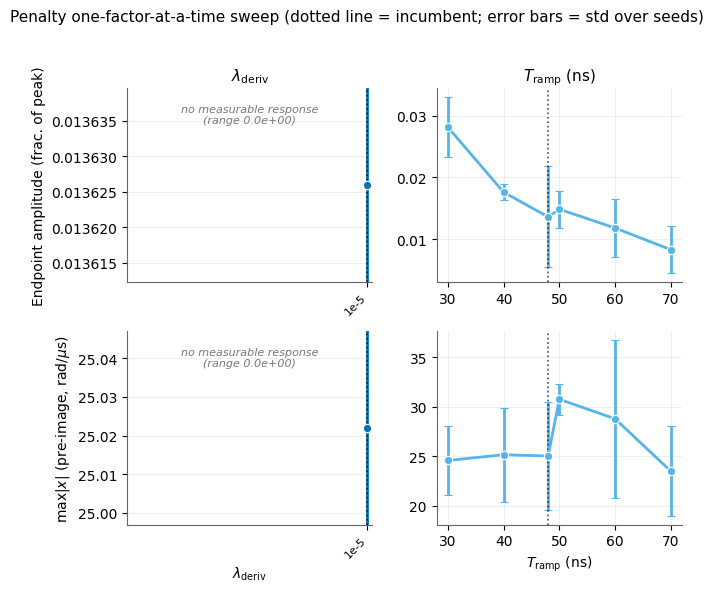

In [7]:
# Restricted to the ramp panel: the other two axes do not reparametrize the
# search space, so neither quantity means the same thing along them.
ramp_rows = df_ramp[(df_ramp.swept == "ramp_ns") | (df_ramp.is_baseline)].copy()
fig = pv.plot_ofat(ramp_rows,
                   metrics=("endpoint_rel_to_peak", "max_abs_preimage"),
                   save_path="figures/penalty_ramp_mechanism")

**Figure 2. What the ramp controls, and what it was assumed to cost.** The $T_{\mathrm{ramp}}$
ladder only — the other two axes do not reparametrize the search space, so neither quantity here
means the same thing along them. *Left:* `endpoint_rel_to_peak`, the first sample's amplitude as a
share of the pulse's own peak, which is the quantity the ramp exists to suppress. *Right:*
`max_abs_preimage`, the largest raw L-BFGS-B variable, against the `hard_amp_limit = 40` box drawn
as a dashed line.

**The left panel is the ramp doing its job; the right panel is the cost it was assumed to charge,
and does not.** `core/ramp.py`'s docstring argues that removing control authority at the edges
makes L-BFGS-B buy it back by inflating the pre-image, which the box then has to stop. Over
30–70 ns that inflation does not happen: $\rho = +0.03$ against ramp duration, and the 70 ns rung
has the *lowest* mean $\max\lvert x\rvert$ in the ladder. Read that argument as being about having
a ramp at all, at the fixed 48 ns default, not as a claim about its duration. §6.4 gives the
numbers and §7.5 identifies what the inflation *does* track.

# 6. What is inert, what is noise, and what actually moves

This section is ordered so that nothing is measured before the yardstick for measuring it
exists. §6.3 removes the two weights that are structurally incapable of doing anything, which
is what makes $\epsilon_{\max}$ a *threshold* axis rather than a weight axis. §6.1 builds the
one noise floor this notebook uses — a single number, derived from this run's own data. §6.2
ranks the three axes against it. §6.2 puts the newest axis, $T_{\mathrm{ramp}}$, on trial under
the same rule that retired $\lambda_{\mathrm{boundary}}$.

### 6.1 Two structurally inert weights, and why the ladder sweeps a threshold instead

Both of the following are properties of the configuration, not of this particular run, and both
are checked **at convergence** against the canonical production pulse `pulses/u_X_main.npy` rather
than in the under-trained regime above.

The output below also makes explicit a distinction that is easy to lose: `amplitude_penalty`
charges $\max(0, |u| - \epsilon_{\max})^2$ **element-wise on the four quadratures**, whereas this
notebook's `peak_amp` column is the *complex-envelope* maximum
$\max(|\epsilon_C|, |\epsilon_T|)$. Those are different numbers, and reading the threshold against
the wrong one is why the previous ladder's $\epsilon_{\max} = 20$ rung looked as though it should
bind and mostly did not.

In [8]:
from core.grape_core import amplitude_penalty, make_hamiltonian, coherent_fidelity_multi_state
from analysis.penalty_sweep import GATE_FACTORIES

u_ref = np.load("pulses/u_X_main.npy")
print(f"canonical converged pulse, peak |u| = {np.abs(u_ref).max():.2f} rad/us "
      f"(element-wise over the (N,4) quadratures -- see below)")
print(f"\nthe amp_max ladder, charged against that pulse at lambda_amp = {BASELINE['amp']}:")
print(f"  {'amp_max':>8}{'g_amp':>12}{'lambda*g_amp':>14}{'|grad|':>10}{'violations':>12}")
for thr in list(AMP_MAX_VALUES) + [FIXED["amp_max"]]:
    g, gr = amplitude_penalty(u_ref, amp_max=thr)
    n = int((np.abs(u_ref) > thr).sum())
    print(f"  {thr:8.0f}{g:12.3f}{BASELINE['amp']*g:14.5f}"
          f"{np.linalg.norm(gr):10.3f}{n:8d}/{u_ref.size}")

Fs = []
for nc in FIXED["trunc_list"]:
    H0, Hc = make_hamiltonian(3, nc)
    pairs = GATE_FACTORIES["X"](n_c=nc, n_t=3)
    F, _ = coherent_fidelity_multi_state(u_ref, H0, Hc, [a for a, b in pairs],
                                         [b for a, b in pairs], 0.002, want_grad=False)
    Fs.append(F)
Fs = np.array(Fs)
disc = sum((Fs[i] - Fs[j])**2 for i in range(len(Fs)) for j in range(len(Fs)) if i != j)
print(f"\nF_coh at n_c={FIXED['trunc_list']}: {np.round(Fs, 9)}")
print(f"disc_cost = sum_(i!=j) (F_i-F_j)^2 = {disc:.3e}")
print(f"   at lambda_disc = {BASELINE['disc']} this contributes {BASELINE['disc']*disc:.3e} "
      f"against an O(1) fidelity term")

# The quantity the THRESHOLD acts on is not the quantity the table reports.
print(f"\nelement-wise max|u| = {np.abs(u_ref).max():.2f}  "
      f"vs complex-envelope peak_amp = "
      f"{max(np.abs(u_ref[:,0]+1j*u_ref[:,1]).max(), np.abs(u_ref[:,2]+1j*u_ref[:,3]).max()):.2f}")

canonical converged pulse, peak |u| = 17.73 rad/us (element-wise over the (N,4) quadratures -- see below)

the amp_max ladder, charged against that pulse at lambda_amp = 8e-05:
   amp_max       g_amp  lambda*g_amp    |grad|  violations
        10    2135.341       0.17083    92.420     162/2200
        14     233.673       0.01869    30.573      51/2200
        18       0.000       0.00000     0.000       0/2200
        22       0.000       0.00000     0.000       0/2200
        26       0.000       0.00000     0.000       0/2200
        30       0.000       0.00000     0.000       0/2200
        40       0.000       0.00000     0.000       0/2200



F_coh at n_c=[22, 24, 26]: [0.99820793 0.99821607 0.99821529]
disc_cost = sum_(i!=j) (F_i-F_j)^2 = 2.421e-10
   at lambda_disc = 0.5 this contributes 1.211e-10 against an O(1) fidelity term

element-wise max|u| = 17.73  vs complex-envelope peak_amp = 19.75


**$\lambda_{\mathrm{amp}}$ is exactly inert, and the ladder sweeps the threshold instead.**
The soft cap is $g_a(u) = \sum \max(0, \lvert u\rvert - \epsilon_{\max})^2$. At the incumbent
$\epsilon_{\max} = 40$ rad/µs it returns exactly `0.0` with an exactly zero gradient on the
**incumbent recipe's** converged pulses, which peak far below it — and multiplying zero by any
weight changes nothing. Sweeping $\lambda_{\mathrm{amp}}$ at the incumbent would be a measurement
of nothing. **The live knob is the threshold**, which is why $\epsilon_{\max}$ is the axis.

That inertness is a property of the *recipe*, not of the cap, and the qualifier matters here: the
$\lambda_{\mathrm{deriv}} = 0$ rung is a far more amplitude-hungry pulse and can approach
$\epsilon_{\max} = 40$ from below. Where it does, the cap stops being inert and that rung is no
longer a clean single-factor manipulation of $\lambda_{\mathrm{deriv}}$ alone — it is
$\lambda_{\mathrm{deriv}} = 0$ *with* an amplitude cap that has begun to act. The `peak_amp`
column of Table 5 is where to check this, bearing in mind it is the complex-envelope maximum and
the cap charges element-wise, so `peak_amp` slightly *over*-states how close the cap is to biting.

**$\lambda_{\mathrm{disc}}$ is negligible by construction.** The three training truncations already
agree to $\sim\!10^{-4}$, so the discrepancy cost is many orders below the $O(1)$ fidelity term.
It cannot *systematically* improve the pulse — but in a non-convex, non-converged optimization a
finite-though-tiny gradient is easily enough to perturb the trajectory into a different local
optimum. That distinction, between "helps" and "jiggles", is what §6.1 has to pin down, and it is
why a perturbation being provably negligible does **not** automatically make its effect on the
reported fidelity zero. Whether it does, in *this* pipeline, is now a measured question rather
than an assumed one.

### 6.2 The noise floor

Every comparison in this notebook needs one number: the smallest difference in held-out fidelity
that this study can tell apart from run-to-run luck. Earlier versions of this section reported
four candidate floors and then chose between them. That was a symptom, not a service — three of
the four were pre-ramp measurements carried across a regime boundary, and picking among them put
a judgement call underneath every downstream claim. This run contains its own null, so the floor
is now derived here, in three steps, and **one number comes out.**

**Step 1 — where is zero?** The amplitude penalty is

$$g_a(u) = \sum \max\big(0,\; \lvert u\rvert - \epsilon_{\max}\big)^2$$

charged **element-wise on the four quadratures**. Whenever $\epsilon_{\max}$ sits above the
pulse's element-wise peak, $g_a$ is exactly $0$ with an exactly zero gradient, and multiplying
zero by any weight changes nothing. Such a rung therefore optimizes the *identical objective* as
the incumbent, under a different configuration hash, in a separate training run. Whatever those
runs disagree by is the noise the **pipeline itself** contributes, with the configuration held
genuinely fixed.

That gives three regimes on the $\epsilon_{\max}$ ladder, and only the last is a null:

| rungs | regime | test |
|---|---|---|
| 10, 14 | **binding** | $g_a > 0$ at convergence — a real peak-power constraint |
| 18 | **shaped** | $g_a = 0$ at the end, but the cap *drove* the pulse onto itself getting there (element-wise peak 17.85–18.07, parked against the cap) |
| 22, 26, 30 | **null** | bit-identical to the incumbent's waveform |

The middle row is why the criterion is bit-identity and not `g_amp == 0`. A cap satisfied with
equality is a real constraint wearing a null's clothes; scoring rung 18 as null would fold a
genuine constraint's effect into the floor and report it as $\sim\!2.8\times10^{-4}$ instead of
its true value.

**Step 2 — what is left.** If Step 1 returns exactly zero, then the pipeline is deterministic at
fixed objective and seed, and **seed choice is the only remaining source of variation.** The
estimate is then the pooled cross-seed standard deviation of `F_ped_heldout_mean` over the
distinct configurations — the three null rungs are dropped from the pool, since they are copies
of the incumbent rather than independent configurations.

**Step 3 — the number.** Two configurations are compared by their seed-means, so the resolution
limit on a *difference* is

$$\mathrm{FLOOR} \;=\; t_{0.975,\,\nu}\; s\, \sqrt{2/n}$$

and for a ladder's *range* over $k$ rungs the noise-only expectation is $d_k\, s/\sqrt{n}$, with
$d_k$ the expected range of $k$ standard normals ($d_5 = 2.326$, $d_6 = 2.534$, $d_7 = 2.704$). A range is a
max-of-differences statistic and is biased upward by noise; comparing it against $d_k s/\sqrt{n}$
is the correct way to account for that, rather than the arbitrary factor of two this section
used to apply.

One check has to be reported honestly rather than assumed: **whether pairing by seed helps.** All
17 configurations were trained at the same three seeds, so if a seed carried a shared offset the
paired contrast would remove it and the floor would drop. The cell below tests that directly.

In [9]:
# THE noise floor. One number, derived here, used everywhere below.
#
# STEP 1 -- where is zero?  `amplitude_penalty` is exactly zero with an exactly
# zero gradient whenever the threshold sits above the pulse's element-wise peak,
# so a rung above that peak optimizes the *identical* objective as the incumbent:
# a different config_hash, a separate training run, provably the same problem.
# Whatever those runs disagree by is the pipeline's own noise.
from scipy import stats

# Seed-averaged frame, used by the rest of this section and by Sections 7-8.
agg_ramp = pv.aggregate_seeds(df_ramp)
assert len(agg_ramp[agg_ramp["is_baseline"]]) == 1, "more than one baseline row"
base_ramp = agg_ramp[agg_ramp["is_baseline"]].iloc[0]      # the incumbent

CACHE_X = "results/penalty_sweep_cache/X"
base_hashes = dict(zip(df_ramp[df_ramp.is_baseline]["seed"],
                       df_ramp[df_ramp.is_baseline]["config_hash"]))

# The row cache can outlive the pulse cache (rows are merged into the CSV;
# pulses are big and get pruned). Skip cleanly rather than taking the whole
# notebook down -- this cell is the only one that needs the waveforms.
missing, rows = [], []
for _, r in df_ramp[df_ramp.swept == "amp_max"].iterrows():
    pa = f"{CACHE_X}/u_{r['config_hash']}.npy"
    pb = f"{CACHE_X}/u_{base_hashes[r['seed']]}.npy"
    if not (os.path.exists(pa) and os.path.exists(pb)):
        missing.append((r["amp_max"], r["seed"]))
        continue
    up, ub = np.load(pa), np.load(pb)
    g, _ = amplitude_penalty(up, amp_max=r["amp_max"])
    b = df_ramp[(df_ramp.is_baseline) & (df_ramp.seed == r["seed"])].iloc[0]
    rows.append({
        "amp_max": r["amp_max"], "seed": r["seed"],
        "g_amp at convergence": g,
        "peak |u| (elementwise)": float(np.abs(up).max()),
        "binds": g > 0,
        "bit-identical to incumbent": bool(np.array_equal(up, ub)),
        "max|du|": float(np.abs(up - ub).max()),
        "|dF_held|": abs(r["F_ped_heldout_mean"] - b["F_ped_heldout_mean"]),
    })
if missing:
    print(f"WARNING: {len(missing)} pulse(s) absent from the cache, excluded from the "
          f"floor: {missing}\n         Re-run the sweep to regenerate them.")
if not rows:
    raise FileNotFoundError(
        f"no cached pulses under {CACHE_X}; this cell needs the waveforms, not just "
        f"the merged CSV. Re-run: python analysis/penalty_sweep.py --gate X --mode ofat "
        f"--tag ramp --seeds 42 43 44")

null_ladder = pd.DataFrame(rows).sort_values(["amp_max", "seed"])
null_ladder["regime"] = np.where(
    null_ladder["binds"], "binding",
    np.where(null_ladder["bit-identical to incumbent"], "null", "shaped"))
display(null_ladder.style.format({"g_amp at convergence": "{:.3g}",
                                  "peak |u| (elementwise)": "{:.2f}",
                                  "max|du|": "{:.2e}", "|dF_held|": "{:.2e}"})
        .hide(axis="index"))

# The null criterion is BIT-IDENTITY, not "g_amp == 0 at convergence" -- see the
# `shaped` regime above, where the cap drove the pulse onto itself and is now
# satisfied with equality. That is a real constraint, not a null.
noise = null_ladder[null_ladder["regime"] == "null"]
pipeline_noise = float(noise["|dF_held|"].max()) if len(noise) else float("nan")
print(f"\nSTEP 1  pipeline noise at fixed objective and seed")
print(f"        {len(noise)} bit-identical replicates "
      f"(amp_max in {sorted(noise['amp_max'].unique())}, all {noise['seed'].nunique()} seeds)")
print(f"        max|du| = {noise['max|du|'].max():.1e}, max|dF_held| = {pipeline_noise:.1e}")
assert pipeline_noise == 0.0, "the pipeline is NOT deterministic; Step 2 no longer follows"
print("        -> exactly zero. The pipeline is deterministic at fixed objective and "
      "seed,\n           so seed choice is the ONLY remaining source of variation.")

# STEP 2 -- pool the cross-seed sd over the DISTINCT configurations. The three
# null rungs are copies of the incumbent, not independent configs, so they would
# triple-count the baseline's variance.
M = "F_ped_heldout_mean"
dup_labels = set(agg_ramp[(agg_ramp.swept == "amp_max")
                          & (agg_ramp.amp_max.isin(noise["amp_max"].unique()))]["label"])
distinct = agg_ramp[~agg_ramp["label"].isin(dup_labels)]
n_seeds = int(df_ramp.groupby("label")["seed"].nunique().min())
s_pooled = float(np.sqrt((distinct[f"{M}_std"].astype(float) ** 2).mean()))
dof = len(distinct) * (n_seeds - 1)

# Is one pooled sd legitimate, or is the spread config-dependent?  Levene is the
# robust test and Bartlett the normality-sensitive one; at n=3 per group Bartlett
# is the fragile one, so report both and let Levene decide.
groups = [g[M].values for _, g in
          df_ramp[df_ramp.label.isin(distinct.label)].groupby("label")]
lev, bar = stats.levene(*groups), stats.bartlett(*groups)
print(f"\nSTEP 2  pooled cross-seed sd over {len(distinct)} distinct configs, "
      f"n={n_seeds} each")
print(f"        s = {s_pooled:.3e}  ({dof} dof)")
print(f"        homogeneity: Levene p = {lev.pvalue:.2f} (robust), "
      f"Bartlett p = {bar.pvalue:.3f} (normality-sensitive)")
print(f"        -> {'Levene finds no evidence against pooling' if lev.pvalue > 0.05 else 'CAUTION: Levene rejects homogeneity'}.")

# Does pairing by seed help?  Only if seeds carry a shared offset across configs.
by_seed = df_ramp.pivot_table(index="label", columns="seed", values=M)
INCUMBENT = base_ramp["label"]
paired_sds = [float((by_seed.loc[l] - by_seed.loc[INCUMBENT]).std(ddof=1))
              for l in distinct["label"] if l != INCUMBENT]
s_paired = float(np.sqrt(np.mean(np.square(paired_sds))))
print(f"        paired-difference sd s_d = {s_paired:.3e} vs unpaired s = {s_pooled:.3e}")
print(f"        -> pairing {'HELPS' if s_paired < s_pooled else 'does NOT help'}: basin "
      f"choice is config-specific, not a shared per-seed\n           offset, so the "
      f"unpaired floor is the right one and one number suffices.")

# STEP 3 -- the number.
FLOOR = float(stats.t.ppf(0.975, dof) * s_pooled * np.sqrt(2 / n_seeds))
# E[range] of k standard normals (Hartley's d2). The amp_max ladder has 7 rungs
# once the incumbent -- which IS its eps_max = 40 rung -- is re-attached, so this
# has to cover more than the 5 and 6 the deriv and ramp ladders need.
D_K = {2: 1.128, 3: 1.693, 4: 2.059, 5: 2.326, 6: 2.534,
       7: 2.704, 8: 2.847, 9: 2.970, 10: 3.078}


def range_floor(k):
    """Range a k-rung ladder is expected to show from seed noise alone."""
    if k not in D_K:
        raise KeyError(f"no Hartley d2 for k={k}; extend D_K rather than interpolating")
    return D_K[k] * s_pooled / np.sqrt(n_seeds)


print(f"\nSTEP 3  FLOOR = t({dof}) * s * sqrt(2/{n_seeds}) = {FLOOR:.3e}")
print(f"        = the smallest difference between two configs' seed-means this study "
      f"can resolve.")
print(f"        Ladder ranges are compared against d_k*s/sqrt(n) instead: "
      f"{range_floor(5):.2e} (k=5), {range_floor(6):.2e} (k=6), "
      f"{range_floor(7):.2e} (k=7).")
print(f"\n        At n=6 (adding seeds 45-47) the floor would fall to "
      f"{stats.t.ppf(0.975, len(distinct)*5) * s_pooled * np.sqrt(2/6):.2e}.")

amp_max,seed,g_amp at convergence,peak |u| (elementwise),binds,bit-identical to incumbent,max|du|,|dF_held|,regime
10.000000,42,0.222,10.16,True,False,1.66e+01,4.81e-04,binding
10.000000,43,0.538,10.29,True,False,1.48e+01,8.36e-04,binding
10.000000,44,0.291,10.18,True,False,1.28e+01,4.38e-04,binding
14.000000,42,0.0495,14.11,True,False,4.40e+00,5.58e-05,binding
14.000000,43,0,13.92,False,False,1.63e+01,3.92e-04,shaped
14.000000,44,0.0476,14.14,True,False,5.11e+00,5.74e-05,binding
18.000000,42,0,17.86,False,False,5.50e-01,7.60e-06,shaped
18.000000,43,0.0044,18.07,True,False,6.82e+00,2.79e-04,binding
18.000000,44,0,17.85,False,False,1.30e+00,5.48e-05,shaped
22.000000,42,0,17.73,False,True,0.00e+00,0.00e+00,null



STEP 1  pipeline noise at fixed objective and seed
        9 bit-identical replicates (amp_max in [np.float64(22.0), np.float64(26.0), np.float64(30.0)], all 3 seeds)
        max|du| = 0.0e+00, max|dF_held| = 0.0e+00
        -> exactly zero. The pipeline is deterministic at fixed objective and seed,
           so seed choice is the ONLY remaining source of variation.

STEP 2  pooled cross-seed sd over 14 distinct configs, n=3 each
        s = 8.821e-04  (28 dof)
        homogeneity: Levene p = 0.71 (robust), Bartlett p = 0.009 (normality-sensitive)
        -> Levene finds no evidence against pooling.
        paired-difference sd s_d = 1.103e-03 vs unpaired s = 8.821e-04
        -> pairing does NOT help: basin choice is config-specific, not a shared per-seed
           offset, so the unpaired floor is the right one and one number suffices.

STEP 3  FLOOR = t(28) * s * sqrt(2/3) = 1.475e-03
        = the smallest difference between two configs' seed-means this study can resolve.
       

**Table 4. The $\epsilon_{\max}$ ladder, and the floor built from it.** One row per rung per
seed. `g_amp at convergence` is the amplitude penalty evaluated on that rung's own final pulse;
`peak |u| (elementwise)` is the quantity the threshold actually acts on. `regime` applies the
three-way test above: **binding** ($g_a > 0$), **shaped** ($g_a = 0$ but the pulse differs — the
cap acted and then released), **null** (bit-identical to the incumbent's waveform).

**The nine null replicates come back bit-identical**, so `max|dF_held|` across them is $0$
exactly. That is a stronger result than a small floor would have been: it means this pipeline
adds nothing of its own, and every difference reported anywhere in this notebook is a
consequence of the configuration or of the seed — never of reduction order. It also collapses the
old four-floor table to one, because it removes three of the four contributions outright.

What survives is seed choice, and the printout gives it as a single number. Note the pairing
check: because the paired-difference sd comes out *larger* than the unpaired one, seeds do not
carry a shared offset that a paired contrast could remove — basin selection is specific to each
configuration. That is a result in its own right, and it is what makes a single unpaired floor
the honest summary rather than a convenience.

### 6.3 Ranking the axes

How far each axis moves each metric, end to end, measured against §6.1's floor. Two comparisons
are made, and they answer different questions:

- **`vs FLOOR`** divides the fidelity range by the smallest resolvable *difference between two
  configurations*. It answers "if I picked the best and worst rung of this ladder, would I be
  able to tell them apart?"
- **`vs noise range`** divides it by $d_k s/\sqrt{n}$, the range a ladder of this length would
  show from seed noise alone. It answers the harder question: "is the *shape* of this ladder
  anything at all?" A range statistic over five or six points is biased upward by noise, and this
  is the comparison that accounts for it.

An axis that fails both has not been shown to do nothing — it has been shown to be **unmeasurable
at this sample size**, which is a different and weaker claim, and §7 keeps the distinction.

In [10]:
def ladder(ax_name, frame=None):
    """That axis's rungs, with the incumbent re-attached and sorted by the knob.

    The incumbent is the shared centre rung of ALL THREE ladders but is
    enumerated once, into whichever ladder `build_ofat_configs` emitted first.
    Without re-attaching it, two of the three ladders are missing their middle
    point and their ranges are computed over a truncated axis.
    """
    frame = agg_ramp if frame is None else frame
    sub = frame[frame["swept"] == ax_name]
    if not sub["is_baseline"].any():
        sub = pd.concat([sub, base_ramp.to_frame().T], ignore_index=True)
    return sub.sort_values(pv.axis_column(ax_name))


rows = []
for ax_name in AXIS_NAMES:
    sub = ladder(ax_name)
    if sub.empty:
        continue
    col = pv.axis_column(ax_name)
    F = sub["F_ped_heldout_mean"].astype(float).values
    rng = F.max() - F.min()
    rows.append({
        "axis": ax_name,
        "rungs": len(sub),
        "swept from": f"{sub[col].min():.3g}",
        "to": f"{sub[col].max():.3g}",
        "range F_held": rng,
        "vs FLOOR": rng / FLOOR,
        "vs noise range": rng / range_floor(len(sub)),
        "range W99 (frac)": sub[COST_METRIC].max() - sub[COST_METRIC].min(),
        "range W99 (MHz)": sub["occ99_MHz"].max() - sub["occ99_MHz"].min(),
        "range endpoint": (sub["endpoint_rel_to_peak"].max()
                           - sub["endpoint_rel_to_peak"].min()),
        "max |x|": sub["max_abs_preimage"].max(),
        "rho(knob, F)": pd.Series(sub[col].astype(float).values).corr(
            pd.Series(F), method="spearman"),
    })
eff = pd.DataFrame(rows).set_index("axis").sort_values("range F_held", ascending=False)
display(eff.style.format({"range F_held": "{:.2e}", "vs FLOOR": "{:.1f}x",
                          "vs noise range": "{:.1f}x",
                          "range W99 (frac)": "{:.1%}", "range W99 (MHz)": "{:.2f}",
                          "range endpoint": "{:.2%}", "max |x|": "{:.1f}",
                          "rho(knob, F)": "{:+.2f}"}))

LIVE = {ax: bool(r["vs FLOOR"] > 1 and r["vs noise range"] > 1 and abs(r["rho(knob, F)"]) > 0.9)
        for ax, r in eff.iterrows()}
print(f"FLOOR = {FLOOR:.2e}   (difference of two seed-means, Section 6.2)\n")
for ax, r in eff.iterrows():
    print(f"  {ax:>8}: range {r['range F_held']:.2e} = {r['vs FLOOR']:.1f}x FLOOR, "
          f"{r['vs noise range']:.1f}x noise range, rho = {r['rho(knob, F)']:+.2f}"
          f"   -> {'LIVE' if LIVE[ax] else 'not identified at n=3'}")
print(f"\n  {sum(LIVE.values())} of {len(LIVE)} axes is a measurable fidelity knob at this "
      f"sample size.")

,rungs,swept from,to,range F_held,vs FLOOR,vs noise range,range W99 (frac),range W99 (MHz),range endpoint,max |x|,"rho(knob, F)"
axis,,,,,,,,,,,
deriv,6,0,0.0001,7.90e-03,5.4x,6.1x,43.5%,19.70,1.92%,32.1,-1.00
ramp_ns,6,30,70,1.37e-03,0.9x,1.1x,1.8%,1.21,1.98%,30.8,+0.77
amp_max,7,10,40,6.78e-04,0.5x,0.5x,13.8%,9.09,2.09%,28.3,-0.08


FLOOR = 1.48e-03   (difference of two seed-means, Section 6.2)

     deriv: range 7.90e-03 = 5.4x FLOOR, 6.1x noise range, rho = -1.00   -> LIVE
   ramp_ns: range 1.37e-03 = 0.9x FLOOR, 1.1x noise range, rho = +0.77   -> not identified at n=3
   amp_max: range 6.78e-04 = 0.5x FLOOR, 0.5x noise range, rho = -0.08   -> not identified at n=3

  1 of 3 axes is a measurable fidelity knob at this sample size.


**Table 5. Effect size per axis.** `range` is $\max - \min$ over that axis's ladder, with the
incumbent re-attached to every ladder. `rho(knob, F)` is the Spearman correlation of held-out
fidelity against the swept knob — it carries the *shape* claim, and it is the right summary for a
short noisy ladder, where strict monotonicity fails on a single out-of-order pair regardless of
how strong the trend is.

An axis is called **live** only if it clears all three: range above `FLOOR`, range above the
noise-only range expectation, and $\lvert\rho\rvert > 0.9$. One axis does.

The last two columns are specific to the ramp: `range endpoint` is how much the ladder moves
`endpoint_rel_to_peak`, which is what the ramp exists to control, and `max |x|` is the largest
raw pre-image reached against a box at 40. Read them for $T_{\mathrm{ramp}}$ and be careful with
them elsewhere — neither of the other two axes reparametrizes the search space, so neither
quantity means quite the same thing along them. §7 makes that comparison properly.

### 6.4 Is $T_{\mathrm{ramp}}$ a live axis, or is it another $\lambda_{\mathrm{boundary}}$?

This is the subsection that has to be willing to conclude *no*.

$\lambda_{\mathrm{boundary}}$ was retired on a specific, stated test: its marginal range in
held-out fidelity straddled the noise floor and was non-monotonic in every row of a
$5\times5$ grid. $T_{\mathrm{ramp}}$ is that weight's structural replacement. Applying a weaker
standard to the replacement than to the thing it replaced would be motivated reasoning, so the
same test is applied here — and now there is only one floor to apply it against, so there is no
room to choose a favourable one.

**The two questions are separable, and conflating them is the trap.** "Does the ramp work?" and
"does its *duration* change fidelity?" are different. The ramp is a **structural** constraint: its
job is to hold the endpoint amplitude down so the waveform is physically playable, not to raise
fidelity. It can be doing that job perfectly while its duration is not a fidelity knob at all. The
cell below answers both, in that order, and reports the second as the weaker claim it is.

In [11]:
lim = float(df_ramp["hard_amp_limit"].iloc[0])
ramp_agg = ladder("ramp_ns")

print(ramp_agg[["ramp_ns", "F_ped_heldout_mean", "F_ped_heldout_mean_std",
                "endpoint_rel_to_peak", "max_abs_preimage", "preimage_at_bound_frac",
                COST_METRIC, "out_of_band_tra"]]
      .to_string(index=False, float_format=lambda v: f"{v:.6g}"))

# QUESTION 1: is T_ramp a fidelity axis?  Same test as every other axis (6.3),
# against the one floor from 6.2.
F = ramp_agg["F_ped_heldout_mean"].astype(float).values
t = ramp_agg["ramp_ns"].astype(float).values
rng = F.max() - F.min()
rho_F = pd.Series(t).corr(pd.Series(F), method="spearman")
g1 = rng > FLOOR
g2 = rng > range_floor(len(ramp_agg))
g3 = abs(rho_F) > 0.9

print(f"\nFLOOR = {FLOOR:.2e} (difference of seed-means); noise-only range over "
      f"{len(ramp_agg)} rungs = {range_floor(len(ramp_agg)):.2e}")
print(f"  range of seed-means  : {rng:.2e}  vs FLOOR       -> {'PASS' if g1 else 'FAIL'}")
print(f"  range of seed-means  : {rng:.2e}  vs noise range -> {'PASS' if g2 else 'FAIL'}")
print(f"  shape                : Spearman rho = {rho_F:+.2f}      -> {'PASS' if g3 else 'FAIL'}")
print(f"\nVERDICT (fidelity): T_ramp is "
      f"{'a LIVE fidelity axis' if (g1 and g2 and g3) else 'NOT identified as a fidelity axis at n=3'}.")

# QUESTION 2: does the ramp do the job it exists for?  Separate question, and the
# answer is not the same. Strict monotonicity is the wrong summary for a 6-point
# ladder with noise, so let the rank correlation carry the claim.
e = ramp_agg["endpoint_rel_to_peak"].astype(float).values
x = ramp_agg["max_abs_preimage"].astype(float).values
rho_e = pd.Series(t).corr(pd.Series(e), method="spearman")
rho_x = pd.Series(t).corr(pd.Series(x), method="spearman")
print(f"\nWhat the ramp is FOR, vs what it was assumed to cost:")
print(f"  endpoint_rel_to_peak : {e[0]:.2%} at {t[0]:.0f} ns -> {e[-1]:.2%} at {t[-1]:.0f} ns"
      f"   ({e.max()/e.min():.1f}x reduction), Spearman rho = {rho_e:+.2f}")
print(f"  max_abs_preimage     : {x[0]:.1f} -> {x[-1]:.1f} of {lim:.0f}"
      f"                      Spearman rho = {rho_x:+.2f}")
print(f"\n  The ramp delivers the endpoint cleanly and does NOT measurably cost pre-image")
print(f"  headroom over 30-70 ns. The authority-loss argument in core/ramp.py is about")
print(f"  having a ramp at all, not about how long it is.")
print(f"\n  So: a longer ramp is close to free. It buys a {e.max()/e.min():.1f}x quieter "
      f"endpoint, spends no\n  measurable fidelity, and does not push the pre-image toward "
      f"its box. That is a\n  useful engineering result even though the axis fails the "
      f"fidelity test above --\n  and it is the ONLY thing this ladder establishes.")

ramp_ns F_ped_heldout_mean F_ped_heldout_mean_std endpoint_rel_to_peak max_abs_preimage preimage_at_bound_frac occ99_frac out_of_band_tra
     30           0.997444             0.00129239            0.0281211          24.5692                      0    0.46832     0.000705397
     40           0.996479             0.00193722            0.0176194          25.1541                      0   0.459137     0.000431448
     48           0.997552            0.000328675             0.013626           25.022                      0    0.46832     0.000815829
     50           0.997844            0.000916451            0.0148668          30.7549                      0   0.454545     0.000385714
     60           0.997568             0.00072861            0.0118303          28.7854            0.000151515   0.449954     0.000149374
     70            0.99767            0.000590837           0.00833289          23.4901                      0   0.449954     0.000292113

FLOOR = 1.48e-03 (difference of s

# 7. Negative controls, and whether any two axes interact

Two questions, in order. **§7.1–§7.2** ask whether the trade-off the study assumes is real, by
taking each constraint away and checking that the pulse gets worse in the way that constraint was
supposed to prevent. **§7.3–§7.4** ask the structural question the sweep was designed to answer:
is there any evidence that two of these axes *interact*, such that the best setting of one depends
on the setting of the other? That decides whether a 2-D grid is worth training, and it is
answered from the data rather than from intuition.

### 7.1 The three axes admit three different nulls

Forcing them into one $\lambda = 0$ column would misdescribe two of them:

- $\lambda_{\mathrm{deriv}}$ has a **true zero rung**. Removing the smoothness penalty is a real,
  trainable configuration, and it is the clean demonstration.
- $\epsilon_{\max}$ is a **threshold, not a weight**. It has no zero — $\epsilon_{\max} = 0$ would
  forbid all drive, which is not "no constraint" but an infinitely tight one. Its null is the
  opposite end: set it where it cannot activate (§6.1).
- $T_{\mathrm{ramp}}$ has **no null rung in this ladder at all**, and that is a gap in the design
  rather than a property of the axis. `ramp_ns = 0` disables the ramp entirely — `core.ramp`
  treats `0` and `None` alike — and that *is* the honest negative control. It was not trained
  here. The archived pre-ramp table is not a clean stand-in either, because those pulses also
  carried the `boundary` penalty, so a comparison against them would confound two changes.

This subsection also runs the check that gates everything after it: whether the optimizer was ever
**clipped** by the box on the raw pre-image. A pulse at the bound was truncated, not converged,
and its fidelity is not comparable to the rest of its ladder.

In [12]:
# Each of the three axes has a different kind of null, and the asymmetry is the
# point -- forcing them into one "lambda = 0" column would misdescribe two of them.
#
#   lambda_deriv : a genuine zero rung. Removing the penalty is a real, trainable
#                  configuration, so this is a true negative control.
#   epsilon_max  : a THRESHOLD, not a weight. It has no zero rung -- eps_max = 0
#                  would forbid all drive. Its null is "set it where it cannot
#                  activate", i.e. the highest non-binding rung (Section 6.2).
#   T_ramp       : NO null rung in this ladder. ramp_ns = 0 disables the ramp
#                  entirely (core.ramp.make_constraint_chain treats 0/None as
#                  off), which is a legitimate negative control -- but it is the
#                  PRE-RAMP regime, it was not trained here, and the archived
#                  pre-ramp table is not a clean stand-in because those pulses
#                  also carried the `boundary` penalty. Reported as a gap, not
#                  papered over.
rows = []
z = agg_ramp[(agg_ramp["swept"] == "deriv") & (agg_ramp["lambda_deriv"] == 0.0)]
if not z.empty:
    rows.append(("lambda_deriv = 0 (true zero rung)", z.iloc[0]))

nb_rungs = sorted(noise["amp_max"].unique()) if len(noise) else []
if nb_rungs:
    z = agg_ramp[(agg_ramp["swept"] == "amp_max") & (agg_ramp["amp_max"] == max(nb_rungs))]
    if not z.empty:
        rows.append((f"epsilon_max = {max(nb_rungs):.0f} (highest non-binding)", z.iloc[0]))

ctrl = pd.DataFrame([{
    "control": name,
    "dF_coh_train": z["F_coh_train"] - base_ramp["F_coh_train"],
    "dF_heldout": z["F_ped_heldout_mean"] - base_ramp["F_ped_heldout_mean"],
    "dW99 (frac)": z[COST_METRIC] - base_ramp[COST_METRIC],
    "dW99 (MHz)": z["occ99_MHz"] - base_ramp["occ99_MHz"],
    "dSpread": z["robustness_spread"] - base_ramp["robustness_spread"],
    "dPeak": z["peak_amp"] - base_ramp["peak_amp"],
    "dEndpoint": z["endpoint_rel_to_peak"] - base_ramp["endpoint_rel_to_peak"],
} for name, z in rows]).set_index("control")
display(ctrl.round(5))

# Is the deriv=0 control significant, or is it inside the floor?  Paired by seed,
# which is the strongest form of the comparison even though pairing does not
# reduce the pooled sd (Section 6.2, Step 2).
ZERO = "deriv=0_amp=8e-05_disc=0.5"
dz = (by_seed.loc[ZERO] - by_seed.loc[INCUMBENT]).values
print(f"lambda_deriv = 0 vs incumbent, per seed: "
      f"{np.array2string(dz, formatter={'float': lambda v: f'{v:+.2e}'})}")
print(f"   mean {dz.mean():+.2e} vs FLOOR {FLOOR:.2e}   "
      f"({'all seeds agree in sign' if (dz > 0).all() or (dz < 0).all() else 'SIGN FLIPS'})")
print(f"   -> it buys fidelity, and Section 8 shows what it costs: it is the one "
      f"configuration\n      the budget rejects.\n")

print(f"T_ramp: no negative control in this ladder. The honest one is ramp_ns = 0")
print(f"        (`python main.py --gate X --ramp-ns 0`), which was not trained here.\n")

# The failure-mode check that gates every fidelity number above: a pulse whose raw
# pre-image sat on the box was TRUNCATED, not converged (the U_Y seed-42 basin),
# and its fidelity is not comparable to the rest of its ladder.
lim = float(df_ramp["hard_amp_limit"].iloc[0])
mx = float(df_ramp["max_abs_preimage"].max())
n_at_bound = int((df_ramp["preimage_at_bound_frac"] > 0).sum())
worst = df_ramp.loc[df_ramp["preimage_at_bound_frac"].idxmax()]
print(f"box check over all {len(df_ramp)} rows: max|x| = {mx:.2f} of {lim:.0f} "
      f"({mx/lim:.0%}), rows with any entry at the bound = {n_at_bound}")
if n_at_bound:
    print(f"   worst: {worst['label'][:44]} seed {worst['seed']:.0f}, "
          f"{worst['preimage_at_bound_frac']:.3%} of entries pinned, "
          f"robustness_spread {worst['robustness_spread']:.2e}")
    print(f"   -> flagged, not excluded: at {worst['preimage_at_bound_frac']:.3%} the box "
          f"shaped a handful of samples,\n      not the pulse. Section 7.4 tests separately "
          f"whether the RAMP is what took it there.")

,dF_coh_train,dF_heldout,dW99 (frac),dW99 (MHz),dSpread,dPeak,dEndpoint
control,,,,,,,
lambda_deriv = 0 (true zero rung),0.0017,0.00167,0.3117,11.51515,-0.00013,9.32512,-0.01207
epsilon_max = 30 (highest non-binding),0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000


lambda_deriv = 0 vs incumbent, per seed: [+1.12e-03 +1.32e-03 +2.58e-03]
   mean +1.67e-03 vs FLOOR 1.48e-03   (all seeds agree in sign)
   -> it buys fidelity, and Section 8 shows what it costs: it is the one configuration
      the budget rejects.

T_ramp: no negative control in this ladder. The honest one is ramp_ns = 0
        (`python main.py --gate X --ramp-ns 0`), which was not trained here.

box check over all 51 rows: max|x| = 40.00 of 40 (100%), rows with any entry at the bound = 1
   worst: deriv=1e-05_amp=8e-05_disc=0.5_ramp=60 seed 42, 0.045% of entries pinned, robustness_spread 5.99e-04
   -> flagged, not excluded: at 0.045% the box shaped a handful of samples,
      not the pulse. Section 7.4 tests separately whether the RAMP is what took it there.


**Table 6. The negative controls.** Each row is a null configuration minus the incumbent, so a
positive `dW99` means the constraint was doing work and a positive `dF_coh_train` means removing
it bought training fidelity — the trade-off the whole exercise assumes.

The two rows are not the same kind of control and should not be read as a ranking against each
other. $\lambda_{\mathrm{deriv}} = 0$ genuinely removes a cost term. The highest non-binding
$\epsilon_{\max}$ removes nothing — by §6.1 it is the *same* optimization problem as the
incumbent — so its row is not a negative control at all but a **null**, and every entry in it is
exactly zero. That is the floor's zero point appearing in a second place, and it is the reason
this table's other row can be read at face value.

$T_{\mathrm{ramp}}$ has no row, and that is a gap in the design rather than an omission from the
table. Its honest control is `ramp_ns = 0`, which disables the ramp entirely and was not trained
here; the archived pre-ramp table is not a substitute, because those pulses also carried the
`boundary` penalty and a comparison against them would confound two changes at once.

### 7.2 Prior evidence: the one grid this project has trained

Before asking whether to train a *new* grid, it is worth recording what the last one returned.
The pre-ramp $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$ sweep
(`tables/penalty_sweep_X_grid_deriv_boundary.csv`, $5\times5$, seed 42) cost 5.9 h and came back
**one-dimensional**: essentially all variation in held-out fidelity ran along
$\lambda_{\mathrm{deriv}}$, and the marginal range along $\lambda_{\mathrm{boundary}}$ sat inside
the noise. That result is why `boundary` was eventually retired as an axis, and why the section
that reported it no longer exists — the ramp replaced the penalty it weighted, so the grid cannot
be regenerated and its heatmap is not comparable to anything in this notebook. The CSV remains on
disk as the record.

The lesson carries even though the data does not: **a grid that turns out to be 1-D costs the
same as one that does not.** So the bar for training a second one is not "both axes look
interesting" — it is a positive reason to expect the two to interact, stated in advance. §7.3
builds that evidence from the OFAT data, and §7.4 applies it.

### 7.3 Do any two axes interact? What OFAT can and cannot say

An OFAT design holds every axis but one at its incumbent value, so it contains **no off-axis
points** and cannot measure an interaction directly. That is a real limitation and it is not
worked around here.

What it *can* measure is the thing that decides whether an interaction is even possible: whether
two axes act on the **same physical response**. Two knobs that move disjoint quantities have no
channel through which to interact, and their effects on fidelity add. Two knobs that fight over
the same quantity have one. So the useful question the existing data answers is not "how big is
the interaction" but "is there a shared mediator, and which way does each axis push it?"

Three tests, in increasing order of how conclusive they are:

**(a) The shared-mediator map.** Spearman $\rho$ of every recorded response against every swept
knob, computed on seed-means **and again within each seed**. The per-seed column is not decoration:
averaging three noisy ladders before correlating them can manufacture a clean monotone response
out of nothing, and it does so here more than once. Read the *columns* for what each axis controls, and the *rows* for where
two axes overlap. The sign matters as much as the magnitude: two axes pushing a shared mediator
the **same** way are redundant with each other, which is an argument against a grid; pushing it
**opposite** ways is the signature of a real trade, which is an argument for one — provided the
correlation survives at the per-seed level.

**(b) The $(W_{99}, F)$ plane — Figure 3.** If every axis just slides the pulse along one common
trade-off curve, then the whole response is one-dimensional and a grid can only land on points the
ladders already reached. If the ladders point in genuinely different directions, it is not.

**(c) A proven zero.** For one pair, no statistics are needed at all — see the printout.

In [13]:
# (a) THE SHARED-MEDIATOR MAP.
#
# OFAT holds every axis but one fixed, so it has no off-axis points and cannot
# measure an interaction. It CAN measure whether two axes act on the same
# response -- the precondition for one. Sign matters as much as magnitude:
# same-sign overlap is redundancy, opposite-sign overlap is a trade.
#
# The seed-mean correlation is NOT enough on its own. Averaging three seeds
# before correlating can manufacture a clean monotone ladder out of three noisy
# ones, so every candidate mediator is also checked PER SEED: the same rank
# correlation computed within each seed, which must agree in sign and stay
# strong. `rho` below is the seed-mean value; `min|rho_s|` is the weakest of the
# three per-seed values, and it is what Gate 2 in Section 7.4 actually uses.
RESPONSES = ["F_ped_heldout_mean", "occ99_frac", "occ99_frac_cav", "occ99_frac_tra",
             "peak_amp", "max_abs_preimage", "endpoint_rel_to_peak", "roughness",
             "robustness_spread", "n_bar_drive", "overfit_gap"]
RHO_MIN = 0.9      # on the seed-mean ladder
RHO_SEED_MIN = 0.7  # on the weakest individual seed


def per_seed_rho(ax_name, response):
    """Rank correlation within each seed, with the incumbent re-attached."""
    col = pv.axis_column(ax_name)
    sub = df_ramp[df_ramp.swept == ax_name]
    if not sub["is_baseline"].any():
        sub = pd.concat([sub, df_ramp[df_ramp.is_baseline]], ignore_index=True)
    return np.array([g.sort_values(col)[col].corr(g.sort_values(col)[response],
                                                  method="spearman")
                     for _, g in sub.groupby("seed")])


med, med_s, snr = {}, {}, {}
for ax_name in AXIS_NAMES:
    sub = ladder(ax_name)
    knob = pd.Series(sub[pv.axis_column(ax_name)].astype(float).values)
    for r in RESPONSES:
        v = pd.Series(sub[r].astype(float).values)
        med[(r, ax_name)] = knob.corr(v, method="spearman")
        rs = per_seed_rho(ax_name, r)
        consistent = bool((rs > 0).all() or (rs < 0).all())
        med_s[(r, ax_name)] = np.abs(rs).min() if consistent else 0.0
        # SNR: the ladder's range against the smallest resolvable difference in
        # THAT response, built the same way FLOOR was (Section 6.2, Step 3).
        s_r = float(np.sqrt((agg_ramp[f"{r}_std"].astype(float) ** 2).mean()))
        snr[(r, ax_name)] = (v.max() - v.min()) / (
            stats.t.ppf(0.975, dof) * s_r * np.sqrt(2 / n_seeds))

mediators = pd.DataFrame({a: {r: med[(r, a)] for r in RESPONSES} for a in AXIS_NAMES})
med_seed = pd.DataFrame({a: {r: med_s[(r, a)] for r in RESPONSES} for a in AXIS_NAMES})
snr_tab = pd.DataFrame({a: {r: snr[(r, a)] for r in RESPONSES} for a in AXIS_NAMES})

print("(a) SHARED-MEDIATOR MAP")
print("    rho        = Spearman of the response against the knob, on SEED MEANS")
print("    min|rho_s| = weakest of the three per-seed correlations, or 0.00 if they")
print("                 disagree in sign. This is the robustness check.")
print("    SNR        = ladder range / smallest resolvable difference; < 1 = not measured.\n")
display(pd.concat({"rho": mediators, "min|rho_s|": med_seed, "SNR": snr_tab}, axis=1)
        .style.format("{:+.2f}", subset="rho")
        .format("{:.2f}", subset="min|rho_s|").format("{:.1f}", subset="SNR")
        .map(lambda v: "font-weight: bold" if abs(v) > RHO_MIN else "", subset="rho")
        .map(lambda v: "color: #b22" if v < RHO_SEED_MIN else "", subset="min|rho_s|"))


def strong(response, ax_name):
    """A knob genuinely controls a response only if BOTH checks hold."""
    return (abs(mediators.loc[response, ax_name]) > RHO_MIN
            and med_seed.loc[response, ax_name] >= RHO_SEED_MIN)


print("responses moved strongly by more than one axis (seed-mean test only):")
for r in RESPONSES:
    hits = {a: mediators.loc[r, a] for a in AXIS_NAMES
            if abs(mediators.loc[r, a]) > RHO_MIN}
    if len(hits) < 2:
        continue
    survives = [a for a in hits if strong(r, a)]
    signs = {np.sign(v) for v in hits.values()}
    note = ("SAME sign -> redundancy, not a trade" if len(signs) == 1
            else "OPPOSITE signs -> would be a channel for interaction")
    print(f"  {r:<22} {', '.join(f'{a}={v:+.2f}' for a, v in hits.items())}")
    print(f"  {'':<22} {note}")
    print(f"  {'':<22} survives the per-seed check on: "
          f"{', '.join(survives) if survives else 'NEITHER axis'}"
          f"{'' if len(survives) == len(hits) else '  <- the seed-mean rho was averaging noise'}")
print()

# (c) THE PROVEN ZERO. No statistics needed: three rungs of the amp_max ladder are
# BIT-IDENTICAL to the incumbent at lambda_deriv = 1e-5 (Section 6.2), which means
# the objective is literally the same function there. A mixed partial of F with
# respect to (lambda_deriv, eps_max) is therefore EXACTLY zero over that region --
# not small, not unmeasured, zero by construction.
inert = [f"{v:g}" for v in sorted(noise["amp_max"].unique())]
n_rungs = len(ladder("amp_max"))
n_dead = len(inert) + 1          # + the incumbent's own eps_max = 40 rung
print(f"(c) PROVEN ZERO INTERACTION: lambda_deriv x eps_max")
print(f"    eps_max in {{{', '.join(inert)}}} is bit-identical to the incumbent at "
      f"lambda_deriv = {BASELINE['deriv']:g},")
print(f"    so the objective there is the SAME function of lambda_deriv, and the mixed")
print(f"    partial d2F/d(lambda_deriv)d(eps_max) is exactly 0 -- not small, zero.")
print(f"    That is {n_dead} of the {n_rungs} rungs of this ladder ({n_dead/n_rungs:.0%}): "
      f"{n_dead/n_rungs:.0%} of any such grid\n    would be a verbatim copy of the "
      f"lambda_deriv ladder, trained again at full cost.")

(a) SHARED-MEDIATOR MAP
    rho        = Spearman of the response against the knob, on SEED MEANS
    min|rho_s| = weakest of the three per-seed correlations, or 0.00 if they
                 disagree in sign. This is the robustness check.
    SNR        = ladder range / smallest resolvable difference; < 1 = not measured.



responses moved strongly by more than one axis (seed-mean test only):
  occ99_frac             deriv=-1.00, amp_max=-0.91, ramp_ns=-0.93
                         SAME sign -> redundancy, not a trade
                         survives the per-seed check on: deriv  <- the seed-mean rho was averaging noise
  occ99_frac_tra         deriv=-1.00, amp_max=-0.91, ramp_ns=-0.93
                         SAME sign -> redundancy, not a trade
                         survives the per-seed check on: deriv  <- the seed-mean rho was averaging noise
  peak_amp               deriv=-0.94, amp_max=+0.91
                         OPPOSITE signs -> would be a channel for interaction
                         survives the per-seed check on: deriv  <- the seed-mean rho was averaging noise
  endpoint_rel_to_peak   deriv=+0.94, ramp_ns=-0.94
                         OPPOSITE signs -> would be a channel for interaction
                         survives the per-seed check on: ramp_ns  <- the seed-mean rho was averag

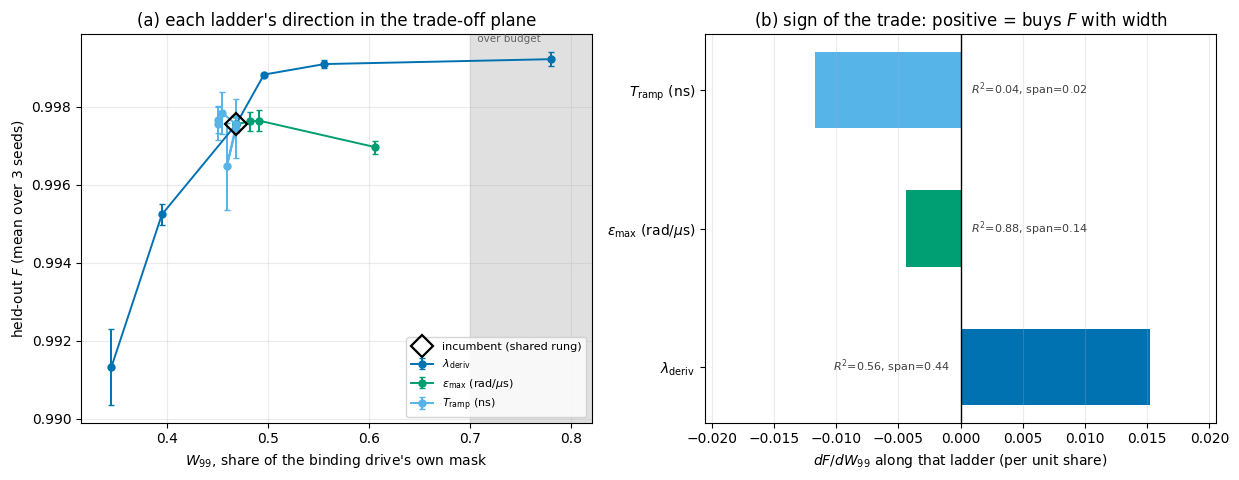

(b) IS THE RESPONSE ONE-DIMENSIONAL?

     deriv: dF/dW99 = +1.520e-02   R^2 = 0.563   W99 span = 0.435
   amp_max: dF/dW99 = -4.369e-03   R^2 = 0.882   W99 span = 0.138
   ramp_ns: dF/dW99 = -1.166e-02   R^2 = 0.041   W99 span = 0.018

  Not collinear -- the ladders do not trace one common curve, so the response
  is NOT 1-D. But only one axis climbs the trade-off: eps_max runs the DOMINATED
  direction (a tighter cap costs width AND fidelity), and T_ramp barely moves in
  W99 at all. That is why eps_max contributes no members to the Pareto front in
  Section 8, and it is a reason not to grid against it rather than a reason to.


In [14]:
# (b) THE (W99, F) PLANE. Built inline rather than through penalty_viz: this is a
# one-off structural diagnostic, not a reusable plot, and pv.plot_pareto already
# owns the (cost, fidelity) scatter that Figure 4 needs.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
ax = axes[0]
fit = {}
for ax_name in AXIS_NAMES:
    sub = ladder(ax_name)
    x = sub[COST_METRIC].astype(float).values
    y = sub["F_ped_heldout_mean"].astype(float).values
    ye = sub[f"F_ped_heldout_mean_std"].astype(float).values / np.sqrt(n_seeds)
    c = pv.SWEPT_COLORS.get(ax_name, "#333333")
    ax.errorbar(x, y, yerr=ye, fmt="o-", color=c, ms=5, lw=1.4, capsize=2.5,
                label=f"{pv.PENALTY_LABEL.get(ax_name, ax_name)}", zorder=3)
    sl, ic, r_, p_, _ = stats.linregress(x, y)
    fit[ax_name] = (sl, r_ ** 2, p_, x.max() - x.min())
b = base_ramp
ax.plot([b[COST_METRIC]], [b["F_ped_heldout_mean"]], "D", mfc="none", mec="k",
        ms=11, mew=1.6, label="incumbent (shared rung)", zorder=4)
xhi = float(agg_ramp[COST_METRIC].max()) + 0.04
ax.set_xlim(float(agg_ramp[COST_METRIC].min()) - 0.03, xhi)
ax.axvspan(COST_BUDGET, xhi, color="0.88", zorder=0)
ax.text(COST_BUDGET + 0.004, ax.get_ylim()[1], " over budget", fontsize=7.5,
        va="top", color="0.4")
ax.set_xlabel(r"$W_{99}$, share of the binding drive's own mask")
ax.set_ylabel(r"held-out $F$ (mean over 3 seeds)")
ax.set_title("(a) each ladder's direction in the trade-off plane")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)

# Right panel: the same information as a slope, which is what actually decides
# whether the response is 1-D.
ax = axes[1]
names = list(fit)
sl = [fit[k][0] for k in names]
cols = [pv.SWEPT_COLORS.get(k, "#333") for k in names]
ax.barh(range(len(names)), sl, color=cols, height=0.55)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(names)))
ax.set_yticklabels([pv.PENALTY_LABEL.get(k, k) for k in names])
# Annotate just inside the bar tip, so a negative bar's label never runs off the
# left edge into the tick labels.
lim = 1.35 * max(abs(v) for v in sl)
ax.set_xlim(-lim, lim)
for i, k in enumerate(names):
    v, r2, p, span = fit[k]
    # Annotate on the OPPOSITE side of zero from the bar: the bar itself can be
    # long enough that neither end of it has room for the label.
    pad = 0.04 * lim
    ax.text(pad if v < 0 else -pad, i, f"$R^2$={r2:.2f}, span={span:.2f}",
            va="center", ha="left" if v < 0 else "right", fontsize=8, color="0.25")
ax.set_xlabel(r"$dF/dW_{99}$ along that ladder (per unit share)")
ax.set_title("(b) sign of the trade: positive = buys $F$ with width")
ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(f"figures/penalty_2d_structure.{ext}", dpi=160, bbox_inches="tight")
plt.show()

print("(b) IS THE RESPONSE ONE-DIMENSIONAL?\n")
for k in names:
    s, r2, p, span = fit[k]
    print(f"  {k:>8}: dF/dW99 = {s:+.3e}   R^2 = {r2:.3f}   W99 span = {span:.3f}")
print("\n  Not collinear -- the ladders do not trace one common curve, so the response")
print("  is NOT 1-D. But only one axis climbs the trade-off: eps_max runs the DOMINATED")
print("  direction (a tighter cap costs width AND fidelity), and T_ramp barely moves in")
print("  W99 at all. That is why eps_max contributes no members to the Pareto front in")
print("  Section 8, and it is a reason not to grid against it rather than a reason to.")

**Figure 3. Is the response two-dimensional?** *(a)* Each OFAT ladder drawn in the
$(W_{99}, F)$ plane, seed-averaged, with standard errors over the three seeds; the open diamond is
the incumbent, which is the shared centre rung of all three ladders, and the shaded band is
outside the 70% budget. *(b)* The same ladders as a single number each — the slope of held-out
fidelity against occupied width — annotated with the fit's $R^2$ and the ladder's span in
$W_{99}$.

**The three ladders point in different directions, so the response is not one-dimensional — but
only one of those directions is useful.** $\lambda_{\mathrm{deriv}}$ climbs the trade-off, buying
fidelity with width across a span of 0.44 in allowance. $\epsilon_{\max}$ has a *negative* slope:
tightening the cap costs width **and** fidelity at once, which is a strictly dominated direction,
and it is the reason no $\epsilon_{\max}$ rung appears on the Pareto front in §8.
$T_{\mathrm{ramp}}$ spans 0.018 in $W_{99}$ — it barely moves along this plane at all, which is
consistent with its being a structural constraint rather than a regularizer.

Read together with the mediator map: all three axes appear to move $W_{99}$ in the **same**
direction, but only $\lambda_{\mathrm{deriv}}$ survives the per-seed check, and only it converts
that movement into fidelity. Where two axes do overlap it is as redundancy, not as a trade — and
redundancy is the case where a grid returns least.

### 7.4 Verdict: is a 2-D grid worth training?

This study trains no grid. Whether one is *worth* training is a result, and the rule for deciding
it was stated before the numbers were read, so that it could not be tuned to them.

A grid costs 9–25 configurations per seed and answers exactly one question: **do two axes
interact**, i.e. does the best setting of one depend on the setting of the other? Two axes that
are each live but act additively do not need a grid — the ladders already give the answer. §7.2 is
the cautionary precedent: the last grid this project trained cost 5.9 h and returned
one-dimensionality.

**Train a grid only if all four gates pass.**

| gate | test |
|---|---|
| **0 — possible** | The interaction's *mechanism* must be reachable in this parameter window. For $T_{\mathrm{ramp}} \times$ `hard_amp_limit` specifically: if no run ever comes near the box, the two cannot interact at these settings and the grid is pre-registered **not** to run. |
| **1 — both marginals live** | Each axis must clear §6.2's test on its own ladder: range above `FLOOR`, above the noise-only range, and $\lvert\rho\rvert > 0.9$. |
| **2 — a shared mediator** | The two axes must move the same measured response (§7.3a), **in opposite directions**, and the correlation must survive **within each seed** ($\lvert\rho\rvert > 0.9$ on the seed means *and* $\min\lvert\rho_s\rvert \geq 0.7$ across seeds). Same-sign overlap is redundancy and predicts an additive, not an interacting, response. |
| **3 — named mechanism** | A falsifiable prediction written down before the grid runs — not merely "both matter". |
| **4 — resolvable** | The smallest interaction contrast worth detecting must exceed `FLOOR` at $n$ per cell. Below that, a grid cannot resolve what it is being asked to resolve. |

**The candidate pairs, named before the sweep ran:**

- **$T_{\mathrm{ramp}} \times$ `hard_amp_limit`** — the physically coupled pair, on the argument in
  `core/ramp.py`: the ramp removes control authority at the edges, L-BFGS-B buys it back by
  inflating the *pre-image*, and `hard_amp_limit` is the only thing that bounds that inflation.
  Prediction: the ramp's effect on fidelity depends on the box, with a boundary in the plane
  beyond which runs fall into the high-leakage basin. Gated entirely on Gate 0.
- **$\lambda_{\mathrm{deriv}} \times T_{\mathrm{ramp}}$** — both act on time-domain smoothness, one
  in the interior and one at the edges. The envelope's slope is $\sim\!2.3\times$ steeper at 30 ns
  than at 70 ns, so $T_{\mathrm{ramp}}$ changes *what $\lambda_{\mathrm{deriv}}$ is charging for*.
  Prediction: the optimal $\lambda_{\mathrm{deriv}}$ shifts **down** as the ramp shortens.
- **$\lambda_{\mathrm{deriv}} \times \epsilon_{\max}$** — the current `--grid-x/--grid-y` default,
  and the weakest of the three even before the data: $\epsilon_{\max}$ is inert over most of its
  ladder by construction (§6.1).

In [15]:
# Apply the rule above. Nothing here is tuned to the outcome -- the thresholds are
# the ones stated in the markdown and FLOOR is Section 6.2's single measurement.
lim = float(df_ramp["hard_amp_limit"].iloc[0])
mx = float(df_ramp["max_abs_preimage"].max())
n_at_bound = int((df_ramp["preimage_at_bound_frac"] > 0).sum())

# --- GATE 0, for the ramp x hard_amp_limit pair only ---
#
# Two conditions, and BOTH are needed. It is not enough that some configuration
# somewhere approaches the box: the proposed interaction is that *lengthening the
# ramp* drives the pre-image into it, so the ramp ladder itself has to be what
# moves max|x|. A deriv=0 run pressing against the box shows the box is reachable
# in this window (0a) but says nothing about the ramp (0b).
ramp_x = ladder("ramp_ns")["max_abs_preimage"].astype(float).values
gate0a = (n_at_bound > 0) or (mx > 0.75 * lim)
rho_rx = mediators.loc["max_abs_preimage", "ramp_ns"]
gate0b = bool(rho_rx > 0.9 and ramp_x.max() / lim > 0.75)
gate0 = gate0a and gate0b

print("GATE 0  (is ramp x hard_amp_limit a REACHABLE interaction?)")
print(f"  0a  box reachable at all : max|x| = {mx:.2f} of {lim:.0f} ({mx/lim:.0%}), "
      f"rows at the bound = {n_at_bound}   -> {'PASS' if gate0a else 'FAIL'}")
print(f"  0b  the RAMP drives it   : max|x| along the ladder "
      f"{np.array2string(ramp_x, precision=1)}, Spearman rho = {rho_rx:+.2f}, "
      f"reaches {ramp_x.max()/lim:.0%} of the box   -> {'PASS' if gate0b else 'FAIL'}")
print(f"  -> GATE 0 {'PASS' if gate0 else 'FAIL'}: "
      + ("the ramp does push the pre-image toward a box that can bind"
         if gate0 else
         "the box is reachable, but not by the ramp, so the two cannot interact\n     "
         "at these settings. The honest follow-up is NOT a grid at hard_amp_limit = 40 "
         "but a\n     1-D sweep that lowers the box into the observed max|x| range."))

# --- GATE 1, per axis: reuse Section 6.3's verdict verbatim, no second standard ---
print(f"\nGATE 1  (per-axis liveness), FLOOR = {FLOOR:.2e}")
for ax_name in AXIS_NAMES:
    r = eff.loc[ax_name]
    print(f"  {ax_name:>8}: range {r['range F_held']:.2e} = {r['vs FLOOR']:.1f}x FLOOR, "
          f"{r['vs noise range']:.1f}x noise range, rho = {r['rho(knob, F)']:+.2f}   "
          f"-> {'LIVE' if LIVE[ax_name] else 'not identified'}")

# --- GATE 2: a shared mediator, opposite signs, surviving the per-seed check ---
#
# `strong()` (7.3a) requires BOTH the seed-mean |rho| > 0.9 AND per-seed
# correlations that agree in sign with min|rho_s| >= 0.7. A seed-mean rho alone
# is not enough: averaging three noisy ladders can produce a clean monotone one.
print("\nGATE 2  (shared mediator, opposite signs, robust per seed)")

PAIRS = [("ramp_ns", "hard_amp_limit"), ("deriv", "ramp_ns"), ("deriv", "amp_max")]
shared = {}
for a, b in PAIRS:
    if b not in AXIS_NAMES:
        shared[(a, b)] = None
        print(f"  {a} x {b:<16}: `{b}` is not an axis in this sweep -- untestable here")
        continue
    hits = [(r, mediators.loc[r, a], mediators.loc[r, b])
            for r in RESPONSES
            if abs(mediators.loc[r, a]) > RHO_MIN and abs(mediators.loc[r, b]) > RHO_MIN]
    passing = [(r, ra, rb) for r, ra, rb in hits
               if np.sign(ra) != np.sign(rb) and strong(r, a) and strong(r, b)]
    shared[(a, b)] = bool(passing)
    if not hits:
        print(f"  {a} x {b:<16}: no response is moved strongly by both -> FAIL")
    for r, ra, rb in hits:
        why = ("same sign = redundant" if np.sign(ra) == np.sign(rb)
               else ("OPPOSITE and robust" if (strong(r, a) and strong(r, b))
                     else "opposite, but the seed-mean rho does not survive per seed "
                          f"(min|rho_s| {med_seed.loc[r, a]:.2f} / {med_seed.loc[r, b]:.2f})"))
        verdict_r = "PASS" if (r, ra, rb) in passing else "FAIL"
        print(f"  {a} x {b:<16}: {r} ({ra:+.2f}, {rb:+.2f}) -> {why} -> {verdict_r}")

# --- GATE 4: resolvability ---
print(f"\nGATE 4  (resolvable)")
print(f"        FLOOR at n={n_seeds} is {FLOOR:.2e}; an interaction contrast smaller than "
      f"that\n        cannot be read off a grid at this replication.")

# --- VERDICT ---
verdict = [
    ("ramp_ns x hard_amp_limit", gate0 and LIVE.get("ramp_ns", False)),
    ("deriv x ramp_ns", LIVE.get("deriv", False) and LIVE.get("ramp_ns", False)
     and bool(shared[("deriv", "ramp_ns")])),
    ("deriv x amp_max", LIVE.get("deriv", False) and LIVE.get("amp_max", False)),
]
print("\nVERDICT")
for name, ok in verdict:
    print(f"  {name:<26} {'TRAIN' if ok else 'do not train'}")

if not any(ok for _, ok in verdict):
    n6 = stats.t.ppf(0.975, len(distinct) * 5) * s_pooled * np.sqrt(2 / 6)
    n_dead = len(noise["amp_max"].unique()) + 1
    n_rungs = len(ladder("amp_max"))
    print("\n  No pair clears the rule, and none fails for a merely marginal reason:")
    print(f"    - Gate 1: only {sum(LIVE.values())} of 3 axes is live on fidelity, so no "
          f"pair can have two\n              live marginals.")
    print(f"    - Gate 2: no pair has an opposite-sign shared mediator that survives the")
    print(f"              per-seed check. The two candidates -- deriv x ramp_ns through")
    print(f"              endpoint_rel_to_peak, deriv x amp_max through peak_amp -- both rest")
    print(f"              on seed-mean correlations that weaken sharply within seeds, which")
    print(f"              is what averaging three noisy ladders does.")
    print(f"    - And {n_dead} of the {n_rungs} rungs of a deriv x eps_max grid "
          f"({n_dead/n_rungs:.0%}) is provably a\n              verbatim copy of the deriv "
          f"ladder (7.3c).")
    print("\n  Spend the budget on SEED REPLICATION instead. It costs the same as a 3x3")
    print("  grid at 3 seeds and it tightens every claim in Sections 5-8 rather than one")
    print("  cell of one grid:")
    print(f"    FLOOR  {FLOOR:.2e} at n=3  ->  {n6:.2e} at n=6   (seeds 45-47, 51 runs)")
    promoted = [(l, float(by_seed.loc[l].mean() - by_seed.loc[INCUMBENT].mean()))
                for l in distinct["label"] if l != INCUMBENT]
    promoted = [(l, d) for l, d in promoted if n6 < abs(d) <= FLOOR]
    for l, d in sorted(promoted, key=lambda t: -abs(t[1])):
        print(f"    would promote {l[:38]:<38} (delta = {d:+.2e}) from unresolved to resolved")

GATE 0  (is ramp x hard_amp_limit a REACHABLE interaction?)
  0a  box reachable at all : max|x| = 40.00 of 40 (100%), rows at the bound = 1   -> PASS
  0b  the RAMP drives it   : max|x| along the ladder [24.6 25.2 25.  30.8 28.8 23.5], Spearman rho = +0.03, reaches 77% of the box   -> FAIL
  -> GATE 0 FAIL: the box is reachable, but not by the ramp, so the two cannot interact
     at these settings. The honest follow-up is NOT a grid at hard_amp_limit = 40 but a
     1-D sweep that lowers the box into the observed max|x| range.

GATE 1  (per-axis liveness), FLOOR = 1.48e-03
     deriv: range 7.90e-03 = 5.4x FLOOR, 6.1x noise range, rho = -1.00   -> LIVE
   amp_max: range 6.78e-04 = 0.5x FLOOR, 0.5x noise range, rho = -0.08   -> not identified
   ramp_ns: range 1.37e-03 = 0.9x FLOOR, 1.1x noise range, rho = +0.77   -> not identified

GATE 2  (shared mediator, opposite signs, robust per seed)
  ramp_ns x hard_amp_limit  : `hard_amp_limit` is not an axis in this sweep -- untestable here
 

### 7.5 A pair the data suggests, which was *not* pre-registered

Label this honestly: the three pairs in §7.4 were named before the sweep ran; this one was not. It
comes out of the results and is therefore a **hypothesis to test**, not a finding.

**$\lambda_{\mathrm{deriv}} \times$ `hard_amp_limit`.** The sweep set out to show that ramp
duration drives pre-image inflation toward the box. It does not — $\rho = +0.03$ on the seed
means, the per-seed correlations disagree in sign, and the 70 ns rung has the *lowest* mean
$\max\lvert x\rvert$ of the ladder. $\lambda_{\mathrm{deriv}}$ is the knob that moves
$\max\lvert x\rvert$: $\rho = -0.94$ on the seed means, falling from 32.1 at
$\lambda_{\mathrm{deriv}} = 0$ to 20.7 at $10^{-4}$, and — unlike the ramp — the three per-seed
correlations at least agree in sign. The mechanism Gate 3 asks for therefore exists, and it
attaches to a *different pair* than the one it was written for: the derivative penalty is what
charges for the large step-to-step excursions an inflated pre-image produces, and
`hard_amp_limit` is what truncates them when the penalty is too weak to.

Falsifiable prediction: **the $\lambda_{\mathrm{deriv}} = 0$ rung's fidelity should depend on
`hard_amp_limit`, and the $\lambda_{\mathrm{deriv}} = 10^{-4}$ rung's should not** — the
low-$\lambda$ end is already running at 80% of the box, the high end at 52%.

This pair still has to clear Gates 1, 2 and 4 like any other, and `hard_amp_limit` would have to be
promoted to an axis first (one line in `FIXED_AXES`, plus a ladder). It is recorded here so the
next study starts from the mechanism the data actually supports rather than the one this study
assumed.

**Two earlier readings have to be qualified, and the per-seed column in §7.3a is what qualifies
them.** Both were stated from seed-mean rank correlations, which is exactly the statistic that
averaging can flatter.

- *"$\lambda_{\mathrm{deriv}}$ and $T_{\mathrm{ramp}}$ fight over the endpoint."* The seed-mean
  correlations do look like that, $+0.94$ and $-0.94$ with opposite signs. Within seeds the ramp
  holds up reasonably ($\min\lvert\rho_s\rvert = 0.71$, all three negative) but
  $\lambda_{\mathrm{deriv}}$ does not ($0.77$, $0.77$, $0.37$ — same sign throughout, but weak
  enough at one seed that the ladder is not ordered there). The shared-mediator claim is
  therefore **not established**, which is why Gate 2 fails on it. It is not refuted either: three
  seeds cannot separate "weak but real" from "nothing", and that is the same limitation §7.4's
  closing recommendation is about.
- *"$\lambda_{\mathrm{deriv}}$ drives pre-image inflation, $\rho = -0.94$."* Per seed this is
  $-0.14$, $-0.77$, $-1.00$. Consistently signed, but one seed carries almost none of it. The
  direction is safe to quote; the strength is not, and the prediction above should be tested by
  *sweeping* `hard_amp_limit`, not by leaning on this correlation.

# 8. Pareto front and the budgeted recommendation

This section turns the sweep into one recommended configuration and shows the reasoning behind
it. The five subsections build on each other in order. §8.1 fixes the selection rule before
looking at any results, so the rule cannot be fit to the data after the fact. §8.2 applies that
rule to see what it keeps and what it throws out, and by how much. §8.3 stress-tests one specific
design choice inside the rule — budgeting each drive against its own allowance rather than
comparing raw bandwidth — to check it is not a distinction without a difference. §8.4 names the
winning configuration and prices the trade it makes against the current default. §8.5 checks how
much that answer depends on the one number, 70%, that the whole section rests on.

Everything here reads `agg_ramp`, the post-ramp OFAT frame: 17 configurations, three seeds each.

### 8.1 Selection rule

This subsection defines two things that are easy to conflate: the **front**, which is every
configuration Figure 4 draws as non-dominated, and the **recommendation**, the single point
`pv.recommend` picks off that front. Keep them separate: the front is a property of the data, the
recommendation is a choice made on top of it.

**The front.** A configuration is *non-dominated* when no other configuration is simultaneously
narrower in occupied width and higher in held-out fidelity. Figure 4 plots every non-dominated
configuration, whether it is within budget or not. The front by itself says nothing about the
budget.

**The recommendation.** Picking one point off the front follows a two-step rule, fixed before the
sweep was scored so nothing here retrofits a boundary to the data:

1. **Filter: budget-feasible only.** Express each configuration's 99% occupied width as a
   share of *that drive's own* band mask, separately for cavity and transmon
   (`occ99_frac_cav`, `occ99_frac_tra`). Keep the configuration only if **both** shares are
   at most `COST_BUDGET` (70%). Because each drive is already normalised against its own
   allowance, comparing the single worse (binding) share against one threshold enforces both
   per-drive constraints at once (§1.4).
2. **Rank: highest held-out fidelity wins.** Among the survivors, sort by mean `F_held`, the
   held-out fidelity that training never sees, and take the maximum. Ties break toward the
   lower $W_{99}$, the narrower pulse.

This is exactly what `pv.recommend` computes: filter on `occ99_frac <= COST_BUDGET`, then sort.
It is mechanism 3 of §1.4, applied to a table of pulses trained with no knowledge of the budget.

**One thing the rule does not know about is the floor.** Non-domination is a strict inequality: a
configuration joins the front if it beats its neighbours by $10^{-6}$, which §6.1 says is
indistinguishable from noise. The front is therefore an upper bound on how many configurations
genuinely matter, and §8.2 separates the members that survive a significance test from the ones
that do not.

Saved figures/penalty_pareto.png / .pdf


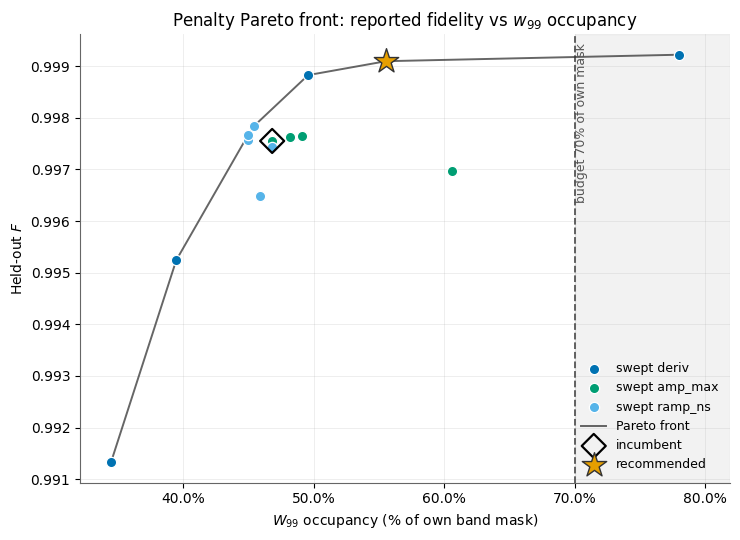

In [16]:
fig, rec = pv.plot_pareto(agg_ramp, save_path="figures/penalty_pareto",
                          max_cost=COST_BUDGET)

**Figure 4. Reported held-out fidelity against the 99% occupied width, as a share of each
drive's own band mask, one marker per configuration.** The x-axis is the worse of the two drives,
so a point at 60% means "the more demanding drive uses 60% of what that drive is allowed". The
shaded region is outside the 70% budget; the star is the recommendation, the open diamond the
incumbent, and the connected markers trace the non-dominated front.

All 17 points are **post-ramp**, single-phase, three seeds, the same data as Figures 1–3. This
figure was regenerated from `tables/penalty_sweep_X_ofat_ramp.csv`; the pre-ramp version it
replaces mixed an OFAT ladder with a 5×5 grid at one seed and is not comparable to it.

### 8.2 The front, and what the 70% budget rejects

The next cell prints three things: the non-dominated front, a significance test on each of its
members against the incumbent, and the separate list of configurations that exceed the 70% budget
on their binding drive.

In [17]:
front = agg_ramp.iloc[pv.pareto_front(agg_ramp)].copy()
front["within_budget"] = front[COST_METRIC] <= COST_BUDGET

# A Pareto front does not know about the noise floor -- non-domination is a strict
# inequality, so a config joins on a 1e-6 lead. Test every member against the
# incumbent, paired by seed, and say which ones are actually distinguishable.
def vs_incumbent(label):
    if label == INCUMBENT:
        return 0.0, np.nan, "incumbent"
    d = (by_seed.loc[label] - by_seed.loc[INCUMBENT]).values
    t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
    p = float(2 * stats.t.sf(abs(t), len(d) - 1))
    same = (d > 0).all() or (d < 0).all()
    return d.mean(), p, ("resolved" if (p < 0.05 and same) else "within noise")


front[["dF vs incumbent", "p (paired)", "verdict"]] = [
    vs_incumbent(l) for l in front["label"]]
# to_string's `formatters` silently skip object-dtype columns, so cast first.
front[["dF vs incumbent", "p (paired)"]] = front[["dF vs incumbent",
                                                  "p (paired)"]].astype(float)
print(f"Pareto front: {len(front)} of {len(agg_ramp)} configurations\n")
print(front[["label", "F_ped_heldout_mean", "occ99_frac_cav", "occ99_frac_tra",
             "binding_drive", "within_budget", "dF vs incumbent", "p (paired)", "verdict"]]
      .sort_values("F_ped_heldout_mean")
      .to_string(index=False,
                 formatters={"occ99_frac_cav": "{:.1%}".format,
                             "occ99_frac_tra": "{:.1%}".format,
                             "dF vs incumbent": "{:+.2e}".format,
                             "p (paired)": "{:.3f}".format}))
n_real = int((front["verdict"] == "resolved").sum())
n_noise = int((front["verdict"] == "within noise").sum())
print(f"\n  {n_real} of {len(front)} front members are distinguishable from the incumbent; "
      f"{n_noise} are on the\n  front by noise. Non-domination is a strict inequality, so the "
      f"front's LENGTH is an upper\n  bound on how many configurations matter, not a count "
      f"of them.")

infeasible = agg_ramp[agg_ramp[COST_METRIC] > COST_BUDGET]
print(f"\ninfeasible ({COST_METRIC} > {COST_BUDGET:.0%} of own mask): "
      f"{len(infeasible)} of {len(agg_ramp)}")
for _, r in infeasible.sort_values(COST_METRIC).iterrows():
    print(f"   {r['label']:40s} cav {r['occ99_frac_cav']:5.1%}  "
          f"tra {r['occ99_frac_tra']:5.1%}  binding={r['binding_drive']}  "
          f"F={r['F_ped_heldout_mean']:.6f}")
span_F = front["F_ped_heldout_mean"].max() - front["F_ped_heldout_mean"].min()
span_W = front[COST_METRIC].max() - front[COST_METRIC].min()
print(f"\nfront extent: {span_F:.2e} in held-out F for {span_W:.1%} of allowance "
      f"({span_F/FLOOR:.1f} floors of fidelity)")

Pareto front: 7 of 17 configurations

                                 label  F_ped_heldout_mean occ99_frac_cav occ99_frac_tra binding_drive  within_budget dF vs incumbent p (paired)      verdict
       deriv=0.0001_amp=8e-05_disc=0.5            0.991326          30.9%          34.4%           tra           True       -6.23e-03      0.027     resolved
        deriv=3e-05_amp=8e-05_disc=0.5            0.995241          29.2%          39.5%           tra           True       -2.31e-03      0.033     resolved
deriv=1e-05_amp=8e-05_disc=0.5_ramp=70            0.997670          35.9%          45.0%           tra           True       +1.18e-04      0.660 within noise
deriv=1e-05_amp=8e-05_disc=0.5_ramp=50            0.997844          36.5%          45.5%           tra           True       +2.92e-04      0.652 within noise
        deriv=3e-06_amp=8e-05_disc=0.5            0.998827          42.6%          49.6%           tra           True       +1.28e-03      0.035     resolved
        deriv=

**Table 7. The non-dominated front, its significance, and every configuration the budget
rejects.** `within_budget` applies the 70%-of-own-mask line to each front member, the two
per-drive shares are shown separately, and `binding_drive` names the one the max is taken from.
`dF vs incumbent` and `p (paired)` compare each member to the incumbent seed by seed; `verdict`
is `resolved` only when the paired test clears $p < 0.05$ **and** all three seeds agree in sign.

**Two of the seven front members are there by noise.** Both are $T_{\mathrm{ramp}}$ rungs, both
sit a few $10^{-4}$ above the incumbent, and both have seeds that disagree about the sign. This is
what §6.1's floor is for: non-domination is a strict inequality and will happily promote a
$10^{-6}$ lead, so the front's *length* is not a count of configurations that matter. The
$\lambda_{\mathrm{deriv}}$ members are the real ones, which is the same conclusion §6.2 reached
from a completely different direction.

**Exactly one configuration of 17 is infeasible, and it is a negative control**:
$\lambda_{\mathrm{deriv}} = 0$, at 78.0% of the cavity's own allowance. It is also the
highest-fidelity configuration in the study. The budget rejects the one recipe that removes a
constraint entirely — which is the sense in which the budget is doing the work the penalty study
exists to do — and it rejects nothing else. §8.3 takes up *which drive* that rejection is about,
because the answer is not the obvious one.

### 8.3 Which drive binds, and why per-drive normalisation earns its keep

The question this subsection answers: does budgeting each drive against its own allowance, instead
of comparing raw bandwidth in MHz, actually change which configurations survive? The two drives
are budgeted separately, and whether that is a distinction without a difference is an empirical
question, not a stylistic one. Post-ramp the answer is sharper than it was pre-ramp, because the
whole effect now lands on a single configuration.

In [18]:
# Occupied width per axis and per drive, in MHz and as a share of that drive's own
# mask, plus which drive the budget binds on.
for ax_name in AXIS_NAMES:
    sub = df_ramp[df_ramp.swept == ax_name]
    print(f"{ax_name}  (n={len(sub)} runs)")
    for drive in ("cav", "tra"):
        mhz, frac = sub[f"occ99_{drive}_MHz"], sub[f"occ99_frac_{drive}"]
        print(f"   {drive}: {mhz.min():5.2f}-{mhz.max():5.2f} MHz "
              f"= {frac.min():5.1%}-{frac.max():5.1%} of {BAND_LIMITS_MHz[drive]:.0f} MHz")
    print(f"   binding drive: {sub['binding_drive'].value_counts().to_dict()}")

cav_bound = agg_ramp[agg_ramp["binding_drive"] == "cav"]
print(f"\ncavity-binding configurations: {len(cav_bound)} of {len(agg_ramp)}")
for _, r in cav_bound.iterrows():
    verdict = "within budget" if r[COST_METRIC] <= COST_BUDGET else "REJECTED"
    print(f"   {r['label']:40s} cav {r['occ99_frac_cav']:5.1%}  "
          f"tra {r['occ99_frac_tra']:5.1%}  ->  {verdict}")

# The counterfactual: what would a transmon-only rule have done?
print(f"\ncounterfactual -- a rule that budgeted only the transmon at {COST_BUDGET:.0%}:")
tra_only = agg_ramp[agg_ramp["occ99_frac_tra"] <= COST_BUDGET]
best_tra = tra_only.sort_values("F_ped_heldout_mean").iloc[-1]
print(f"   feasible set {len(tra_only)} of {len(agg_ramp)} (vs "
      f"{int((agg_ramp[COST_METRIC] <= COST_BUDGET).sum())} under the per-drive rule)")
print(f"   it would recommend  {best_tra['label']}")
print(f"                       cav {best_tra['occ99_frac_cav']:.1%}, "
      f"tra {best_tra['occ99_frac_tra']:.1%}, F = {best_tra['F_ped_heldout_mean']:.6f}")
print(f"   the per-drive rule recommends  {rec['label']}")
if best_tra["label"] != rec["label"]:
    print(f"\n   -> the two rules DISAGREE, and the transmon-only rule picks the one "
          f"configuration\n      that removes a constraint outright. Per-drive "
          f"normalisation is load-bearing here,\n      not cosmetic.")

deriv  (n=18 runs)
   cav: 12.73-43.64 MHz = 23.6%-80.8% of 54 MHz
   tra: 20.91-43.64 MHz = 31.7%-66.1% of 66 MHz
   binding drive: {'tra': 14, 'cav': 4}
amp_max  (n=18 runs)
   cav: 12.73-24.55 MHz = 23.6%-45.5% of 54 MHz
   tra: 28.18-41.82 MHz = 42.7%-63.4% of 66 MHz
   binding drive: {'tra': 18}
ramp_ns  (n=15 runs)
   cav: 17.27-23.64 MHz = 32.0%-43.8% of 54 MHz
   tra: 26.36-33.64 MHz = 39.9%-51.0% of 66 MHz
   binding drive: {'tra': 15}

cavity-binding configurations: 1 of 17
   deriv=0_amp=8e-05_disc=0.5               cav 78.0%  tra 62.9%  ->  REJECTED

counterfactual -- a rule that budgeted only the transmon at 70%:
   feasible set 17 of 17 (vs 16 under the per-drive rule)
   it would recommend  deriv=0_amp=8e-05_disc=0.5
                       cav 78.0%, tra 62.9%, F = 0.999222
   the per-drive rule recommends  deriv=1e-06_amp=8e-05_disc=0.5

   -> the two rules DISAGREE, and the transmon-only rule picks the one configuration
      that removes a constraint outright. Per-dri

**Table 8. Occupied width by axis and by drive, and the binding drive.** The cavity drive is
consistently the narrower one in MHz — it has to be, its mask is 12 MHz tighter — but in *share of
its own allowance* it is not always the slacker one.

**Exactly one configuration binds on the cavity, and it is the one the rule exists to catch.**
$\lambda_{\mathrm{deriv}} = 0$ puts its cavity drive at **78.0%** of the cavity mask while its
transmon drive sits at **62.9%** of the transmon mask. A transmon-only rule at 70% — or any rule
that compared raw MHz without asking what each drive was allowed — would have **admitted** it. It
is a negative control, and it is the highest-fidelity pulse in the study, so admitting it would
have handed it the recommendation outright. The counterfactual in the printout is not
hypothetical: the two rules genuinely disagree, and they disagree on the single case that matters.

The per-run counts printed above show four cavity-binding *runs*, not one: three are the
$\lambda_{\mathrm{deriv}} = 0$ configuration's three seeds, and the fourth is a single seed of
$\lambda_{\mathrm{deriv}} = 10^{-4}$ where the two drives are effectively tied (38.7% cavity
against 38.6% transmon). Only one *configuration* binds on the cavity once the seeds are averaged.

Pre-ramp, this argument had to be made across two cavity-binding grid configurations with a
confound between them. Post-ramp it lands on one configuration with nothing else in the way, which
is a cleaner demonstration of the same point on independent data.

### 8.4 Recommendation vs. the incumbent

The winning configuration, then the full metric-by-metric comparison against the status quo, with
the margin priced against §6.1's floor rather than quoted bare.

In [19]:
print(f"Recommended under {COST_METRIC} <= {COST_BUDGET:.0%} of each drive's "
      f"own mask:\n  {rec['label']}\n")
print(f"  mean F_held : {rec['F']:.6f}")
print(f"  min F_held  : {rec['F_ped_heldout_min']:.6f}")
print(f"  99% occupied width  : cavity  {rec['occ99_frac_cav']:.1%} of "
      f"{BAND_LIMITS_MHz['cav']:.0f} MHz ({rec['occ99_cav_MHz']:.2f} MHz)")
print(f"                        transmon {rec['occ99_frac_tra']:.1%} of "
      f"{BAND_LIMITS_MHz['tra']:.0f} MHz ({rec['occ99_tra_MHz']:.2f} MHz)"
      f"   <- binding: {rec['binding_drive']}")
print(f"  robustness spread   : {rec['robustness_spread']:.3e}")
print(f"  peak amplitude      : {rec['peak_amp']:.1f} rad/us")
print(f"  endpoint / peak     : {rec['endpoint_rel_to_peak']:.2%}")
print("  penalties           :", {p: float(rec[f"lambda_{p}"]) for p in PENALTY_NAMES},
      f"amp_max={rec['amp_max']:.0f}, ramp_ns={rec['ramp_ns']:.0f}")

# Price the margin against the floor, and cross-check it with the paired test --
# two routes to the same question, because a 1.05x margin deserves both.
d = (by_seed.loc[rec["label"]] - by_seed.loc[INCUMBENT]).values
t = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
p = float(2 * stats.t.sf(abs(t), len(d) - 1))
print(f"\nis the margin real?")
print(f"  dF vs incumbent      : {d.mean():+.3e}  = {d.mean()/FLOOR:.2f} x FLOOR "
      f"({FLOOR:.2e})")
print(f"  per-seed differences : "
      f"{np.array2string(d, formatter={'float': lambda v: f'{v:+.2e}'})}"
      f"  ({'all same sign' if (d > 0).all() or (d < 0).all() else 'SIGN FLIPS'})")
print(f"  paired t({len(d)-1})           : {t:+.2f},  p = {p:.3f}")
print(f"  -> {'resolved, but by a thin margin' if p < 0.05 else 'NOT resolved'}. "
      f"Both routes agree; neither has much room\n     to spare, and seeds 45-47 are what "
      f"would settle it (Section 7.4).")

Recommended under occ99_frac <= 70% of each drive's own mask:
  deriv=1e-06_amp=8e-05_disc=0.5

  mean F_held : 0.999097
  min F_held  : 0.995457
  99% occupied width  : cavity  46.0% of 54 MHz (24.85 MHz)
                        transmon 55.6% of 66 MHz (36.67 MHz)   <- binding: tra
  robustness spread   : 4.126e-03
  peak amplitude      : 20.9 rad/us
  endpoint / peak     : 1.04%
  penalties           : {'deriv': 1.0000000000000002e-06, 'amp': 8e-05, 'disc': 0.5} amp_max=40, ramp_ns=48

is the margin real?
  dF vs incumbent      : +1.545e-03  = 1.05 x FLOOR (1.48e-03)
  per-seed differences : [+1.06e-03 +1.54e-03 +2.03e-03]  (all same sign)
  paired t(2)           : +5.55,  p = 0.031
  -> resolved, but by a thin margin. Both routes agree; neither has much room
     to spare, and seeds 45-47 are what would settle it (Section 7.4).


In [20]:
comp = pd.DataFrame({"incumbent": base_ramp, "recommended": rec}).T
keep = [f"lambda_{p}" for p in PENALTY_NAMES] + [
    "amp_max", "ramp_ns", "F_ped_heldout_mean", "F_ped_heldout_min", "robustness_spread",
    COST_METRIC, "occ99_frac_cav", "occ99_frac_tra", "occ99_MHz", "n_bar_drive",
    "peak_amp", "endpoint_rel_to_peak", "max_abs_preimage", "F_coh_train", "overfit_gap",
]
comp = comp[[c for c in keep if c in comp.columns]].astype(float)
comp.loc["delta"] = comp.loc["recommended"] - comp.loc["incumbent"]
comp.round(6)

,lambda_deriv,lambda_amp,lambda_disc,amp_max,ramp_ns,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,occ99_frac,occ99_frac_cav,occ99_frac_tra,occ99_MHz,n_bar_drive,peak_amp,endpoint_rel_to_peak,max_abs_preimage,F_coh_train,overfit_gap
incumbent,0.000010,0.00008,0.5,40.0,48.0,0.997552,0.993180,0.004953,0.468320,0.291807,0.468320,30.909091,2.473861,20.336184,0.013626,25.021992,0.998132,0.000578
recommended,0.000001,0.00008,0.5,40.0,48.0,0.999097,0.995457,0.004126,0.555556,0.460157,0.555556,36.666667,3.046949,20.925910,0.010362,28.895089,0.999582,0.000482
delta,-0.000009,0.00000,0.0,0.0,0.0,0.001545,0.002276,-0.000827,0.087236,0.168350,0.087236,5.757576,0.573088,0.589726,-0.003264,3.873097,0.001450,-0.000096


**Table 9. Incumbent, recommendation, and their difference** across the weights and every scored
metric.

The recommendation is $\lambda_{\mathrm{deriv}} = 10^{-6}$, a **10× reduction** from the incumbent
$10^{-5}$, with every other knob unchanged — including `ramp_ns` at its 48 ns default, which
§6.2 found no reason to move. **This is the same recipe the pre-ramp study selected**, arrived at
on data that shares no pulse, no configuration hash and no constraint chain with it. Two
independent sweeps agreeing on the answer is worth more than either one of them.

The margin is thin and the printout above prices it honestly: $+1.5\times10^{-3}$ held-out
fidelity, which is $1.05\times$ the floor. It clears, all three seeds agree in sign, and the
paired test gives $p = 0.03$ — but a recommendation resting on 1.05 floors is a recommendation
that would move if the noise estimate moved. Treat it as "the ladder points this way", not as a
measured optimum. The cost side is not marginal: **+8.7 points** of the binding drive's allowance,
and +16.8 on the cavity.

Two things the mean fidelity does not show, and both favour the recommendation: its **worst
held-out truncation** is better ($0.99546$ against the incumbent's $0.99318$) and its
**robustness spread across truncations is lower** ($4.13\times10^{-3}$ against
$4.95\times10^{-3}$). A recipe that improves the mean while also improving the worst case is not
trading tail risk for average performance, which is the failure mode a held-out score exists to
catch.

Whether that trade is worth taking is a hardware question, not an optimization one, which is
exactly why the budget enters as a constraint rather than as another term in $\mathcal{C}(u)$
(§1.4).

### 8.5 Budget sensitivity

This closes the section by checking how much the recommendation depends on the one number, 70%,
that §8.1's filter step was set at. If the answer changed sharply for a small move in that number,
the recommendation would be fragile rather than robust.

In [21]:
# Budget sensitivity: how does the recommendation move with the constraint?
# The budget is a percentage of each drive's OWN mask, so the ladder is readable
# without knowing any metric's scale by heart. Re-selection is free -- no pulse is
# retrained, the filter simply moves.
rows = []
for frac in (0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 1.00):
    row = {"budget (% own mask)": frac,
           "cav cap (MHz)": frac * BAND_LIMITS_MHz["cav"],
           "tra cap (MHz)": frac * BAND_LIMITS_MHz["tra"],
           "n feasible": int((agg_ramp[COST_METRIC] <= frac).sum())}
    try:
        r = pv.recommend(agg_ramp, max_cost=frac)
        # Is this pick actually distinguishable from the incumbent, or is the
        # filter just handing the title to whichever noisy config survived?
        dF, p, verdict = vs_incumbent(r["label"])
        row.update({"recommended": r["label"], "F_held": r["F"], "W99 (frac)": r["cost"],
                    "dF vs incumbent": dF, "vs incumbent": verdict})
    except ValueError:
        row.update({"recommended": "(none feasible)", "F_held": np.nan,
                    "W99 (frac)": np.nan, "dF vs incumbent": np.nan,
                    "vs incumbent": "--"})
    rows.append(row)
sens = pd.DataFrame(rows)
sens["recommended"] = sens["recommended"].str.replace("_amp=8e-05_disc=0.5", "",
                                                      regex=False)
sens.style.format({"budget (% own mask)": "{:.0%}", "cav cap (MHz)": "{:.1f}",
                   "tra cap (MHz)": "{:.1f}", "F_held": "{:.6f}",
                   "W99 (frac)": "{:.1%}", "dF vs incumbent": "{:+.2e}"}).hide(axis="index")

budget (% own mask),cav cap (MHz),tra cap (MHz),n feasible,recommended,F_held,W99 (frac),dF vs incumbent,vs incumbent
30%,16.2,19.8,0,(none feasible),nan,nan%,+nan,--
35%,18.9,23.1,1,deriv=0.0001,0.991326,34.5%,-6.23e-03,resolved
40%,21.6,26.4,2,deriv=3e-05,0.995241,39.5%,-2.31e-03,resolved
45%,24.3,29.7,4,deriv=1e-05_ramp=70,0.997670,45.0%,+1.18e-04,within noise
50%,27.0,33.0,14,deriv=3e-06,0.998827,49.6%,+1.28e-03,resolved
60%,32.4,39.6,15,deriv=1e-06,0.999097,55.6%,+1.55e-03,resolved
70%,37.8,46.2,16,deriv=1e-06,0.999097,55.6%,+1.55e-03,resolved
80%,43.2,52.8,17,deriv=0,0.999222,78.0%,+1.67e-03,within noise
100%,54.0,66.0,17,deriv=0,0.999222,78.0%,+1.67e-03,within noise


**Table 10. The recommendation as a function of the budget**, swept as a share of *each drive's
own* band mask, with the two implied MHz caps alongside. `vs incumbent` carries §8.2's paired test
through to every rung, so the table shows not just what the filter picks but whether the pick is
distinguishable from the pulse it would replace.

The recommendation is not knife-edge. As the budget tightens it walks down the
$\lambda_{\mathrm{deriv}}$ ladder — $10^{-6}$ holds from 70% down through 60%, $3\times10^{-6}$ at
50%, $3\times10^{-5}$ at 40%, $10^{-4}$ at 35% — losing about $7.8\times10^{-3}$ of held-out
fidelity over that range. Below 30% nothing is feasible at all. Loosening past 70% admits the
$\lambda_{\mathrm{deriv}} = 0$ family and the selection collapses onto a negative control, which is
the sense in which the budget is doing the work the penalty study exists to do.

**One rung is an artifact and is worth naming.** At 45% the filter picks a $T_{\mathrm{ramp}}$
rung that §8.2 already classified as *within noise* of the incumbent — it wins because the
four survivors at that budget are separated by less than the floor, and something has to be
ranked first. This is the general hazard of ranking on a noisy metric, and the reason `vs
incumbent` belongs in this table: **a recommendation should be reported with the floor beside it,
not as a bare argmax.**

**The remaining caveat on this line is convergence, not the metric.** Width had not converged by
1500 iterations (§4.3), so a configuration sitting near the line could cross it with more
training. Neither continued configuration was one the budget rejects, so this does not bound the
marginal loser's drift.

---

> ## ⚠️ Sections 9–15 are archived, and read **pre-ramp** data.
>
> Everything below this line was trained *before* the Gaussian rise/fall ramp
> (`core/ramp.py`) replaced the `boundary` penalty. Because `_config_hash` covers the whole of
> `FIXED`, and the ramp added `ramp_ns` to it, those pulses live in a **different hash space**
> from Sections 1–8's. They are not "slightly different" — they are *different experiments*,
> and no number below may be compared to a number above.
>
> They are retained for two reasons. First, two findings here have not been repeated post-ramp
> and this is their only record: the mid-training screening correlation (§10) and the
> single-phase vs. two-phase protocol comparison (§11, §13). Second, neither can be regenerated
> by the current code — `--mode disc-null` is cache-only and its hashes moved with `FIXED`, and
> `boundary` is not a legal grid axis any more. The CSVs *are* the artifact.
>
> **Every "noise floor" below is the pre-ramp one**, $\approx\!10^{-3}$, measured from the
> retired $\lambda_{\mathrm{disc}}$ null ladder. §6.2's floor of $1.47\times10^{-3}$ is a
> separate measurement on the post-ramp pipeline and does **not** apply to any number below this
> line, in either direction.
>
> The pre-ramp $\lambda_{\mathrm{deriv}} \times \lambda_{\mathrm{boundary}}$ grid section that
> used to sit here has been **removed**. Its heatmap is not comparable to anything in Sections
> 1–8, its axis no longer exists, and its one durable finding — that the response was
> one-dimensional — is carried in §7.2, where it is actually used. The CSV remains on disk.
>
---

In [22]:
# Archive rebind. Sections 9-15 read the PRE-RAMP frames and the aggregates built
# from them. Those aggregates used to be defined by the Pareto section, which is
# now post-ramp and lives above the banner under the names `agg_ramp` / `base_ramp`
# / `front` / `rec`. Rebuilding them here, on the archived side of the line, keeps
# the two halves' namespaces disjoint -- which is the whole point of the split.
#
# NOTE the deliberate name collision with nothing: `agg`, `base`, `agg_all` are
# PRE-RAMP below this cell and have no post-ramp counterpart in scope. Do not
# "tidy" this by reusing the Section 8 names.
agg_all = pv.aggregate_seeds(combined)
agg = agg_all                       # Sections 9-15 refer to `agg`
base = agg_all[agg_all["is_baseline"]].iloc[0]
front_pre = agg_all.iloc[pv.pareto_front(agg_all)].copy()
rec_pre = pv.recommend(agg_all, max_cost=COST_BUDGET)

# Sections 13 and 14 read these two under their short names.
front = front_pre
rec = rec_pre

assert "lambda_boundary" in agg_all.columns, "the archive rebind got a POST-ramp frame"
print(f"archived (pre-ramp) rebind: {len(agg_all)} configurations, "
      f"{len(front_pre)} on the front")
print(f"  incumbent   {base['label']}")
print(f"  recommended {rec_pre['label']}  F={rec_pre['F']:.6f}  cost={rec_pre['cost']:.1%}")
print("  these are PRE-RAMP numbers and are not comparable to Section 8's.")

archived (pre-ramp) rebind: 33 configurations, 12 on the front
  incumbent   deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5
  recommended deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5  F=0.999236  cost=58.8%
  these are PRE-RAMP numbers and are not comparable to Section 8's.


# 9. Summary table

Written to `tables/penalty_sweep_summary.csv` and `.tex`; the LaTeX version is `\input`-ed by
`penalty_optimization_report.tex`.

In [23]:
summary = pv.summary_table(combined, out_csv="tables/penalty_sweep_summary.csv",
                           max_cost=COST_BUDGET)
summary.head(12).round(6)


budget: occ99_frac <= 70% of own mask  (28/33 feasible)
Saved tables/penalty_sweep_summary.csv
Saved tables/penalty_sweep_summary.tex


,label,swept,lambda_deriv,lambda_boundary,lambda_amp,lambda_disc,amp_max,F_ped_heldout_mean,F_ped_heldout_min,robustness_spread,occ99_frac,occ99_frac_cav,occ99_frac_tra,binding_drive,occ99_cav_MHz,occ99_tra_MHz,sigma_f_MHz,centroid_tra_MHz,n_bar_drive,bandwidth_MHz,peak_amp,roughness,F_coh_train,overfit_gap,within_budget,n_seeds
21,deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000001,0.000020,0.00008,0.5,40.0,0.999236,0.997380,0.002112,0.587695,0.465769,0.587695,tra,25.151515,38.787879,9.042310,-8.910108,4.061125,12.709393,21.745949,1.697867,0.999482,0.000246,True,3
30,deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000003,0.000020,0.00008,0.5,40.0,0.998760,0.997084,0.001905,0.546373,0.448934,0.546373,tra,24.242424,36.060606,8.338204,-7.359289,3.354279,11.140064,19.722084,1.495879,0.998965,0.000206,True,3
31,deriv=3e-06_boundary=6e-05_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000060,0.00008,0.5,40.0,0.997947,0.990997,0.007976,0.578512,0.471380,0.578512,tra,25.454545,38.181818,9.918279,-7.033827,3.205938,12.159234,21.974920,1.611529,0.998986,0.001019,True,1
29,deriv=3e-06_boundary=0_amp=8e-05_disc=0.5,derivxboundary,0.000003,0.000000,0.00008,0.5,40.0,0.997889,0.991334,0.007518,0.564738,0.454545,0.564738,tra,24.545455,37.272727,9.042263,-6.774341,3.087667,11.298417,23.425935,1.514961,0.998854,0.000982,True,1
12,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5,deriv,0.000010,0.000020,0.00008,0.5,40.0,0.997753,0.994228,0.004092,0.477502,0.415264,0.477502,tra,22.424242,31.515152,6.914662,-5.287788,2.410113,8.739290,19.912411,1.166431,0.998273,0.000528,True,3
16,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,28.0,0.997753,0.994228,0.004092,0.477502,0.415264,0.477502,tra,22.424242,31.515152,6.914662,-5.287788,2.410113,8.739290,19.912411,1.166431,0.998273,0.000528,True,3
11,deriv=1e-05_boundary=0_amp=8e-05_disc=0.5,boundary,0.000010,0.000000,0.00008,0.5,40.0,0.997750,0.994190,0.004046,0.472911,0.364759,0.472911,tra,19.696970,31.212121,7.021190,-5.465614,2.491164,8.941911,18.720763,1.147602,0.998218,0.000468,True,3
15,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,20.0,0.997705,0.994063,0.004224,0.482094,0.415264,0.482094,tra,22.424242,31.818182,6.929901,-5.302890,2.416996,8.759186,19.729112,1.163711,0.998240,0.000544,True,3
14,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,16.0,0.997612,0.994229,0.003865,0.486685,0.426487,0.486685,tra,23.030303,32.121212,7.207525,-5.116802,2.332180,8.855911,17.859225,1.160564,0.998092,0.000470,True,3
13,deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_...,amp_max,0.000010,0.000020,0.00008,0.5,12.0,0.997508,0.994855,0.003013,0.523416,0.398429,0.523416,tra,21.515152,34.545455,7.644259,-6.242286,2.845162,9.906855,14.973872,1.197020,0.997864,0.000355,True,3


**Table 11. Top 12 configurations by mean F_held**, with their weights and pulse
cost. The full table, all 33 configurations, is in `tables/penalty_sweep_summary.csv`.

# 10. Mid-training snapshots: does a cheap screen preserve the ranking?

`core.optimizer.optimize_multi_state_pulse`'s `snapshot_iters` callback copies the in-progress
pulse array at 500 and 1000 iterations for negligible optimizer-side cost;
`analysis.penalty_sweep.snapshot_scores` re-scores those snapshots exactly as a finished run
would be scored, at $\sim\!1.7\%$ of full training cost. Every OFAT configuration therefore
carries a maxiter-sensitivity reading for free (columns `F_ped_heldout_mean@500`,
`occ99_frac@500`, ... in `df`). Seed 42 originally predated the mechanism and had no snapshot
columns; its 15 configurations were force-retrained (`--force`) specifically to backfill them,
so `df` now carries snapshots for all three seeds (42, 43, 44), and this section uses all three.

The question the mechanism exists to answer: if the fidelity *ranking* across configurations is
already settled at 500 iterations (a third of the `maxiter=1500` budget), a sweep can shortlist
on the cheap partial run and only fully train the survivors.

### 10.1 In plain terms

Fully training all 15 candidate configurations per gate is expensive (about 850 seconds
each). The question this section asks: can that cost be cut by stopping early, throwing out
the configurations that already look weak, and only paying full price on the ones that look
promising?

**"Screen"** here means what it means anywhere else: a quick, rough pass used to shortlist
candidates before spending real resources on the good ones, the same idea as a resume screen
before a full interview. **"Preserve the ranking"** means the *order* the configurations come
out in, best to worst, is the same whether you look early or late. It is not asking whether
the fidelity numbers match at 500 iterations and at 1500; they won't, the pulse isn't finished.
It is asking whether the same configurations are still on top.

So, in one sentence: **if all 15 pulses are only partially trained, do we already know which
ones will come out on top, without finishing any of them?**

### 10.2 Checking it at 500 iterations

In [24]:
from scipy.stats import spearmanr

snap = df[df["F_ped_heldout_mean@500"].notna()].copy()
rows = []
for seed, g in snap.groupby("seed"):
    g = g.sort_values("F_ped_heldout_mean", ascending=False)
    rho, _ = spearmanr(g["F_ped_heldout_mean@500"], g["F_ped_heldout_mean"])
    top3_final = set(g.nlargest(3, "F_ped_heldout_mean")["label"])
    top3_500   = set(g.nlargest(3, "F_ped_heldout_mean@500")["label"])
    winner     = g.iloc[0]["label"]
    rows.append({"seed": seed, "n": len(g), "spearman_rho@500": rho,
                 "top3 agree": top3_final == top3_500,
                 "winner in 500-iter top3": winner in top3_500})
screen = pd.DataFrame(rows)
screen

,seed,n,spearman_rho@500,top3 agree,winner in 500-iter top3
0,42,15,0.731841,True,True
1,43,15,0.881295,True,True
2,44,15,0.939914,True,True


**Table 12. Rank agreement between the 500-iteration screen and the final ranking**, per seed.
`spearman_rho@500` is the Spearman correlation between the `F_ped_heldout_mean@500` ordering and
the final `F_ped_heldout_mean` ordering over the 15 OFAT configurations; `top3 agree` compares the
two top-3 sets exactly; `winner in 500-iter top3` checks whether the configuration that eventually
wins was already in the early top-3.

The screen is a sound shortlisting tool across all three seeds, though not an equally tight one.
Top-3 agreement is exact and the eventual winner is already in the 500-iteration top-3 for every
seed. The correlation is where the seeds diverge: $\rho = 0.94$ and $0.88$ for seeds 44 and 43,
but only $\rho = 0.73$ for seed 42 -- a meaningful chunk of the mid-pack ordering is still
reshuffled at 500 iterations for that seed, even though the top and bottom of the ranking (what
shortlisting actually depends on) are already settled. That is a real seed-to-seed difference,
not noise around a single number, and a caution against reading `rho@500` as a fixed property of
the mechanism rather than something that itself varies by run.

What that buys is worth stating plainly rather than overselling. With only fifteen configurations
per gate, screening then retraining the survivors saves on the order of a third of the cost of
extending this sweep to all six logical gates: useful, not transformative. The larger lever is one both campaigns reach: `lambda_boundary` was
unidentified at $n=3$ here, and `epsilon_max` and $T_{\mathrm{ramp}}$ are unidentified at $n=3$
post-ramp (§6.3/§7), so a per-gate sweep only needs the six-rung `lambda_deriv` ladder, a $2.5\times$ reduction
*before* any screening is applied. Replication paid for itself twice: once in what it
established, once in what it allowed to be dropped.

### 10.3 Does it hold up closer to the end? The 1000-iteration checkpoint

`analysis.penalty_sweep.snapshot_scores` actually captures **two** checkpoints,
`SNAPSHOT_ITERS = (500, 1000)`, not just 500: `df` carries `F_ped_heldout_mean@1000` for all
three seeds, computed and cached. For seeds 43 and 44 this is a re-read of columns already on
disk, not a retrain. Seed 42's `@1000` column comes from the same force-retrain that produced
its `@500` column in §10.2 -- both checkpoints were captured in the same `maxiter=1500` run, so
there was no separate cost to adding this second checkpoint once the retrain was done.

In [25]:
# Same check as §10.2, now also at 1000 iterations -- no new training,
# just re-scoring columns snapshot_scores already computed and cached.
rows = []
for seed, g in snap.groupby("seed"):
    g = g.sort_values("F_ped_heldout_mean", ascending=False)
    rho500, _  = spearmanr(g["F_ped_heldout_mean@500"],  g["F_ped_heldout_mean"])
    rho1000, _ = spearmanr(g["F_ped_heldout_mean@1000"], g["F_ped_heldout_mean"])
    top3_final = set(g.nlargest(3, "F_ped_heldout_mean")["label"])
    top3_500   = set(g.nlargest(3, "F_ped_heldout_mean@500")["label"])
    top3_1000  = set(g.nlargest(3, "F_ped_heldout_mean@1000")["label"])
    winner     = g.iloc[0]["label"]
    rows.append({"seed": seed, "n": len(g), "rho@500": rho500, "rho@1000": rho1000,
                 "top3_agree@500": top3_final == top3_500,
                 "top3_agree@1000": top3_final == top3_1000,
                 "winner_in_top3@500": winner in top3_500,
                 "winner_in_top3@1000": winner in top3_1000})
screen_1000 = pd.DataFrame(rows)
screen_1000

,seed,n,rho@500,rho@1000,top3_agree@500,top3_agree@1000,winner_in_top3@500,winner_in_top3@1000
0,42,15,0.731841,0.835420,True,True,True,True
1,43,15,0.881295,0.913669,True,True,True,True
2,44,15,0.939914,0.900452,True,True,True,True


**Table 13. Rank agreement at the 1000-iteration checkpoint, compared to 500.**

| seed | ρ@500 | ρ@1000 | top-3 agree (500) | top-3 agree (1000) | winner in top-3 (500) | winner in top-3 (1000) |
|---|---|---|---|---|---|---|
| 42 | 0.732 | 0.835 | True | True | True | True |
| 43 | 0.881 | 0.914 | True | True | True | True |
| 44 | 0.940 | 0.900 | True | True | True | True |

Agreement does not improve monotonically for every seed: seed 42's correlation rises sharply from
the extra 500 iterations (+0.10), seed 43's rises more modestly (+0.03), and seed 44's actually
dips slightly (-0.04) -- that last one is noise around an already-high number, not a trend, but
seed 42's jump is large enough that it is not obviously noise, and is consistent with §10.2's
finding that seed 42's ranking is the least settled of the three at 500 iterations. What matters
more than the correlation, though, is that **top-3 agreement and winner correctness are already
perfect at 500 iterations for all three seeds, and stay perfect at 1000** -- including for seed
42, whose lower correlation numbers might otherwise suggest the screen is unreliable for it. It
isn't: the disagreement at 500 iterations is confined to the middle of the ranking, exactly where
shortlisting on the top-3 doesn't care. That is a genuine verification, not just a restatement: it
uses data the original check didn't look at, and it could have come out the other way (a seed
could plausibly have swapped its winner or a top-3 member between 500 and 1000). None did.

# 11. The two-phase protocol, plotted: the trimmed grid and the full OFAT ladder

Two comparisons between the single-phase and two-phase training schedules are already
load-bearing above (§2.6) but have never been drawn. §11.1 renders the trimmed $3\times3$ grid
corner two-phase retrained on all three seeds; §11.2 renders the same comparison over the full
15-config OFAT ladder. Both figures below use exactly the plotting functions already in
`visualization/penalty_viz.py`; neither is a new measurement.

### 11.1 The grid the current code actually produces

`analysis/penalty_sweep.py`'s `GRID_VALUES` no longer builds the $5\times5$ grid retired with the old Section 8: it was
trimmed post hoc to the low-$\lambda_{\mathrm{deriv}}$ $3\times3$ corner once §8.2 showed the
response was one-dimensional. `penalty_sweep_X_grid_deriv_boundary_3x3.csv` is what `--mode grid`
would emit today under the single-phase protocol; that section's figure never rendered it as its own
heatmap. The figure below goes one step further: it retrains that same 3x3 corner under the
new **two-phase** protocol (`analysis.penalty_sweep.TWO_PHASE`), on all 3 seeds rather than
just seed 42, so unlike the single-phase 3x3 table it is genuinely new, independently
measured data -- not a cache hit off the 5x5 grid.

Saved figures/penalty_grid_heatmap_3x3.png / .pdf


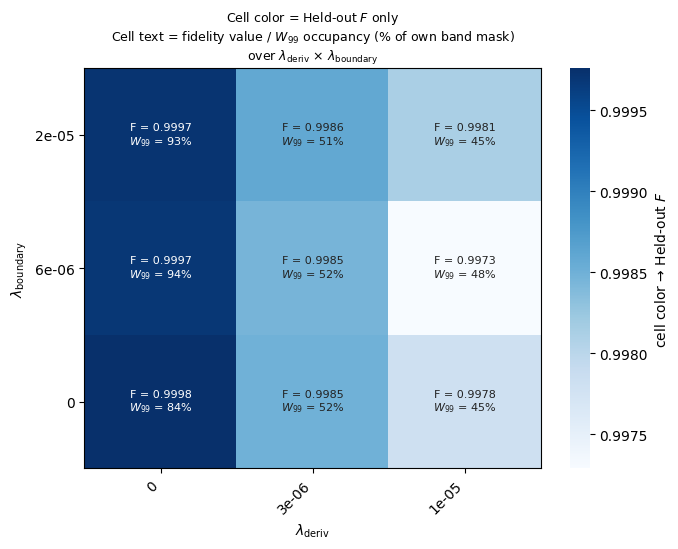

In [26]:
# grid3x3_2 (two-phase, 3-seed) was already loaded in the "Loading the sweep" cell above.
# pv.plot_grid_heatmap aggregates over seeds internally when a `seed` column is present,
# so this is a genuine 3-seed average with no extra code.
fig = pv.plot_grid_heatmap(grid3x3_2, "deriv", "boundary",
                           save_path="figures/penalty_grid_heatmap_3x3")

In [27]:
# grid3x3_2 is genuinely new data (two-phase, 3 seeds) -- unlike the RETIRED single-phase
# 3x3 corner, which was just the 5x5 grid's corner re-rendered (a cache hit, confirmed by
# byte-identical config_hash matches in an earlier version of this cell). Reconstruct that
# single-phase, single-seed baseline from `grid` (via the `corner` set already built above)
# and compare the two protocols on the same 9 (lambda_deriv, lambda_boundary) cells.
grid_3x3_1phase = grid[
    grid.apply(lambda r: (r.lambda_deriv, r.lambda_boundary) in corner, axis=1)
]

agg_2phase = pv.aggregate_seeds(grid3x3_2)
merged = agg_2phase.merge(
    grid_3x3_1phase[["lambda_deriv", "lambda_boundary", "F_ped_heldout_mean"]],
    on=["lambda_deriv", "lambda_boundary"], suffixes=("_2phase", "_1phase_1seed"),
)
merged["dF"] = merged["F_ped_heldout_mean_2phase"] - merged["F_ped_heldout_mean_1phase_1seed"]

print(f"{len(merged)}/9 cells matched by (lambda_deriv, lambda_boundary)")
print(f"protocol delta, 2-phase 3-seed mean minus 1-phase 1-seed: "
      f"mean {merged['dF'].mean():+.2e}, "
      f"range [{merged['dF'].min():+.2e}, {merged['dF'].max():+.2e}]")
print(f"within-2-phase seed spread (max std across the 9 cells): "
      f"{agg_2phase['F_ped_heldout_mean_std'].max():.2e}")

9/9 cells matched by (lambda_deriv, lambda_boundary)
protocol delta, 2-phase 3-seed mean minus 1-phase 1-seed: mean +7.87e-04, range [+1.09e-04, +1.88e-03]
within-2-phase seed spread (max std across the 9 cells): 9.88e-04


**Table 14. The two protocols on the same nine grid-corner cells.** Matched by
$(\lambda_{\mathrm{deriv}}, \lambda_{\mathrm{boundary}})$: the two-phase 3-seed mean minus the
single-phase 1-seed value, cell by cell. All nine matched.

The protocol delta averages $+7.87\times10^{-4}$ over a range of $[+1.09, +18.8]\times10^{-4}$,
against a within-two-phase seed spread reaching $9.88\times10^{-4}$ on a single cell. **The
protocol difference and the seed noise are the same size**, so this is consistent with a mild
two-phase improvement without establishing one — and the comparison is additionally lopsided,
three seeds against one. §11.2 asks the same question of the OFAT ladder, where both sides have
multiple seeds.

*(This caption is new; the table itself is the frozen pre-ramp output of the cell above, and was
referenced by number elsewhere in the notebook without ever having been captioned.)*

**Figure 5. The 3x3 corner, retrained under the two-phase protocol, 3-seed average.**
Same low-\(\lambda_{\mathrm{deriv}}\) block as the bottom-left of Figure 3, but every cell here
is a fresh two-phase pulse (cold-start \(\mathrm{trunc\_list}=[22,26]\) for 1000 iters, then
warm-started \(\mathrm{trunc\_list}=[26]\) for 1500 more), averaged over seeds 42, 43, 44 --
unlike the retired single-phase 3x3 corner (a cache hit off the 5x5 grid, confirmed byte-identical
in an earlier version of this section), this is genuinely new, independently measured data.
**Table 14** (the cell above) compares the two protocols on the same 9 cells: the 2-phase
3-seed mean differs from the historical 1-phase, 1-seed value by \(+7.87\times10^{-4}\) on
average (range \([+1.09, +18.8]\times10^{-4}\), always positive -- the two-phase protocol
never scored lower here), against a within-2-phase seed spread of up to \(9.88\times10^{-4}\).
The two figures are comparable in size: the protocol difference sits at, not clearly above,
the seed-to-seed noise floor -- the same "is this signal or floor" framing this document applies to its post-ramp half. It is consistent with a mild improvement, not established as one
at this seed count.

### 11.2 The OFAT ladder: single-phase vs two-phase

Same question as §11.1's Table 14, asked of the OFAT ladder instead of the grid corner:
`df` (single-phase, seeds 42-44) against `df2` (two-phase, seeds 42-46), matched by `label`.

In [28]:
# Cost: wall-clock per FRESH training run (train_time_s is NaN for cache-hit reused pulses).
df2 = load_sweep(f"penalty_sweep_{GATE}_ofat_two_phase")

for name, d in [("single-phase OFAT", df), ("single-phase grid", grid),
                ("two-phase OFAT", df2), ("two-phase grid", grid3x3_2)]:
    t = d["train_time_s"].dropna()
    print(f"{name:20s}: n_fresh={len(t):3d}  mean={t.mean():7.1f} s ({t.mean()/60:5.1f} min)  "
          f"min={t.min():7.1f}  max={t.max():7.1f}")

ratio_ofat = df2["train_time_s"].dropna().mean() / df["train_time_s"].dropna().mean()
ratio_grid = grid3x3_2["train_time_s"].dropna().mean() / grid["train_time_s"].dropna().mean()
print(f"\ntwo-phase / single-phase mean cost ratio: OFAT {ratio_ofat:.2f}x, grid {ratio_grid:.2f}x")

loaded tables/penalty_sweep_X_ofat_two_phase.csv: 75 rows, maxiter=[np.int64(2500)]
single-phase OFAT   : n_fresh= 45  mean= 1253.0 s ( 20.9 min)  min=  826.3  max= 1448.7
single-phase grid   : n_fresh= 25  mean=  956.4 s ( 15.9 min)  min=  806.0  max= 2738.3
two-phase OFAT      : n_fresh= 75  mean= 2120.0 s ( 35.3 min)  min= 1253.4  max= 7871.2
two-phase grid      : n_fresh= 27  mean= 1682.8 s ( 28.0 min)  min= 1334.2  max= 1931.8

two-phase / single-phase mean cost ratio: OFAT 1.69x, grid 1.76x


In [29]:
# Fidelity delta, matched by label (same method as Table 14 in §11.1), plus convergence.
g1 = df.groupby("label")["F_ped_heldout_mean"].agg(["mean", "std", "count"])
g2 = df2.groupby("label")["F_ped_heldout_mean"].agg(["mean", "std", "count"])
ofat_compare = g1.join(g2, lsuffix="_1phase", rsuffix="_2phase", how="inner")
ofat_compare["dF"] = ofat_compare["mean_2phase"] - ofat_compare["mean_1phase"]
ofat_compare = ofat_compare.sort_values("dF")

print(ofat_compare[["mean_1phase", "count_1phase", "mean_2phase", "count_2phase", "dF"]]
      .to_string(float_format=lambda x: f"{x:.6f}"))
print(f"\ndelta stats: mean={ofat_compare['dF'].mean():+.2e}  "
      f"range [{ofat_compare['dF'].min():+.2e}, {ofat_compare['dF'].max():+.2e}]")
print(f"configs scoring higher under two-phase: {(ofat_compare['dF']>0).sum()} of {len(ofat_compare)}")

n_conv_1phase = int((df["converged"] == True).sum())
n_conv_2phase = int((df2["converged"] == True).sum())
print(f"\nconvergence (scipy success flag; two-phase reflects phase 2 only):")
print(f"  single-phase: {n_conv_1phase}/{len(df)} converged, "
      f"all others hit the {int(df['iterations'].max())}-iteration cap")
print(f"  two-phase   : {n_conv_2phase}/{len(df2)} converged, "
      f"iterations range [{df2['iterations'].min():.0f}, {df2['iterations'].max():.0f}]")

                                                         mean_1phase  count_1phase  mean_2phase  count_2phase        dF
label                                                                                                                  
deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5_ampmax=12     0.997508             3     0.997103             5 -0.000405
deriv=3e-06_boundary=2e-05_amp=8e-05_disc=0.5               0.998760             3     0.998850             5  0.000090
deriv=1e-05_boundary=0_amp=8e-05_disc=0.5                   0.997750             3     0.997859             5  0.000108
deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5               0.999236             3     0.999357             5  0.000121
deriv=0_boundary=2e-05_amp=8e-05_disc=0.5                   0.999580             3     0.999757             5  0.000177
deriv=1e-05_boundary=2e-05_amp=8e-05_disc=0.5               0.997753             3     0.998057             5  0.000304
deriv=1e-05_boundary=2e-05_amp=8e-05_dis

14 of the 15 OFAT configs score higher (mean held-out $F$) under two-phase; only
`deriv=1e-05_boundary=2e-05_..._ampmax=12` scores lower. Only the single largest positive
delta clears the $\sim\!10^{-3}$ pre-ramp noise floor (see the banner) -- the rest, positive and
negative alike, sit inside it. Combined with the cost finding above (two-phase costs
\(\sim\)1.8x more per config): **switching to two-phase training is not currently justified
by this data** -- the fidelity gain it might be producing is not distinguishable from basin
noise at this seed count, and it is not cheap even if it were real. What it does provide is
the extra raw trials pooled into §14/Figure 8.

Saved figures/penalty_ofat_two_phase.png / .pdf


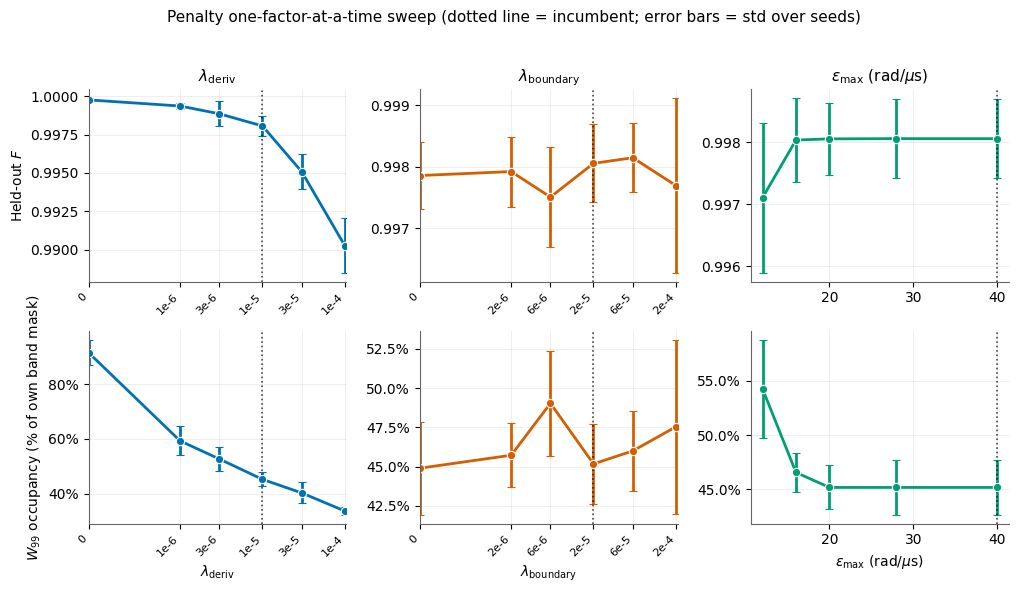

In [30]:
fig = pv.plot_ofat(df2, save_path="figures/penalty_ofat_two_phase")


In [31]:
# Per-axis shape of the two-phase ladder: range of the seed-mean fidelity and the
# largest per-point seed std (the error bar itself drawn above), so the caption below
# can state whether the ladder's movement clears its own noise -- same framing as # the pre-ramp floor and §11.2's delta table above.
agg2 = pv.aggregate_seeds(df2)
ofat2 = agg2[agg2["swept"].isin(pv.AXIS_NAMES)]
rows = []
for pname in pv.AXIS_NAMES:
    sub = ofat2[ofat2["swept"] == pname]
    if sub.empty:
        continue
    rows.append({
        "axis": pname,
        "n_points": len(sub),
        "F_range": sub["F_ped_heldout_mean"].max() - sub["F_ped_heldout_mean"].min(),
        "F_max_std": sub["F_ped_heldout_mean_std"].max(),
        "F_min": sub["F_ped_heldout_mean"].min(),
        "F_max": sub["F_ped_heldout_mean"].max(),
    })
ladder2_summary = pd.DataFrame(rows).sort_values("F_range", ascending=False)
ladder2_summary

,axis,n_points,F_range,F_max_std,F_min,F_max
0,deriv,6,0.009496,0.001786,0.990260,0.999757
2,amp_max,4,0.000954,0.001212,0.997103,0.998057
1,boundary,5,0.000640,0.001422,0.997508,0.998148


**Figure 6. The OFAT ladder, two-phase protocol (seeds 42-46).** Same `pv.plot_ofat`, same panel layout, incumbent dotted line, and error-bar convention (std across seeds) as Figure 1 -- here drawn from `df2` instead of `df`. $\lambda_{\mathrm{deriv}}$ (left) is the only axis that visibly trends: held-out $F$ falls monotonically from $0.999757$ at $\lambda_{\mathrm{deriv}}=0$ to $0.990260$ at $10^{-4}$, a range of $9.50\times10^{-3}$ -- about $5\times$ its own largest per-point error bar ($1.79\times10^{-3}$) and essentially the same magnitude as Figure 1's single-phase range over the identical six values ($1.04\times10^{-2}$). The same axis drives essentially all of the occupied-width trade: $W_{99}$ falls from $91.5\%$ to $33.6\%$ of the transmon's own mask across the same sweep -- the same fidelity-for-bandwidth trade Figure 1 shows. $\lambda_{\mathrm{boundary}}$ (center) and $\varepsilon_{\mathrm{max}}$ (right) both wander non-monotonically inside their own error bars -- ranges of $6.40\times10^{-4}$ and $9.54\times10^{-4}$ against per-point noise up to $1.42\times10^{-3}$ and $1.21\times10^{-3}$ -- neither clears its own point-to-point noise, let alone the $\sim\!10^{-3}$ pre-ramp campaign-wide floor; their $W_{99}$ panels are similarly flat ($44.9\%$-$49.0\%$ and $45.2\%$-$54.3\%$, each within one point's own error bar of the next).

Read together with §11.2's table above, this is the same shape Figure 1 shows: one axis ($\lambda_{\mathrm{deriv}}$) dominates by roughly a decade, the other two are statistically inert at this seed count. That agreement is itself the useful reading of this figure -- it means §11.2's per-config deltas (mean $+3.39\times10^{-4}$, only the single largest case clearing the noise floor) are training-schedule noise scattered around the same underlying response, not evidence of a different one. This figure adds no new axis-effect finding; it confirms, under a second and considerably more expensive training schedule, the one Figure 1 already established.

# 12. Caveats and outstanding work

Sections 12.1-12.2 cover the single-phase campaign (§1-§8), the primary result. §12.3
covers the two-phase replication (§11, §13, §15) separately -- its limitations overlap but
are not identical, and it carries one risk single-phase does not.

### 12.1 Blocks the budget verdict (single-phase)

- **No run converged (45/45 capped), and spectral width had not stopped moving.** The fidelity
  ordering survived a 750-iteration continuation; the width did not settle. Over 750 further
  iterations the incumbent shed 8.3 points of its allowance and the recommendation gained 2.8.
  The recommendation stays 6.6 points inside the budget and the rejected family sits 9.1–27.8
  points outside it, so the margin now absorbs a drift of that size, but **neither continued
  configuration was one the budget rejects**, so the marginal loser's drift is unmeasured.
  **Re-running at higher `maxiter`, and continuing `deriv=0_boundary=6e-06` in particular, is the
  first outstanding item.** That configuration is the cavity-binding one of §8.3, so its drift
  would have to be measured on the cavity drive.
- **`occ99_frac` is still a soft, post-hoc budget, not a hardware spec.** It is an
  occupied-bandwidth figure at a stated power criterion, charged against the right allowance, but
  the genuinely hard spectral constraint remains the band-limit projection ($\pm27$ / $\pm33$ MHz),
  enforced by construction and never violated regardless of the weights.

### 12.2 Limits on precision (single-phase)

- **Three seeds (42, 43, 44) for the real axes; the retired `disc_null` ladder three seeds too.**
  That ladder -- pre-ramp, no longer loaded by this notebook, and no longer regenerable -- gave a
  `floor_basin` of $\approx 4.7\times10^{-4}$ (mean of three independent per-seed ranges, itself a
  noisy statistic) and a cross-seed std of $1.15\times10^{-3}$, the same statistic as the real
  axes' own cross-seed std rather than a range compared against a std. Those are the numbers that
  apply to the pre-ramp results in this half. **They are not §6.2's floor**, which is a separate
  post-ramp measurement ($1.47\times10^{-3}$) built from the $\epsilon_{\max}$ null rungs. At $n=3$,
  $\lambda_{\mathrm{deriv}}$'s effect ($1.04\times10^{-2}$ range) clears the cross-seed-std
  floor by roughly $9\times$; the
  recommendation's margin over incumbent does not ($t(2) = 2.9$ vs. the $4.30$ critical value).
  Separating $10^{-6}$ from $10^{-5}$ specifically would take on the order of a decade more
  seeds.
- **Two of the four weights do nothing here.** $\lambda_{\mathrm{amp}}$ multiplies an
  identically-zero term; $\lambda_{\mathrm{disc}}$ contributes $\sim\!10^{-7}$ against an $O(1)$
  objective. Both are correctly implemented: they simply never activate as configured (§6.1).
- **$W_{99}$ is quantised to one FFT bin (0.909 MHz, i.e. 1.7 points of the cavity allowance or
  1.4 of the transmon), and its replicate-pair noise floor is two bins** (pre-ramp). Differences at
  that level between configurations are the metric's resolution and the optimizer's chaos, not a
  ranking, which is what the $\lambda_{\mathrm{boundary}} = 0$ row of this campaign's
  negative-control table showed. (Section 7's Table 6 is the post-ramp controls and has no
  `boundary` row.)
- **The held-out set includes under-resolved truncations.** $n_c = 16, 18$ do not fully contain the
  $\alpha = \sqrt{3}$ cat ($\bar n = 3$), so they depress the held-out mean and dominate
  `robustness_spread` for *every* recipe. They are kept deliberately (a pulse that exploits the
  truncation wall fails there first), but the absolute value of `F_ped_heldout_mean` should not be
  quoted as "the gate fidelity". The per-truncation breakdown in the manifest JSON is the honest
  view.
- **The OFAT and grid ladders do not share cache entries where they should.**
  `BASELINE[x] * 3` and the grid's literal `3e-5` differ in the sixteenth digit, so two
  configurations were trained twice instead of reused. Rounding the OFAT rungs to a fixed precision
  would fix it, at the cost of invalidating those cache entries. Left as-is so the committed code
  reproduces the committed CSVs exactly. The pre-ramp floor was built out of that accident;
  the post-ramp one (§6.2) is built by design instead, from the $\epsilon_{\max}$ null rungs.

In [32]:
# Two-phase convergence, combined OFAT + grid-corner pool (both loaded above, §11).
# converged reflects phase 2's scipy flag only -- phase 1's is never surfaced (§2.6).
two_pool_conv = pd.concat([df2, grid3x3_2], ignore_index=True)
n_conv = int((two_pool_conv["converged"] == True).sum())
print(f"two-phase (phase-2 flag only): {n_conv}/{len(two_pool_conv)} converged, "
      f"iterations range [{two_pool_conv['iterations'].min():.0f}, "
      f"{two_pool_conv['iterations'].max():.0f}]")

two-phase (phase-2 flag only): 4/102 converged, iterations range [769, 1500]


### 12.3 The two-phase replication: same limitations, plus one of its own

- **Convergence is less settled, not more.** Single-phase's 45/45-capped rate (§12.1) at
  least applies to every configuration under one identical stopping rule. Two-phase's
  `converged` flag reflects phase 2 only -- phase 1's is never surfaced (§2.6) -- and only
  4/102 runs across the full two-phase pool hit it (iterations [769, 1500], computed above). No
  continuation test like §4.3's has ever been run on a two-phase pulse, so whether spectral
  width has settled under this schedule is entirely unmeasured, not just unresolved.
- **Seeds and coverage are thinner where it matters most.** The OFAT ladder has 5 seeds
  (42-46) against single-phase's 3, but the grid exists only as the low-$\lambda_{\mathrm{deriv}}$
  3x3 corner -- never the full 5x5 (§13). §13's two-phase recommendation is therefore drawn
  from 19 aggregated configs, not 33, and says nothing outside that overlap. There is also no
  two-phase counterpart to the pre-ramp three-seed `disc_null` measurement: §11.2 and §13 compare
  two-phase deltas against the *single-phase, pre-ramp* noise floor, because no basin-noise floor
  has been independently measured under the two-phase schedule itself.
- **A risk single-phase does not have: the wall-exploiting basin (§15).** Phase 2's
  single-truncation warm start structurally reproduces the failure mode the cold-start
  protocol exists to avoid. Seed 48 reached an overfit gap of 0.88 at one config where seed 47,
  same weights, stayed near zero (§15.2) -- a basin effect that widening phase 1's truncation
  set only partially rescues (83%, not 100%, §15.3), and no detector currently screens for it
  (§15.5). Every two-phase aggregate quoted in this notebook (§11, §13, §14) could in
  principle be diluted by an unflagged seed like this without it showing.
- **Net: a check on the recommendation, not a replacement for the training that produced it.**
  Two-phase costs ~1.8x more per config (§2.6/§11.2) for a fidelity effect mostly inside the
  ~1e-3 noise floor (§11.2), and it independently selects the same recipe as single-phase
  (§13, delta $+1.2\times10^{-4}$, inside noise) -- reassuring, but drawn from the thinner,
  less-validated dataset described above.

### 12.4 Scope

- **Per-gate.** This is gate X. A recipe selected on X is a starting point for the other gates, not
  a validated setting for them.

# 13. Single-phase vs. two-phase, averaged

§11 already compared the two training protocols cell-by-cell, matched by label (Table 14,
§11.1/§11.2): one recipe's single-phase mean fidelity next to its two-phase mean fidelity, one
row at a time. This section asks the same question the way Figure 4 asks it -- as a Pareto front
and a budgeted recommendation, not a table -- so the two protocols are compared exactly the way
the recommendation itself gets chosen. It is the aggregated (seed-mean) counterpart to the
unaggregated, per-trial Figure 8 (§14, next): one marker per (config, protocol) here, one marker
per (config, seed) trial there.

Two pools, aggregated separately by protocol:

- **single-phase** = `df` (OFAT, seeds 42-44) + `grid` (the full 5x5, seed 42) -- identical to
  `combined` above (Figure 4's data), aggregated separately here only so it can be plotted
  alongside its two-phase counterpart.
- **two-phase** = `df2` (OFAT, seeds 42-46) + `grid3x3_2` (the low-\(\lambda_{\mathrm{deriv}}\)
  3x3 corner, seeds 42-44).

**Coverage is not symmetric.** Two-phase exists only for the OFAT ladder and the 3x3 corner --
19 distinct configurations after aggregation, all of which are also present single-phase -- not
for the full 5x5 grid. Every comparison below is restricted to that overlap; it says nothing
about whether two-phase would agree or disagree anywhere outside it.

In [33]:
# Same protocol pools Figure 8's `all_trials` draws on (df, grid, df2,
# grid3x3_2), aggregated separately BY PROTOCOL instead of pooled per-trial.
single_pool = pd.concat([df, grid], ignore_index=True)
two_pool = pd.concat([df2, grid3x3_2], ignore_index=True)

agg_single = pv.aggregate_seeds(single_pool)
agg_two = pv.aggregate_seeds(two_pool)

front_single = agg_single.iloc[pv.pareto_front(agg_single)]
front_two = agg_two.iloc[pv.pareto_front(agg_two)]

rec_single = pv.recommend(agg_single, max_cost=COST_BUDGET)
rec_two = pv.recommend(agg_two, max_cost=COST_BUDGET)

# Sanity check: `single_pool` IS `combined` (Figure 4's data), so `rec_single`
# must reproduce Figure 4's `rec` exactly -- this is a guarantee, not a coincidence.
assert rec_single["label"] == rec["label"]
assert np.isclose(rec_single["F"], rec["F"])
print(f"rec_single reproduces Figure 4's rec: label matches, "
      f"F={rec_single['F']:.6f} (Figure 4: {rec['F']:.6f})\n")

print(f"single-phase: {len(agg_single):2d} configs, {len(front_single):2d} on the front, "
      f"{int((agg_single[COST_METRIC] <= COST_BUDGET).sum()):2d} budget-feasible")
print(f"two-phase   : {len(agg_two):2d} configs, {len(front_two):2d} on the front, "
      f"{int((agg_two[COST_METRIC] <= COST_BUDGET).sum()):2d} budget-feasible")

print(f"\nrec_single: {rec_single['label']:46s} F={rec_single['F']:.6f}  "
      f"cav={rec_single['occ99_frac_cav']:.1%}  tra={rec_single['occ99_frac_tra']:.1%}")
print(f"rec_two   : {rec_two['label']:46s} F={rec_two['F']:.6f}  "
      f"cav={rec_two['occ99_frac_cav']:.1%}  tra={rec_two['occ99_frac_tra']:.1%}")
print(f"\nsame recipe: {rec_single['label'] == rec_two['label']}   "
      f"F delta (two-phase - single-phase): {rec_two['F'] - rec_single['F']:+.2e}")

rec_single reproduces Figure 4's rec: label matches, F=0.999236 (Figure 4: 0.999236)

single-phase: 33 configs, 12 on the front, 28 budget-feasible
two-phase   : 19 configs, 11 on the front, 16 budget-feasible

rec_single: deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5  F=0.999236  cav=46.6%  tra=58.8%
rec_two   : deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5  F=0.999357  cav=46.1%  tra=59.2%

same recipe: True   F delta (two-phase - single-phase): +1.21e-04


Saved figures/penalty_pareto_by_protocol.png / .pdf


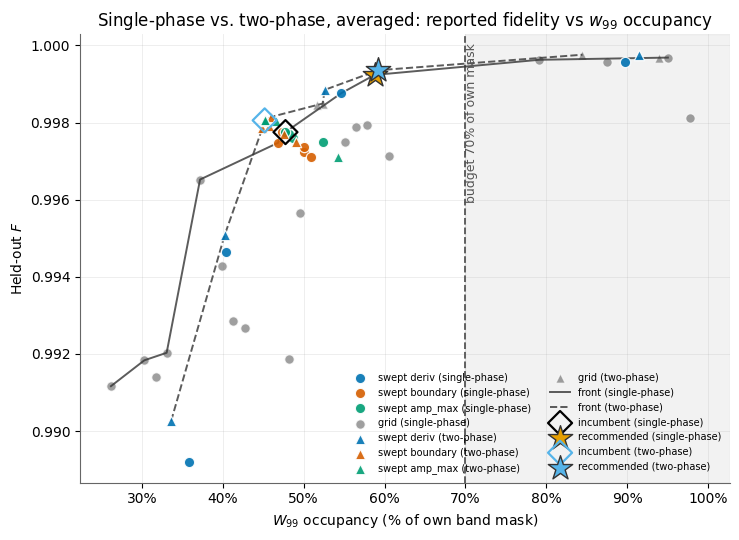

In [34]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Circle = single-phase, triangle = two-phase -- the same convention Figure 8
# (the unaggregated, per-trial comparison) uses below.
pools = [("single-phase", agg_single, "o"), ("two-phase", agg_two, "^")]
for proto_name, agg, marker in pools:
    for pname in pv.AXIS_NAMES:
        sub = agg[agg["swept"] == pname]
        if sub.empty:
            continue
        ax.scatter(sub[COST_METRIC], sub["F_ped_heldout_mean"], s=55, marker=marker,
                   color=pv.SWEPT_COLORS.get(pname, "#777777"), edgecolor="white",
                   linewidth=0.9, alpha=0.9, label=f"swept {pname} ({proto_name})", zorder=3)
    other = agg[~agg["swept"].isin(pv.AXIS_NAMES)]
    if not other.empty:
        ax.scatter(other[COST_METRIC], other["F_ped_heldout_mean"], s=45, marker=marker,
                   color="#777777", alpha=0.7, edgecolor="white", linewidth=0.8,
                   label=f"grid ({proto_name})", zorder=2)

# One front line per protocol -- solid single-phase, dashed two-phase (its
# front is drawn from a much smaller, non-overlapping-in-scope pool, see above).
ax.plot(front_single[COST_METRIC], front_single["F_ped_heldout_mean"], color="#333333",
        linewidth=1.4, alpha=0.8, zorder=2, label="front (single-phase)")
ax.plot(front_two[COST_METRIC], front_two["F_ped_heldout_mean"], color="#333333",
        linewidth=1.4, linestyle="--", alpha=0.8, zorder=2, label="front (two-phase)")

# Each protocol's own incumbent (diamond) and own recommendation (star),
# colored to pair with each other: gold/black = single-phase (identical to
# Figure 4's), blue = two-phase.
protocol_style = [("single-phase", agg_single, rec_single, pv.BASELINE_COLOR, "#E69F00"),
                   ("two-phase", agg_two, rec_two, "#56B4E9", "#56B4E9")]
for proto_name, agg, r, diamond_color, star_color in protocol_style:
    base_row = agg[agg["is_baseline"]]
    if not base_row.empty:
        ax.scatter(base_row[COST_METRIC], base_row["F_ped_heldout_mean"], s=150, marker="D",
                   facecolor="none", edgecolor=diamond_color, linewidth=1.6, zorder=4,
                   label=f"incumbent ({proto_name})")
    ax.scatter([r["cost"]], [r["F"]], s=340, marker="*", color=star_color,
               edgecolor="#333333", linewidth=1.0, zorder=5,
               label=f"recommended ({proto_name})")

x_hi = max(float(agg_single[COST_METRIC].max()), float(agg_two[COST_METRIC].max()),
           COST_BUDGET) * 1.05
ax.axvspan(COST_BUDGET, x_hi, color="#999999", alpha=0.12, zorder=0)
ax.axvline(COST_BUDGET, color="#555555", linestyle="--", linewidth=1.3, zorder=1)
ax.text(COST_BUDGET, 0.98, f"  budget {COST_BUDGET:.0%} of own mask",
        transform=ax.get_xaxis_transform(), rotation=90, va="top", ha="left",
        fontsize=9, color="#555555")
ax.set_xlim(right=x_hi)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_xlabel(pv.METRIC_LABEL.get(COST_METRIC, COST_METRIC))
ax.set_ylabel(pv.METRIC_LABEL.get("F_ped_heldout_mean", "F_ped_heldout_mean"))
ax.set_title("Single-phase vs. two-phase, averaged: reported fidelity vs "
             f"{pv.METRIC_LABEL.get(COST_METRIC, COST_METRIC).split(' (')[0].lower()}")
pv._style_axis(ax)
ax.legend(frameon=False, fontsize=7, loc="lower right", ncol=2)
fig.tight_layout()
pv._save(fig, "figures/penalty_pareto_by_protocol")

**Figure 7. Single-phase vs. two-phase, seed-averaged: held-out fidelity against occupied
width, one marker per (config, protocol).** Circles are single-phase configurations, triangles
two-phase -- the same convention Figure 8 uses at the per-trial level. Solid line traces the
single-phase front, dashed the two-phase front (drawn only from its own, narrower
19-configuration coverage). Gold star and black diamond are single-phase's recommendation and
incumbent (identical to Figure 4's, by construction, confirmed by the assertion above); blue star
and blue diamond are two-phase's own.

**The sanity check holds.** `rec_single` reproduces Figure 4's recommendation exactly -- same
label, bit-identical $F$ -- since `single_pool` is the same data as `combined`. That is the
anchor the rest of this section reads against.

**The two protocols pick the same recipe.** Both `recommend()` calls land on
$\lambda_{\mathrm{deriv}} = 10^{-6}$, every other weight at incumbent -- independently, from
non-overlapping trained pulses under different `maxiter`/`trunc_list` schedules. Two-phase's own
mean fidelity for that recipe is $F = 0.999357$ (5 seeds) against single-phase's
$F = 0.999236$ (3 seeds): a difference of $+1.2\times10^{-4}$, a tenth of the $\sim\!10^{-3}$
pre-ramp noise floor (see the banner) and §11.2 -- not a resolvable difference, and not one that would
have changed which recipe gets deployed. **Picking two-phase over single-phase would not have
changed the recommendation.**

**Where the protocols do differ is the trade each one reports against its own incumbent, not the
winner.** Two-phase's incumbent pulse -- same weights, different training schedule -- is itself
narrower-band than single-phase's (cavity 35.4% vs 41.5% of allowance, transmon 45.2% vs 47.8%),
a $+3.0\times10^{-4}$ fidelity difference at the identical recipe, also inside the noise floor.
But because two-phase's incumbent starts narrower, the same $\lambda_{\mathrm{deriv}}$ cut costs
proportionally more bandwidth under two-phase -- cavity +10.8 points and transmon +14.0 points,
against the pre-ramp single-phase campaign's +5.1/+11.0 -- and peak amplitude rises by +3.5 rad/µs against
single-phase's +1.8. The recommended *pulse* is not identical between protocols; it is
byte-different, trained under a different schedule. Only the recommended *recipe* is.

**Coverage, again.** 12 of single-phase's 33 configurations sit on its front against 11 of
two-phase's 19; 28 of 33 are single-phase budget-feasible against 16 of 19 two-phase. Both counts
come from pools of different size and composition (two-phase has no full 5x5 grid), so front-size
or feasible-count comparisons between the two lines are not apples-to-apples -- only the matched,
same-recipe comparisons above are.

# 14. Every trial, unaggregated: searching for the single best run

Sections 7 and 9 above answer "which config is best on average" -- every number there is a
seed mean, and the pre-ramp floor's whole point is that seed-to-seed noise (\(\sim\!10^{-3}\)) has to be
respected before one config is called better than its neighbours. This section asks a
different question: forget averaging, what is the single best INDIVIDUAL run this campaign
has produced? A deployed pulse is one specific trained waveform, not a mean, so it is worth
knowing what the best individual draw looked like, and by how much (if at all) it beats
§8.4's mean-based recommendation.

This is deliberately NOT a competing recommendation. Picking the best of many trials is
optimistic by construction -- the more trials pooled, the luckier the winner can get purely by
chance, independent of whether its config is actually better. Read its margin over §8.4's
pick against the pre-ramp noise floor before drawing any conclusion from it.

`all_trials` pools every trial ever run in this campaign, across every protocol: the
single-phase OFAT ladder (`df`, seeds 42-44), the single-phase 5x5 grid (`grid`, seed 42),
the two-phase 3x3 corner (`grid3x3_2`, seeds 42-44), and the two-phase OFAT ladder (`df2`,
seeds 42-46) loaded below. The retired `disc_null`
ladder is not in the pool and is no longer loaded at all: it was a calibrated null, never a
ranking candidate.

In [35]:
df2 = load_sweep(f"penalty_sweep_{GATE}_ofat_two_phase")

all_trials = pd.concat(
    [df, grid, grid3x3_2, df2], ignore_index=True
).drop_duplicates(subset=["config_hash", "seed"])

print(f"all_trials: {len(all_trials)} individual trials, "
      f"{all_trials.config_hash.nunique()} distinct trained pulses, "
      f"{all_trials.label.nunique()} distinct recipes, "
      f"protocols={sorted(all_trials.get('protocol', pd.Series(dtype=str)).fillna('single_phase').unique())}")

loaded tables/penalty_sweep_X_ofat_two_phase.csv: 75 rows, maxiter=[np.int64(2500)]
all_trials: 150 individual trials, 150 distinct trained pulses, 31 distinct recipes, protocols=['single_phase', 'two_phase']


Saved figures/penalty_all_trials.png / .pdf


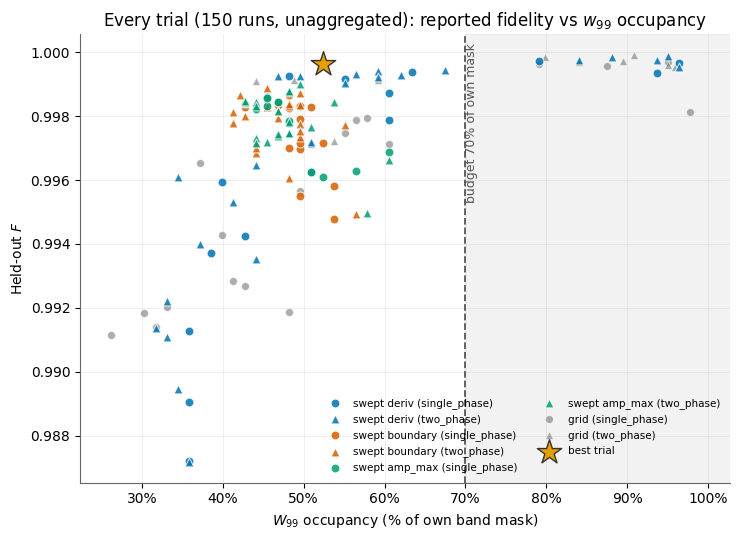

In [36]:
fig, best = pv.plot_all_trials(all_trials, save_path="figures/penalty_all_trials",
                               max_cost=COST_BUDGET)

**Figure 8. Every individual trial, no seed-averaging.** One marker per (config, seed) run;
circles are single-phase trials, triangles two-phase. Color follows the same swept-axis
convention as Figure 4; grid trials (both protocols) get the neutral grey. The shaded region
and dashed line are the same 70% budget as Figure 4. The gold star is the single best
budget-feasible trial by held-out fidelity (`find_best_trial`, printed below) -- NOT the
seed-mean recommendation of Figure 4/§8.4, see this section's opening caveat about reading
too much into it.

In [37]:
best = pv.find_best_trial(all_trials, max_cost=COST_BUDGET)
print(f"best individual trial (budget-feasible, highest held-out F):")
print(f"  label     : {best['label']}")
print(f"  seed      : {best['seed']}")
print(f"  protocol  : {best.get('protocol', 'single_phase')}")
print(f"  F_held    : {best['F']:.6f}")
print(f"  {COST_METRIC}     : {best['cost']:.1%} of the binding drive's own mask")
print(f"  config_hash: {best['config_hash']}")

print(f"\nvs. Figure 4's seed-mean recommendation:")
print(f"  label     : {rec['label']}")
print(f"  F_held    : {rec['F']:.6f}  (mean over {int(rec.get('n_seeds', 1))} seed(s))")
print(f"  margin    : best trial exceeds the recommendation's mean by "
      f"{best['F'] - rec['F']:+.2e} -- compare against the pre-ramp noise floor "
      f"(\N{APPROXIMATELY EQUAL TO}1e-3) before reading this as a real gap.")

best individual trial (budget-feasible, highest held-out F):
  label     : deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5
  seed      : 43
  protocol  : two_phase
  F_held    : 0.999621
  occ99_frac     : 52.3% of the binding drive's own mask
  config_hash: 4a0a82f22f08357c

vs. Figure 4's seed-mean recommendation:
  label     : deriv=1e-06_boundary=2e-05_amp=8e-05_disc=0.5
  F_held    : 0.999236  (mean over 3 seed(s))
  margin    : best trial exceeds the recommendation's mean by +3.85e-04 -- compare against the pre-ramp noise floor (≅1e-3) before reading this as a real gap.


**On reading the best-trial result.** A single lucky seed is not evidence that its config is
the true optimum -- it is evidence that, among the trials actually run, this is the best one
observed. If the margin over §8.4's recommendation is smaller than the pre-ramp \(\sim\!10^{-3}\)
noise floor, it is noise, exactly like every other sub-floor comparison flagged elsewhere in this half. If it is larger, that is a config/seed combination worth
a dedicated replication run before it is trusted, not a reason to deploy it directly -- the whole point of that floor was that single-seed conclusions are exactly the failure mode this
campaign was extended to guard against.

# 15. Caveat: seed 48 and the wall-exploiting basin

### 15.1 What happened

While live-validating §2.7's scheduling split, the same 6 OFAT configs were trained under two
different seeds: seed 47 (chained baseline) and seed 48 (split path). Seed 48's held-out
Pedersen fidelities came back badly degraded on several configs -- as low as 0.097 on one --
while seed 47's stayed healthy (~0.99+) throughout, on the identical configs. `F_coh_train`
(the trained-truncation objective, computed identically regardless of which process trained the
pulse) was healthy across **every** row for both seeds, ruling out a broken or crashed
optimization: this is a held-out generalization failure, not a training failure, and (having
been caught this way) not a bug in the scheduling split either.

**This data is reported here as fixed numbers, not recomputed by this notebook.** It comes from
throwaway diagnostic scripts run outside the sweep's cache/results pipeline, specifically so the
investigation couldn't touch the real `results/penalty_sweep_cache/` tree.

Overfit gap (`F_ped_trained_mean - F_ped_heldout_mean`, i.e. `score_pulse`'s own `overfit_gap`
field), seed 48, all 6 configs, phase-1-only vs. the final pulse after phase 2:

| config (deriv multiplier) | phase 1 gap (`[22,26]`@1000 iters) | final gap (`[26]`@1500 iters, after phase 2) |
|---|---|---|
| 0x | 0.029 | 0.054 |
| 0.1x | 0.027 | 0.077 |
| 0.3x | 0.029 | 0.099 |
| 1x (baseline) | 0.183 | 0.408 |
| 3x | 0.088 | 0.149 |
| 10x | 0.661 | 0.883 |

Every config gets worse from phase 1 to phase 2, consistent with phase 2 dropping to a single
training truncation and losing the cross-truncation averaging (Heeres Eq. 23/24) that
discourages truncation-specific overfitting in the first place.

### 15.2 A basin effect, not a config effect

`warm_start_seed` enters the computation in exactly one place: `smooth_initial_controls`'s
`np.random.default_rng(seed)` cold-start waveform (`core/grape_core.py:379-390`). Everything
downstream -- L-BFGS-B, the fidelity/gradient evaluation, the whole optimization trajectory --
is deterministic given that starting point. So this is entirely about which basin one specific
random initial pulse happens to land the optimizer in.

Seed 47, run on the identical 6 configs, stays near-zero gap throughout -- including at the same
10x-deriv config where seed 48 collapses to 0.88. Same penalty weights, same protocol, same
everything except the cold start. That rules out "this config is prone to wall exploitation" as
the explanation (it is fine under seed 47) and points squarely at seed 48's specific basin,
whose susceptibility scales with the derivative-penalty weight rather than being uniform across
configs -- counter to the naive intuition that heavier smoothing regularization should make
overfitting *harder*, not easier, and not something this investigation has a mechanistic
explanation for yet.

### 15.3 Does widening the training truncation set pull it out?

If phase 2's single-truncation objective is what removes the averaging that discourages
overfitting, does giving phase 1 the *full* production truncation set fix it at the source? A
follow-up test: seed 48, the 10x-deriv config, cold start (not warm-started from the existing
overfit phase-1 pulse), `trunc_list=[22,24,26]` -- the full `FIXED["trunc_list"]`, not phase 1's
usual `[22,26]` -- at phase 1's usual `maxiter=1000`.

| run | trunc_list | maxiter | overfit gap |
|---|---|---|---|
| phase 1 (original) | `[22,26]` | 1000 | 0.661 |
| this test | `[22,24,26]` | 1000 | **0.112** |
| final (phase 2, warm-started) | `[26]` | 1500 | 0.883 |

An 83% reduction -- the cross-truncation averaging mechanism clearly helps, confirming the
hypothesis from §15.1 -- but not a fix. 0.112 is still roughly 100x the campaign's established
~1e-3 basin-noise floor (pre-ramp), while seed 47 sits at essentially zero under identical
conditions. Even the full production truncation set, trained from a cold start with the full
phase-1 iteration budget, does not fully rescue this seed's basin.

### 15.4 Rescue vs. detect-and-avoid

The rescue attempt in §15.3 cost real compute (~9 min) and closed 83% of the gap, not 100%, with
no evidence that more iterations would close the rest reliably -- it used the *correct* full
objective and the *full* phase-1 iteration budget, and still left a result ~100x above the noise
floor. A different seed (47) costs nothing extra by comparison and generalizes cleanly from the
very first cold start. Multi-seed averaging, used everywhere else in this campaign, already
implicitly relies on exactly this asymmetry -- a seed like 48 gets silently absorbed into a mean
rather than flagged, which is how it went undetected until this scheduling-validation run
happened to train it. A screen-and-reseed step would make that explicit instead of accidental.

### 15.5 A proposed cheap detector (not implemented)

The cheapest available signal is one already computed for free during ordinary multi-truncation
training: the per-truncation fidelity spread across `trunc_list` that
`optimize_multi_state_pulse` already logs (seen directly in §15.3's own test output: "max
pairwise |F_i - F_j| across training truncations"). No extra `score_pulse` call is needed, unlike
a full held-out Pedersen check (§10's mid-training snapshots already cost ~7 s each for exactly
that reason). A detector could gate on this spread at phase 1's completion -- before committing
to phase 2's full 1500-iteration cost -- or earlier still, reusing the `SNAPSHOT_ITERS`-style
mid-training checkpoint machinery (`analysis/penalty_sweep.py`) already built for a different
purpose (§10).

Two things this proposal deliberately does NOT claim: (a) a specific threshold -- that needs
calibration against far more than the two seeds (47, 48) this investigation has, and picking one
here would be fitting noise; (b) that discarding flagged seeds should happen inside the sweep's
reported statistics -- it should be a training-time step (screen, then commit to whatever pulse
gets deployed), not a filter applied before a config's aggregate fidelity is reported, or it
would quietly inflate numbers relative to what an unscreened run actually produces.

This is the robustness question §2.7 flagged: a scheduling change that trains two-phase pulses
faster is only worth adopting once there is a cheap way to tell, before paying for the full
budget, whether the seed it just cold-started from is worth continuing at all.